# Sumário

*   [Introdução](#introducao)
    *   [1.1 Cabeçalho](#cabecalho)
    *   [1.2 Glossário](#glossario)
    *   [1.3 Esclerose Múltipla & Identificação](#esclerose-multipla-e-identificacao)
*   [Desenvolvimento](#desenvolvimento)
    *   [Etapa 1 — Redução de ruído](#etapa-1-reducao-de-ruido)
        *   [2.1 Leitura e inspeção das imagens](#leitura-e-inspecao-das-imagens)
        *   [2.2 Modo rápido — opcional](#modo-rapido-opcional)
        *   [2.3 Visualização inicial das modalidades T1 e FLAIR](#visualiza%C3%A7%C3%A3o-inicial-das-modalidades-t1-e-flair)
        *   [2.4 Aplicação de Filtros Não-Lineares](#aplicacao-de-filtros-nao-lineares)
        *   [2.5 Filtro Bilateral](#filtro-bilateral)
        *   [2.6 Difusão Anisotrópica](#difusao-anisotropica)
        *   [2.7 Média Não-Local (NLM)](#media-nao-local-nlm)
        *   [2.8 Comparação final entre os filtros](#comparacao-final-entre-os-filtros)
        *   [2.9 Conclusão da Etapa 1](#conclusao-da-etapa-1)
    *   [Etapa 2 — Registro espacial e alinhamento dos atlas probabilísticos](#registro-espacial-e-alinhamento-dos-atlas-probabilisticos)
        *   [3.1 Leitura do atlas e dos mapas probabilísticos](#leitura-do-atlas-e-dos-mapas-probabilisticos)
        *   [3.2 Inspeção dos metadados espaciais](#inspecao-dos-metadados-espaciais)
        *   [3.3 Estratégias de registro avaliadas](#estrategias-de-registro-avaliados)
        *   [3.4 Criação da máscara cerebral do atlas](#criacao-da-mascara-cerebral-do-atlas)
        *   [3.5 Início do registro](#inicio-do-registro)
        *   [3.6 Execução dos registros globais](#registro-rigido)
        *   [3.7 Registro rígido + afim](#registro-rigido-afim)
        *   [3.8 Registro deformável BSpline](#registro-deformavel-bspline)
        *   [3.9 Registro deformável com Model Zoo grid 24](#registro-deformavel-com-model-zoo-grid-24)
        *   [Resumo das transformações avaliadas](#resumo-das-transformacoes-avaliadas)
        *   [3.10 Propagação dos mapas probabilísticos GM, WM e CSF](#propagacao-dos-mapas-probabilisticos-gm-wm-csf)
        *   [3.11 Conclusão da Etapa 2](#conclusao-da-etapa-2)
    *   [Etapa 3 — Segmentação de possíveis lesões na FLAIR](#segmentacao-de-possiveis-lesoes-na-flair)
        *   [4.1 Pós-processamento por componentes conectados](#pos-processamento-por-componentes-conectados)
        *   [4.2 Segmentação por K-Means](#lesoes-identificadas-via-k-medias)
        *   [Visualização teórica do K-Means](#visualizacao-teorica-do-k-means)
        *   [4.3 Análise do resultado do K-Means](#analise-do-resultado-da-segmentacao)
        *   [4.4 Segmentação por Gaussian Mixture Model](#lesoes-identificadas-via-gaussian-mixture-model)
        *   [Visualização teórica do GMM](#visualizacao-teorica-do-gmm)
        *   [4.5 Análise do resultado do GMM](#analise-do-resultado-do-gmm)
        *   [4.6 Comparação com as máscaras de referência](#comparacao-com-mascara-de-referencia)
        *   [4.7 Conclusão da Etapa 3](#conclusao-da-etapa-3)
*   [Aplicação do método final aos demais casos clínicos](#aplicacao-do-metodo-final-aos-demais-casos-clinicos)
    *   [5.1 Estratégia utilizada](#estrategia-utilizada)
    *   [5.2 Configuração utilizada](#configuracao-utilizada)
    *   [5.3 Resultados](#resultados)
    *   [5.4 Discussão](#discussao)
*   [Conclusão](#conclusao)
*   [Referências](#referencias-bibliograficas)



---



# Introdução <a name="introducao"></a>

## 1.1 Cabeçalho <a name="cabecalho"></a>

**Universidade Federal de São Carlos (UFSCar)** — Programa de Pós Graduação em Ciência da Computação (PPGCC) — Departamento de Computação (DC) — 2026.1

**`Processamento de Imagens Médicas 3D para Segmentação de Regiões de Esclerose Múltipla`**



---



Este notebook apresenta as seguintes etapas:

1. `Redução de ruído em imagens T1 e FLAIR;`
2. `Registro espacial do atlas probabilístico no espaço da imagem clínica;`
3. `Segmentação de possíveis lesões na substância branca.`


> Disciplina: Processamento Digital de Imagens 3D e Vídeos (PDIV3D)  
> Professor: Prof. Dr. Ricardo José Ferrari  
> Alunos G2: Ricardo Guimarães Herreira e Carlos Henrique Porto Carvalho




---



## 1.2 Glossário <a name="glossario"></a>


---



| Sigla/Termo | Descrição |
| :---------- | :----------------- |
| RM/MR          | Ressonância Magnética |
| WM          | Substância Branca |
| GM          | Substância Cinzenta |
| CSF         | Líquor (Líquido Cefalorraquidiano) |
| FLAIR       | Fluid-Attenuated Inversion Recovery (sequência de RM) |
| T1          | Imagem ponderada em T1 (sequência de RM) |
| EM/MS          | Esclerose Múltipla |
| G           | Imagem Diferença (resíduo entre imagem original e filtrada) |
| NLM         | Non-Local Means (filtro de redução de ruído) |
| GMM         | Gaussian Mixture Model (Modelo de Mistura Gaussiana) |
| K-Means     | Algoritmo de agrupamento (clustering) |
| GT          | Ground Truth (Máscara de Referência) |
| EM          | Expectation-Maximization (Algoritmo de otimização para GMM) |


## 1.3 Esclerose Múltipla & Identificação <a name="esclerose-multipla-e-identificacao"></a>


A Esclerose Múltipla (EM) é distúrbio autoimune em que o sistema imunológico (linfócitos) ataca(m) a bainha de mielina - presente na Substância Branca, a cobertura protetora das fibras nervosas. Isso leva à comunicação interrompida entre o cérebro e o resto do corpo, causando sintomas como fraqueza muscular, problemas de coordenação e fadiga. O tratamento se concentra em controlar os sintomas, desacelerar a progressão da doença e modificar a resposta imunológica, [ref 3, 6, 7, 11, 12, 13].

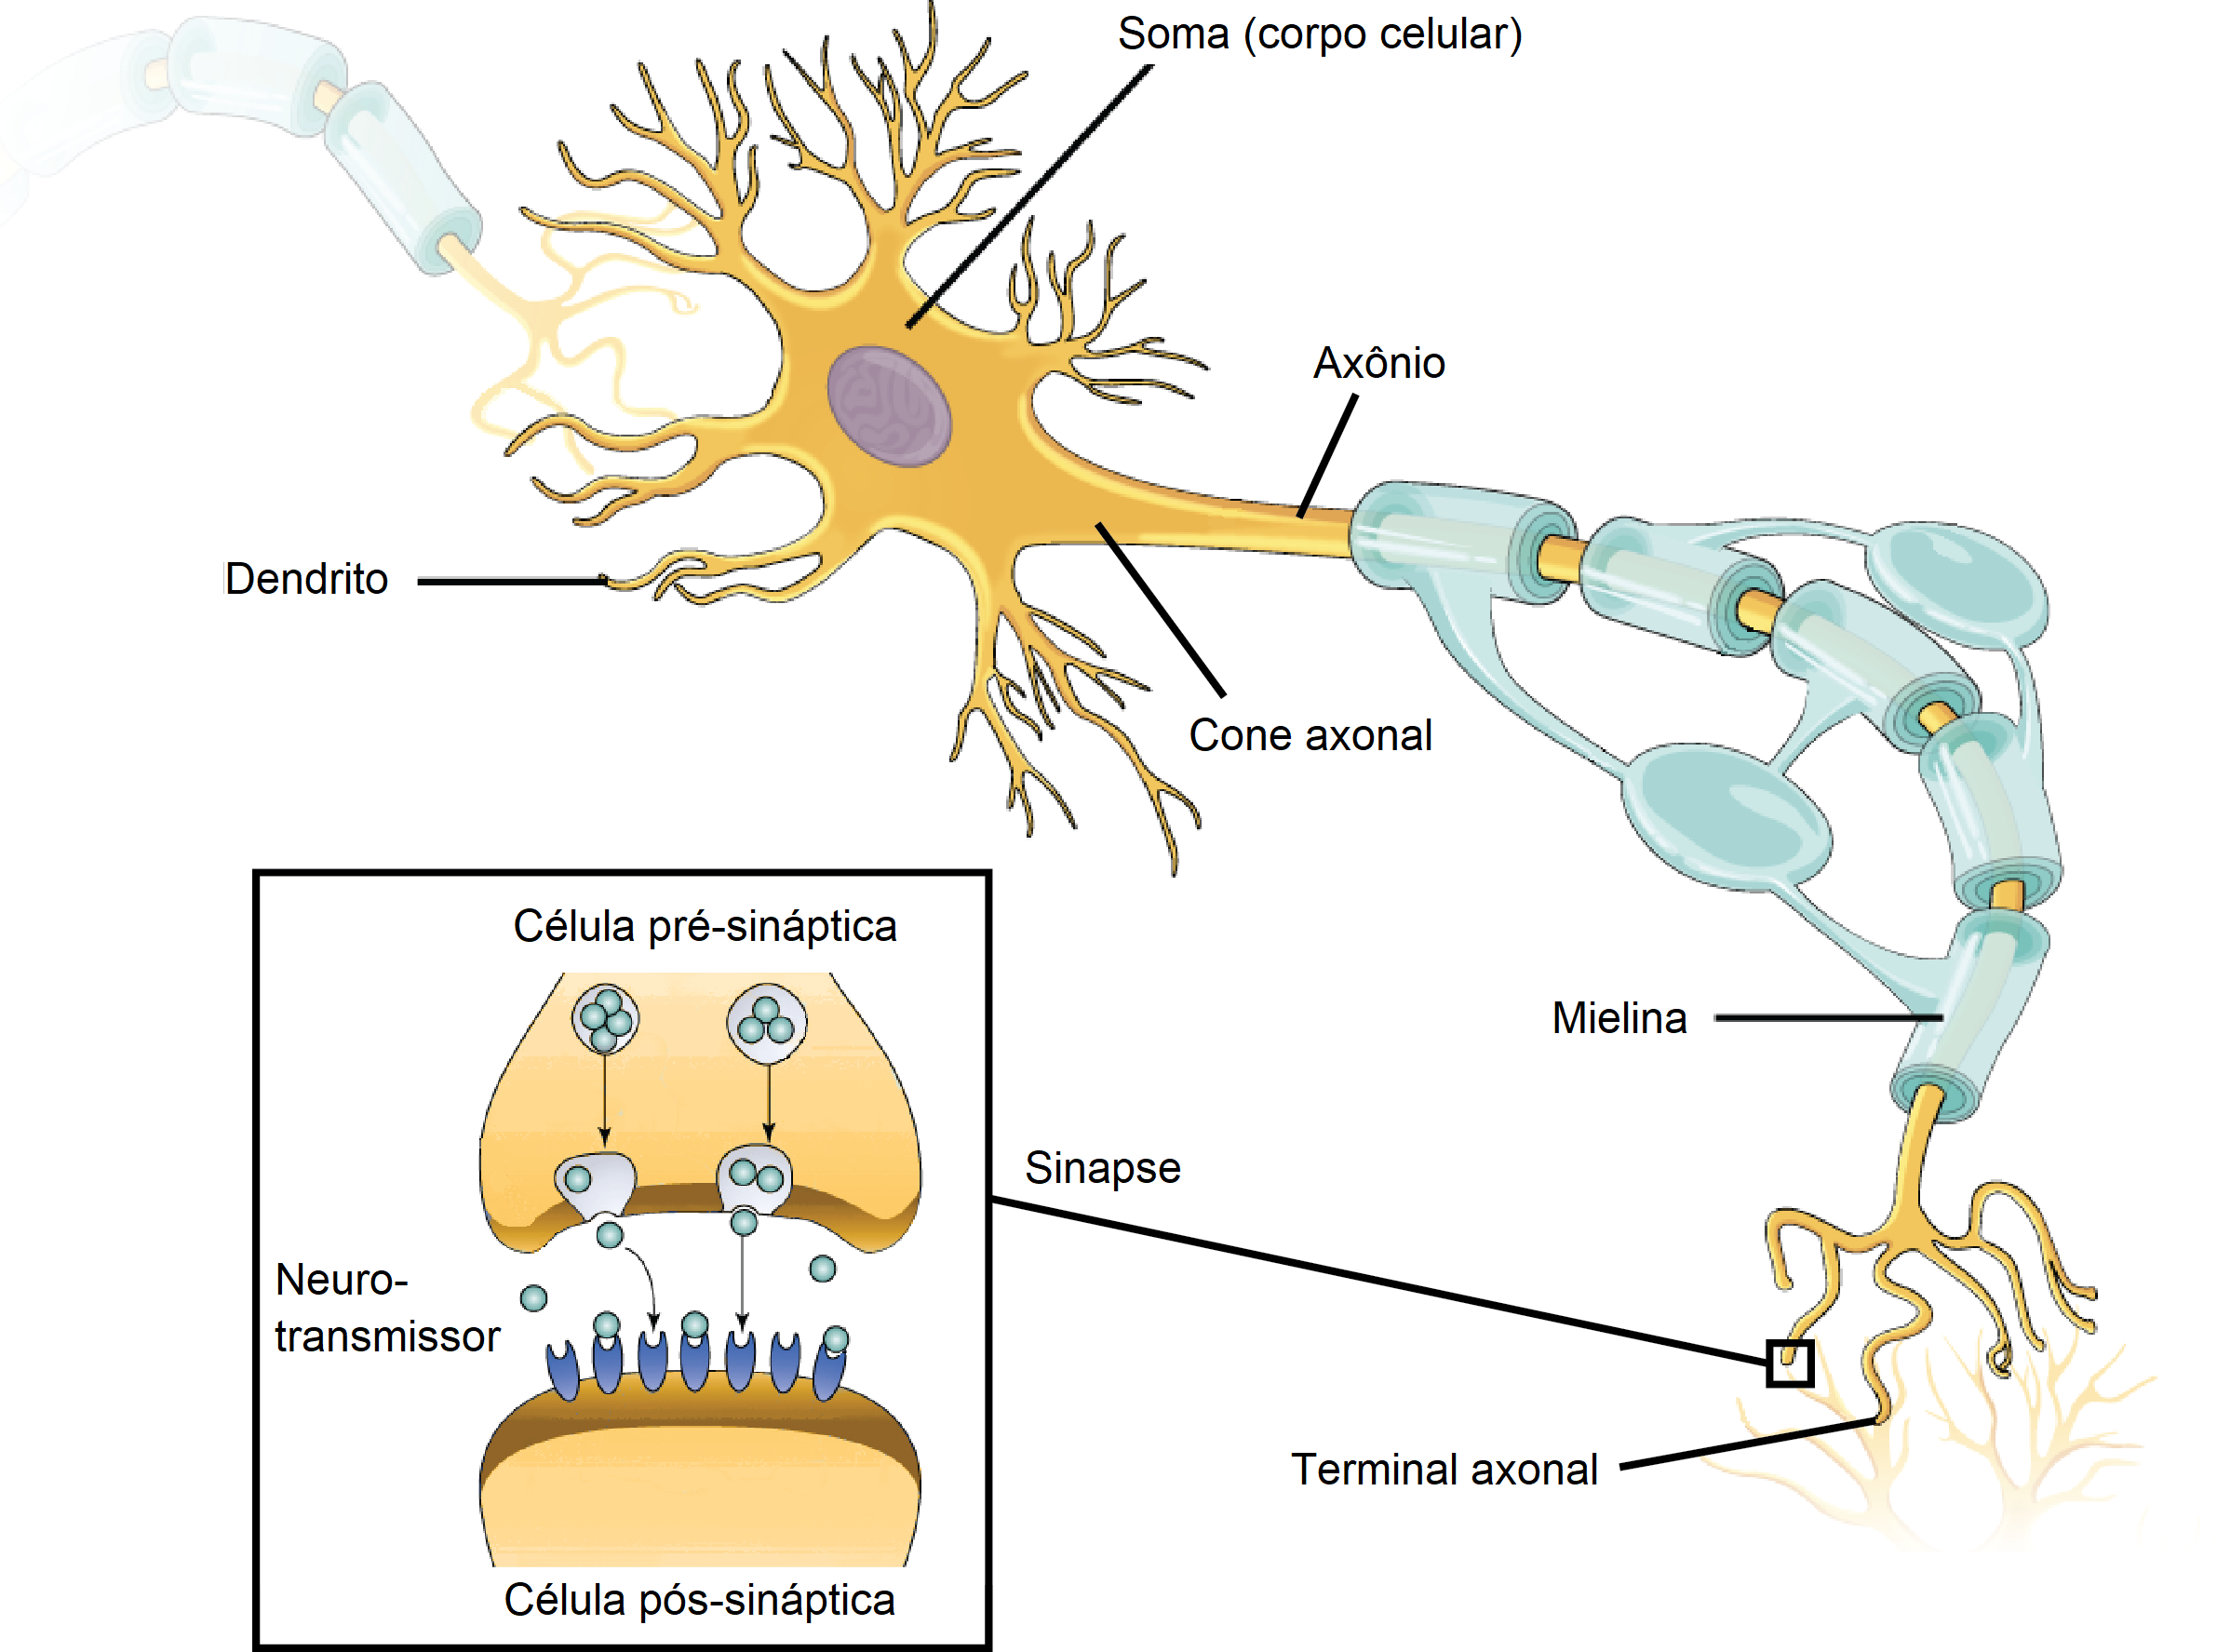


Estas lesões causadas pelo próprio sistema imunológico causa a desmielização, inflamações e dificultam ou impedem a transmissão dos impulsos elétricos no cérebro e na medula espinhal. Na sequência FLAIR, os líquidos cerebrais ficam menos intensos, facilitando a visão de lesões. Tentar-se-à identificar estas regiões de maior intensidade, mensurar seu volume e comparar com marcações de especialistas.




# Desenvolvimento <a name="desenvolvimento"></a>

## Etapa 1 — Redução de ruído <a name="etapa-1-reducao-de-ruido"></a>


O objetivo principal do denoising é atenuar variações de alta frequência (ruído) inseridas durante a aquisição da imagem de RM, mas sem que isso resulte na degradação das transições estruturais legítimas — como as bordas finas que delimitam as lesões desmielinizantes na substância branca (WM).

É importante relembrarmos que, de acordo com o material [ref 2; 4, Slides 3D Spatial Filtering Part 2, Slide 3], os operadores lineares de convolução tendem a "borrar" as bordas de forma indiscriminada. Para evitarmos esse problema, o pipeline do nosso projeto faz o uso de filtros não lineares, que não envolvem convolução e possuem, além disso, melhor criterização para suavização.


Nesta etapa, foram avaliados três métodos de denoising nas imagens T1 e FLAIR:

- Filtro Bilateral;
- Difusão Anisotrópica;
- Média Não-Local.

A avaliação foi qualitativa, comparando a imagem original, a imagem filtrada e a imagem diferença: $ G = |I_{original} - I_{denoised}| $

A interpretação adotada foi que uma imagem diferença com estruturas anatômicas muito evidentes pode indicar remoção de informação relevante - uma vez que o ruído não possui informação estrutural -, como também uma imagem filtrada e ainda ruidosa pode indicar baixa eficácia na redução de ruído.

### 2.1 Leitura e inspeção das imagens <a name="leitura-e-inspecao-das-imagens"></a>

Com base no ITK Software Guide [ref 9, seção 1.5], o processo de leitura de uma imagem envolve:

a) o mecanismo de leitura de um arquivo .nii.gz (NIfTI) utilizando-se de uma classe chamada ImageFileReader;

b) operação de casting (conversão) intitulada CastSImageFilter, envolvendo conversão para ponto flutuante, para aumento de precisão;

c) para a extração de cortes bidimensionais (slices), [ref 9, seção 1.7], o ExtractImageFilter avalia o vetor Size da região de interesse, e, caso uma das dimensões tenha valor nulo, o filtro entende que deve-se extrair a fatia axial bidimensional indexada exatamente naquela posição nula. obs.: os metadados são invariantes, isto é, a slice continua com a mesma orientação física.






Sendo assim, foram carregadas, inicialmente, as imagens **T1** e **FLAIR**, seguidas da inspeção de informações básicas, como: dimensões, espaçamento e visualização da fatia de referência utilizada nas comparações.

In [ ]:
from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

ROOT_DIR = Path("/content/drive/MyDrive/Ferrari_Compartilhado")

PROJECT_DIR = ROOT_DIR / "Trabalho_Ferrari"
DATA_DIR = ROOT_DIR / "Trabalho1-Descricao-20260407"

# Cria PROJECT_DIR caso não exista
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_DIR)

print("Diretório atual:", Path.cwd())
print("Pasta do projeto existe?", PROJECT_DIR.exists())
print("Pasta dos dados existe?", DATA_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Diretório atual: /content/drive/MyDrive/Ferrari_Compartilhado/Trabalho_Ferrari
Pasta do projeto existe? True
Pasta dos dados existe? True


In [ ]:

# Instalação das dependências


# !pip install -q SimpleITK itk itk-elastix


import sys

# Detecta se o notebook está rodando dentro do Google Colab
if 'google.colab' in sys.modules:
    print("Ambiente Google Colab detectado. Instalando dependências na nuvem...")
    !pip install -q SimpleITK==2.5.5 itk==5.4.0 itk-elastix
else:
    print("Ambiente Local/venv detectado. Certifique-se de ter rodado: pip install -r requirements.txt")

Ambiente Google Colab detectado. Instalando dependências na nuvem...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━ 41.9/57.2 MB 14.8 MB/s eta 0:00:02
ERROR: Operation cancelled by user


In [ ]:
#Importações

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
import itk
import pandas as pd

from pathlib import Path

from sklearn.cluster import KMeans
from scipy import ndimage



print(sitk.Version())


SimpleITK Version: 2.5.5 (ITK 5.4)
Compiled: May 12 2026 17:19:38



### 2.2 Modo rápido — opcional <a name="modo-rapido-opcional"></a>

Esta seção carrega resultados já salvos e pode ser usada para continuar a análise sem executar novamente as etapas pesadas. Para reproduzir o pipeline completo, execute as etapas na ordem normal.

In [ ]:



# MODO RÁPIDO - carregar resultados já salvos


from pathlib import Path
import SimpleITK as sitk
import numpy as np

# ------------------------------------------------------------
# Caminhos dos outputs já salvos
# ------------------------------------------------------------

flair_preprocessed_path = Path("./outputs_preprocessing/T01C01_flair_bilateral_preprocessed.nii.gz")
t1_preprocessed_path = Path("./outputs_preprocessing/T01C01_t1_bilateral_preprocessed.nii.gz")

gm_registered_path = Path("./outputs_registration_tissues/gm_registered_to_flair_model_zoo_grid24.nii.gz")
wm_registered_path = Path("./outputs_registration_tissues/wm_registered_to_flair_model_zoo_grid24.nii.gz")
csf_registered_path = Path("./outputs_registration_tissues/csf_registered_to_flair_model_zoo_grid24.nii.gz")

kmeans_path = Path("./outputs_segmentation/lesion_mask_kmeans_p98_min30.nii.gz")
gmm_path = Path("./outputs_segmentation/lesion_mask_gmm_p98_min30.nii.gz")

# ------------------------------------------------------------
# Verificar se os arquivos existem
# ------------------------------------------------------------

paths = [
    flair_preprocessed_path,
    t1_preprocessed_path,
    gm_registered_path,
    wm_registered_path,
    csf_registered_path,
    kmeans_path,
    gmm_path
]

for p in paths:
    print(p, "->", p.exists())

# ------------------------------------------------------------
# Carregar FLAIR e T1 pré-processadas
# ------------------------------------------------------------

flair_preprocessed_img = sitk.ReadImage(str(flair_preprocessed_path))
t1_preprocessed_img = sitk.ReadImage(str(t1_preprocessed_path))

fixed_img = flair_preprocessed_img

flair_array = sitk.GetArrayFromImage(flair_preprocessed_img).astype(np.float32)
t1_array = sitk.GetArrayFromImage(t1_preprocessed_img).astype(np.float32)

flair_seg_array = flair_array

# ------------------------------------------------------------
# Carregar mapas probabilísticos registrados
# ------------------------------------------------------------

gm_registered_img = sitk.ReadImage(str(gm_registered_path))
wm_registered_img = sitk.ReadImage(str(wm_registered_path))
csf_registered_img = sitk.ReadImage(str(csf_registered_path))

gm_registered_array = sitk.GetArrayFromImage(gm_registered_img).astype(np.float32)
wm_registered_array = sitk.GetArrayFromImage(wm_registered_img).astype(np.float32)
csf_registered_array = sitk.GetArrayFromImage(csf_registered_img).astype(np.float32)

# Recriar máscara WM usada na segmentação
wm_threshold = 0.4
wm_mask = wm_registered_array > wm_threshold

# ------------------------------------------------------------
# Carregar segmentações salvas
# ------------------------------------------------------------

clean_lesion_mask = sitk.GetArrayFromImage(
    sitk.ReadImage(str(kmeans_path))
).astype(bool)

clean_lesion_mask_gmm = sitk.GetArrayFromImage(
    sitk.ReadImage(str(gmm_path))
).astype(bool)

print("\nTudo carregado com sucesso.")
print("FLAIR:", flair_seg_array.shape)
print("T1:", t1_array.shape)
print("WM registrada:", wm_registered_array.shape)
print("K-Means:", clean_lesion_mask.shape, "voxels:", np.sum(clean_lesion_mask))
print("GMM:", clean_lesion_mask_gmm.shape, "voxels:", np.sum(clean_lesion_mask_gmm))


# Carregar ground truth do professor


case_folder = Path("../Trabalho1-Descricao-20260407/Imagens_Clinicas/T01C01")

mask1_path = case_folder / "T01C01_mask_1.nii.gz"
mask2_path = case_folder / "T01C01_mask_2.nii.gz"

print("Mask 1 existe?", mask1_path.exists())
print("Mask 2 existe?", mask2_path.exists())

mask1_img = sitk.ReadImage(str(mask1_path))
mask2_img = sitk.ReadImage(str(mask2_path))

mask1_array = sitk.GetArrayFromImage(mask1_img)
mask2_array = sitk.GetArrayFromImage(mask2_img)

gt_mask = (mask1_array > 0) | (mask2_array > 0)

print("Ground truth:", gt_mask.shape)
print("Voxels mask_1:", np.sum(mask1_array > 0))
print("Voxels mask_2:", np.sum(mask2_array > 0))
print("Voxels GT combinado:", np.sum(gt_mask))




outputs_preprocessing/T01C01_flair_bilateral_preprocessed.nii.gz -> True
outputs_preprocessing/T01C01_t1_bilateral_preprocessed.nii.gz -> True
outputs_registration_tissues/gm_registered_to_flair_model_zoo_grid24.nii.gz -> True
outputs_registration_tissues/wm_registered_to_flair_model_zoo_grid24.nii.gz -> True
outputs_registration_tissues/csf_registered_to_flair_model_zoo_grid24.nii.gz -> True
outputs_segmentation/lesion_mask_kmeans_p98_min30.nii.gz -> True
outputs_segmentation/lesion_mask_gmm_p98_min30.nii.gz -> True

Tudo carregado com sucesso.
FLAIR: (181, 217, 181)
T1: (181, 217, 181)
WM registrada: (181, 217, 181)
K-Means: (181, 217, 181) voxels: 22462
GMM: (181, 217, 181) voxels: 19535
Mask 1 existe? True
Mask 2 existe? True
Ground truth: (181, 217, 181)
Voxels mask_1: 17456
Voxels mask_2: 22298
Voxels GT combinado: 24567


In [ ]:
# Caminhos das imagens clínicas
case_folder = DATA_DIR / "Imagens_Clinicas" / "T01C01"

t1_img_path = case_folder / "T01C01_t1.nii.gz"
flair_img_path = case_folder / "T01C01_flair.nii.gz"


"""
A função sitk.RedImage encapsula o pipeline da classe itk::ImageFileReader,
mencionado na primeira célula.

"""


# Leitura das imagens
t1_img = sitk.ReadImage(str(t1_img_path))
flair_img = sitk.ReadImage(str(flair_img_path))

"""
A função 'GetSize()' retorna o vetor tridimensional correspondente ao número
total de voxels alocados ao longo de cada eixo geométrico [X, Y, Z] do espaço
físico;

'GetOrigin()' extrai a coordenada (X, Y, Z) em milímetros correspondente
ao centro do primeiro voxel da imagem (índice [0, 0, 0]) em relação ao ponto
de referência do scanner de Ressonância Magnética;

'GetDirection()' retorna a matriz de rotação ortogonal que relaciona os eixos
da matriz da imagem com as coordenadas físicas anatômicas reais do mundo
(LPS: Left-Posterior-Superior ou RAS: Right-Anterior-Superior)

'GetSpacing()' extrai as dimensões físicas de cada voxel individual em milímetros (mm).
Esta métrica é crucial para a quantificação volumétrica pós-segmentação, etapa
final do projeto.
"""


# Leitura T1
print("T1 lida com sucesso!")
print("Size:", t1_img.GetSize())
print("Spacing:", t1_img.GetSpacing())
print("Origin:", t1_img.GetOrigin())
print("Direction:", t1_img.GetDirection())


# Leitura Flair
print("\nFLAIR lida com sucesso!")
print("Size:", flair_img.GetSize())
print("Spacing:", flair_img.GetSpacing())
print("Origin:", flair_img.GetOrigin())
print("Direction:", flair_img.GetDirection())


"""

Se os vetores de:

'Size', 'Origin' e 'Direction' não forem numericamente idênticos, uma transformação
geométrica e uma reamostragem serão necessárias para que os voxels representem
exatamente o mesmo ponto anatômico no cérebro antes de prosseguir com as demais
etapas do projeto. No entanto, uma observação: ter o mesmo valor numérico destes
vetores não implica que as imagens estejam registradas, como veremos, futuramente.


"""

T1 lida com sucesso!
Size: (181, 217, 181)
Spacing: (1.0, 1.0, 1.0)
Origin: (0.0, 0.0, 0.0)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

FLAIR lida com sucesso!
Size: (181, 217, 181)
Spacing: (1.0, 1.0, 1.0)
Origin: (0.0, 0.0, 0.0)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)


"\n\nSe os vetores de:\n\n'Size', 'Origin' e 'Direction' não forem numericamente idênticos, uma transformação\ngeométrica e uma reamostragem serão necessárias para que os voxels representem\nexatamente o mesmo ponto anatômico no cérebro antes de prosseguir com as demais\netapas do projeto. No entanto, uma observação: ter o mesmo valor numérico destes\nvetores não implica que as imagens estejam registradas, como veremos, futuramente.\n\n\n"

### 2.3 Visualização inicial das modalidades T1 e FLAIR <a name="visualização-inicial-das-modalidades-t1-e-flair"></a>

Nesta seção, são apresentadas as imagens originais das modalidades **T1** e **FLAIR**, utilizadas como base para os testes de redução de ruído (denoising).

A análise foi conduzida sobre uma fatia representativa de cada volume, permitindo comparar visualmente os efeitos dos diferentes filtros aplicados, sendo eles não lineares.

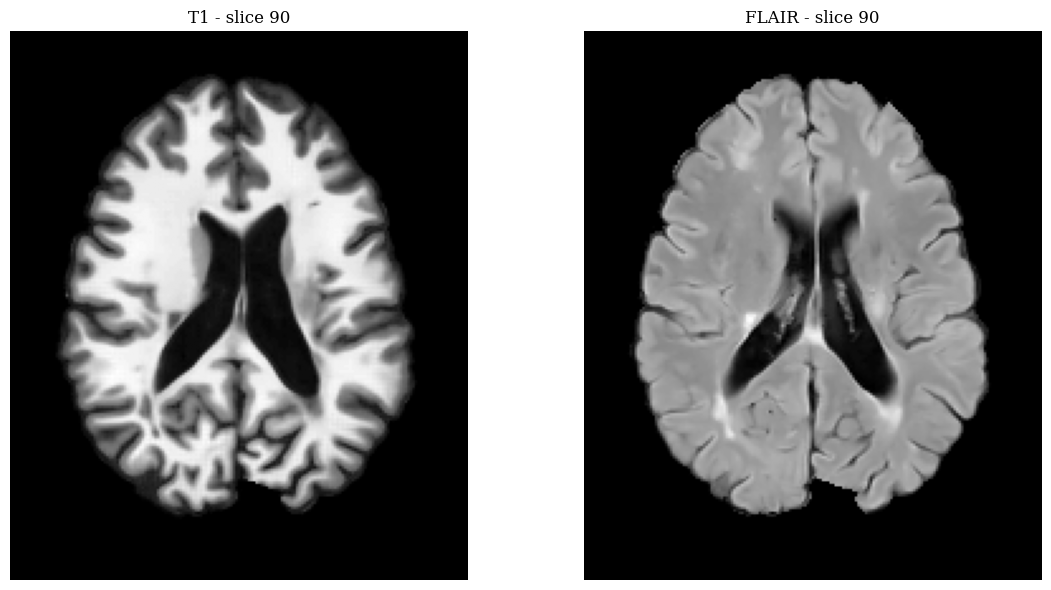

In [ ]:

# Conversão para arrays
t1_img_array = sitk.GetArrayFromImage(t1_img)
flair_img_array = sitk.GetArrayFromImage(flair_img)

# Fatias centrais
slice_t1_img_idx = t1_img_array.shape[0] // 2
slice_flair_idx = flair_img_array.shape[0] // 2


# Mostrando as imagens T1 e Flair
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(t1_img_array[slice_t1_img_idx], cmap="gray")
plt.title(f"T1 - slice {slice_t1_img_idx}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flair_img_array[slice_flair_idx], cmap="gray")
plt.title(f"FLAIR - slice {slice_flair_idx}")
plt.axis("off")

plt.tight_layout()
plt.show()

### 2.4 Aplicação de Filtros Não-Lineares <a name="aplicacao-de-filtros-nao-lineares"></a>



### 2.5 Filtro Bilateral <a name="filtro-bilateral"></a>

O filtro bilateral foi aplicado às imagens T1 e FLAIR com o objetivo de reduzir ruído preservando bordas. Foram utilizados parâmetros diferentes para as modalidades, considerando suas diferenças de contraste e a importância da FLAIR para a etapa posterior de segmentação.

In [ ]:
# Filtro Bilateral na t1

"""

MECANISMO MATEMÁTICO DO FILTRO BILATERAL [ref 9, ITK Software Guide, Book 2, Seção 2.4]:
O método 'sitk.Bilateral' executa o algoritmo 'itk::BilateralImageFilter'. Diferente de um filtro
Gaussiano puro que avalia apenas a distância geométrica, o Bilateral calcula o novo valor do
voxel através do produto de dois núcleos (kernels) Gaussianos independentes.
obs.: o kernel mencionado aqui não se trata de uma matriz estática de
coeficientes fixos e que reliza operação de convolução, mas representam,
em vez disso, funções de ponderação dinâmica.

A equação que rege o peso W aplicado a um voxel vizinho x em relação ao central
depende do:

1. 'Domain Kernel' (Espacial), controlado pelo parâmetro 'domainSigma' ($\sigma_d$).
2. 'Range Kernel' (Contradomínio/Intensidade), controlado pelo parâmetro 'rangeSigma' ($\sigma_r$).

"""

t1_img_float = sitk.Cast(t1_img, sitk.sitkFloat32)

denoised_bilateral_t1_img = sitk.Bilateral(
                                            t1_img_float,
                                            4, #domainSigma, menor suavização mais local, maior uma suavização em uma regiao maior
                                            0.5 #rangeSigma, menor preserva mais diferenças de intensidade, mistura mais intensidades diferentes
                                        )


# Converte para array
denoised_bilateral_t1_img_array = sitk.GetArrayFromImage(denoised_bilateral_t1_img)

# Calcula a a diferença
G_bilateral_t1_img = np.abs(t1_img_array - denoised_bilateral_t1_img_array)






# Filtro bilateral na FLAIR

"""
CONFIGURAÇÃO DOS PARÂMETROS NA FLAIR: (domainSigma = 1, rangeSigma = 0.5) =>
A estratégia de suavização foi modificada ao reduzir o
'domainSigma' para $\sigma_d = 1$, para que o algoritmo restrinja o cálculo da
média local estritamente aos vizinhos espaciais imediatos do voxel.

As lesões desmielinizantes de Esclerose Múltipla manifestam-se na FLAIR como
pequenos focos hiperintensos. Um 'domainSigma' muito largo (como o valor 4 usado
na T1) poderia diluir essas pequenas estruturas patológicas na vizinhança saudável.
A combinação de um raio local curto ($\sigma_d = 1$) com um controle rígido de
intensidade ($\sigma_r = 0.5$) garante que o ruído de alta frequência seja atenuado
sem que a assinatura de brilho e as bordas finas da lesão sofram super-suavização.

"""


flair_img_float = sitk.Cast(flair_img, sitk.sitkFloat32)

denoised_bilateral_flair_img = sitk.Bilateral(
                                            flair_img_float,
                                            1, #domainSigma
                                            0.5 #rangeSigma
                                        )


# Converte para array
denoised_bilateral_flair_img_array = sitk.GetArrayFromImage(denoised_bilateral_flair_img)

# Calcula a diferença
G_bilateral_flair_img = np.abs(flair_img_array - denoised_bilateral_flair_img_array)


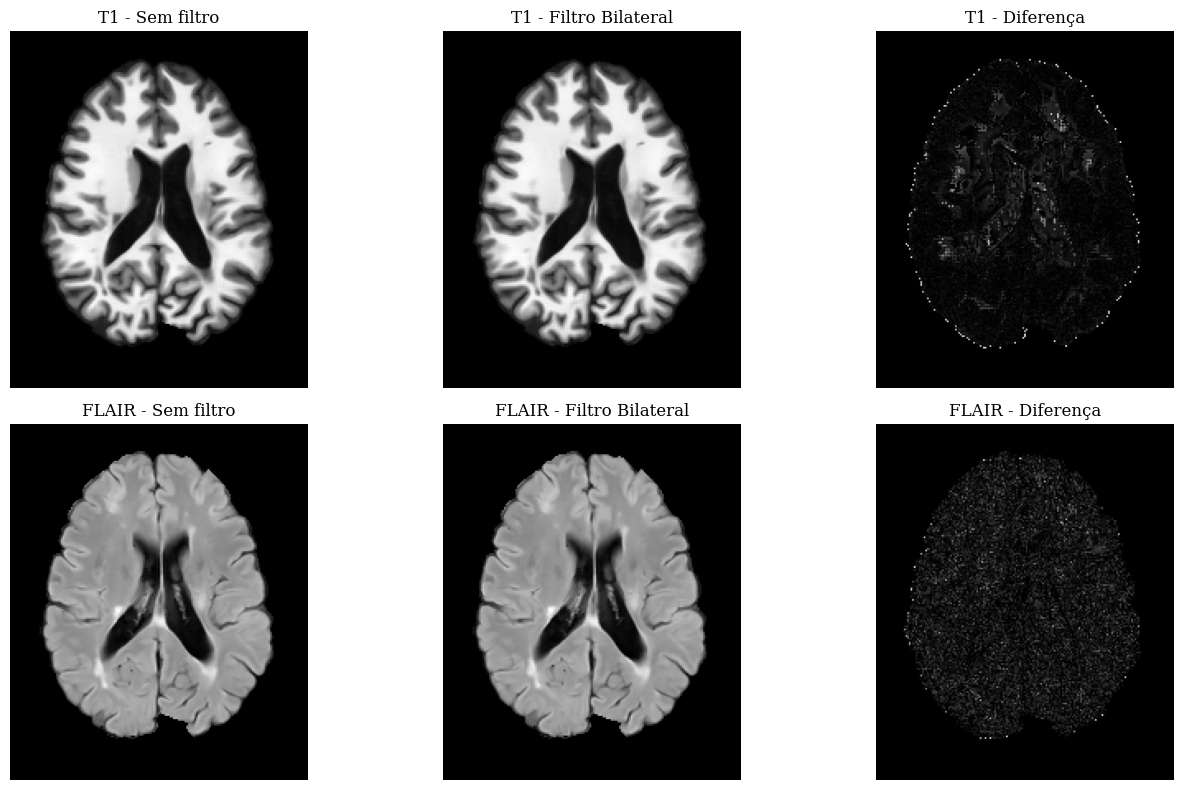

In [ ]:
# Filtro bilateral
# Plot das imagens

plt.figure(figsize=(14, 8))



# T1
plt.subplot(2, 3, 1)
plt.title("T1 - Sem filtro")
plt.imshow(t1_img_array[slice_t1_img_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("T1 - Filtro Bilateral")
plt.imshow(denoised_bilateral_t1_img_array[slice_t1_img_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("T1 - Diferença")
plt.imshow(G_bilateral_t1_img[slice_t1_img_idx], cmap="gray")
plt.axis("off")




# FLAIR
plt.subplot(2, 3, 4)
plt.title("FLAIR - Sem filtro")
plt.imshow(flair_img_array[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("FLAIR - Filtro Bilateral")
plt.imshow(denoised_bilateral_flair_img_array[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("FLAIR - Diferença")
plt.imshow(G_bilateral_flair_img[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

No filtro bilateral, foram utilizados parâmetros diferentes para T1 e FLAIR devido às diferenças de contraste entre as modalidades. Na T1, o `domainSigma` maior permitiu uma suavização espacial mais ampla. Na FLAIR, foi usado um `domainSigma` menor para evitar suavização excessiva de regiões hiperintensas, que podem ser relevantes para a análise de possíveis lesões. O `rangeSigma` foi mantido em 0.5 para preservar transições de intensidade.

**Análise:**  
O filtro bilateral produziu suavização moderada nas imagens T1 e FLAIR, mantendo os contornos anatômicos principais visíveis. A imagem diferença apresentou remoção de sinal de forma relativamente controlada, sem destacar excessivamente estruturas anatômicas completas. Por esse comportamento conservador, o Bilateral foi considerado um bom candidato para continuidade do pipeline.

##### Análise Paramétrica e Resíduo $G$ do Filtro Bilateral

| Imagem | Parâmetros Escolhidos | Comportamento do Filtro<br>(ITK Seção 2.4) | Resíduo<br>$G = \|I_{orig} - I_{denoised}\|$ (Descrição, 1ª Etapa) |
| :--- | :--- | :--- | :--- |
| **T1** | `domainSigma = 4`<br><br>`rangeSigma = 0.5` | **Suavização Ampla:**<br>O raio largo ($\sigma_d = 4$) atua<br>atenuando agressivamente o ruído <br>em regiões homogêneas.<br><br>O contradomínio ($\sigma_r = 0.5$) impede<br>a mistura de tecidos com alto contraste<br>(WM & GM),<br>mantendo as fronteiras nítidas. | <br>Deve apresentar aspecto predominantemente<br> aleatório.<br><br>Como o contraste natural da T1 é alto,<br>a escolha de $\sigma_r = 0.5$ garante que<br>estruturas não sejam apagadas, ou seja,<br>$G$ não deveria exibir silhuetas nítidas, mas<br> os nossos resultados na T1 exibiram estrutu<br>ras anatômicas na imagem resíduo. |
| **FLAIR** | `domainSigma = 1`<br><br>`rangeSigma = 0.5` | **Suavização Localizada:**<br>A redução para $\sigma_d = 1$ restringe<br>a média espacial à vizinhança celular<br>imediata de cada voxel.<br><br>Isso é biologicamente necessário para<br>evitar que pequenos focos hiperintensos<br>(lesões de EM) sejam diluídos ou<br>espalhados na substância branca<br>saudável circundante. | <br> Aparição de pontos brancos brilhantes<br>nas coordenadas das lesões pode indicar<br>super-suavização (falha), significando<br>que a patologia foi extraída do volume. No <br> entanto, podemos ver que não há estrutura<br> anatômica visível na imagem residual,<br> indicando resultados minimamente<br> satisfatórios. |

### 2.6 Difusão Anisotrópica <a name="difusao-anisotropica"></a>

A difusão anisotrópica foi aplicada como uma alternativa de suavização que busca reduzir ruído em regiões homogêneas, preservando bordas e transições de intensidade.

In [ ]:
# Filtro anisiotropic diffusion na T1

"""

O filtro de difusão anisotrópica modela o denoising resolvendo uma Equação
Diferencial Parcial do calor de forma iterativa. Esse processo envolve derivadas
parciais espaciais de gradiente e atualizações incrementais contínuas por passo
de tempo. Operar essas equações no domínio discreto e truncado de inteiros cor-
romperia o cálculo do fluxo. A conversão via 'sitk.Cast'
para 'sitkFloat32' é o pré-requisito que viabiliza a estabilidade matemática
desta aplicação.

"""

t1_img_float = sitk.Cast(t1_img, sitk.sitkFloat32)

denoised_anisio_t1_img = sitk.GradientAnisotropicDiffusion(t1_img_float,
                                                            timeStep=0.0625, # menor processo mais estavel e conservador, maior suavização mais intensa(mais risco de instabilidade)
                                                            conductanceParameter=0.15, #menor preserva mais bordas, maior suaviza mais podendo atravessar bordas
                                                            conductanceScalingUpdateInterval=1, #maior mais suavizção, menor menos suavização
                                                            numberOfIterations=2 #
                                                            )

denoised_anisio_t1_img_array = sitk.GetArrayFromImage(denoised_anisio_t1_img)

G_anisio_t1_img = np.abs(t1_img_array - denoised_anisio_t1_img_array)

"""

ANÁLISE PARAMÉTRICA DA FILTRAGEM NA T1-W:
- timeStep (0.0625): Controla o incremento infinitesimal por iteração. Conforme
as restrições de estabilidade numérica do ITK,
para volumes tridimensionais, o limite máximo seguro para evitar oscilações e
instabilidade matemática da EDP é $1 / 2^D = 1 / 2^3 = 0.125$.
O valor adotado de 0.0625 garante a convergência estável do sistema numérico.

- conductanceParameter (0.15): Define o limiar de sensibilidade do gradiente.
Valores baixos (0.15) agem de forma restritiva:
qualquer transição sutil de intensidade é interpretada pelo algoritmo como uma
borda, bloqueando o fluxo de suavização através dela.

- conductanceScalingUpdateInterval (1): Determina que a condutância de cada voxel
seja recalculada a cada iteração, garantindo
que a adaptação geométrica acompanhe a evolução dinâmica da imagem.

- numberOfIterations (2): O número de passos temporais aplicados. Como foram
executadas apenas 2 iterações, a suavização é curta.

"""




# Filtro anisiotropic diffusion na FLAIR

flair_float = sitk.Cast(flair_img, sitk.sitkFloat32)

denoised_anisio_flair_img = sitk.GradientAnisotropicDiffusion(flair_float,
                                                            timeStep=0.0625,
                                                            conductanceParameter=0.15,
                                                            conductanceScalingUpdateInterval=1,
                                                            numberOfIterations=2
                                                            )

denoised_anisio_flair_img_array = sitk.GetArrayFromImage(denoised_anisio_flair_img)
# Faz a diferença da imgem real com a imagem com filtro
G_anisio_flair_img = np.abs(flair_img_array - denoised_anisio_flair_img_array)

"""

ANÁLISE PARAMÉTRICA DA FILTRAGEM NA FLAIR:
Mantendo a mesma configuração ('timeStep=0.0625', 'conductanceParameter=0.15',
'numberOfIterations=2'), o filtro se comporta de maneira ultra-preservadora na
FLAIR.

Em imagens FLAIR de pacientes com Esclerose Múltipla, o contraste entre a
Substância Branca normal e as lesões desmielinizantes hiperintensas gera um
gradiente local acentuado. Definir a condutância em 0.15 deveria assegurar que
a equação de Perona-Malik zere o coeficiente de difusão imediatamente na periferia
da lesão.

"""


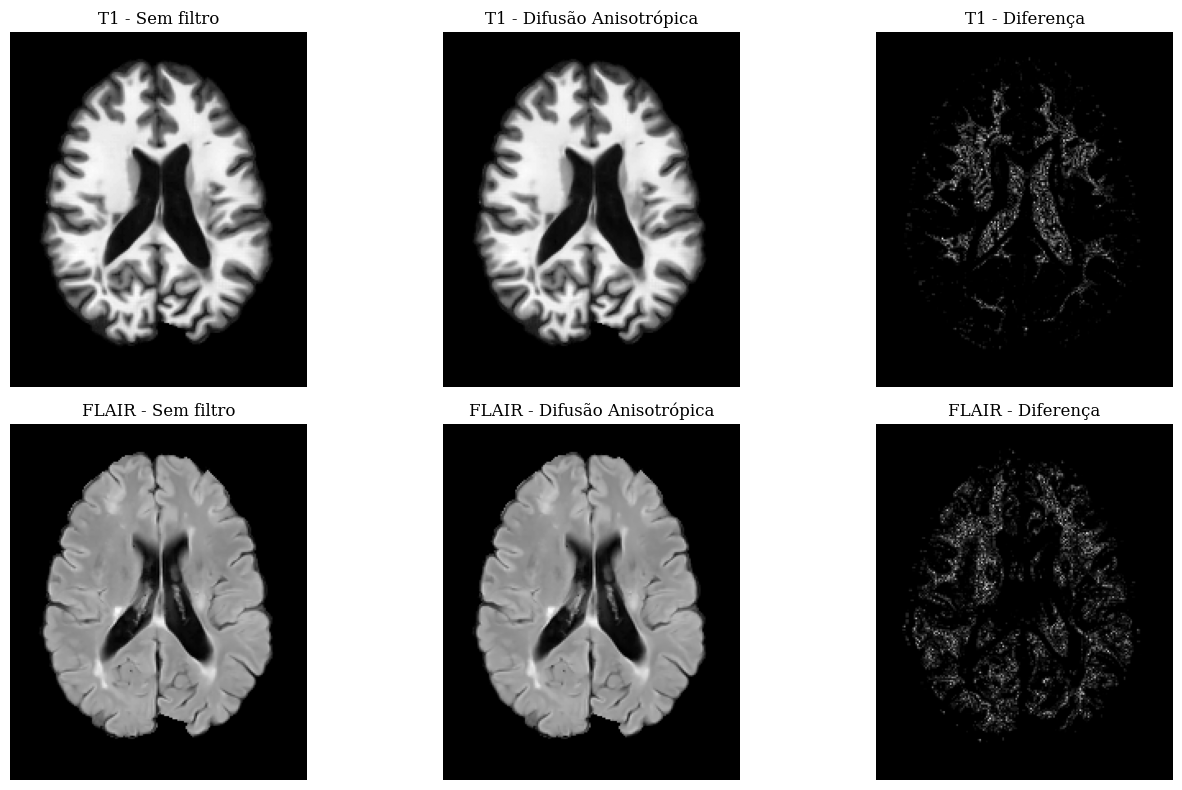

In [ ]:
#Difisão anisiotropica
#Plot das imagens

plt.figure(figsize=(14, 8))

# T1
plt.subplot(2, 3, 1)
plt.title("T1 - Sem filtro")
plt.imshow(t1_img_array[slice_t1_img_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("T1 - Difusão Anisotrópica")
plt.imshow(denoised_anisio_t1_img_array[slice_t1_img_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("T1 - Diferença")
plt.imshow(G_anisio_t1_img[slice_t1_img_idx], cmap="gray")
plt.axis("off")

# FLAIR
plt.subplot(2, 3, 4)
plt.title("FLAIR - Sem filtro")
plt.imshow(flair_img_array[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("FLAIR - Difusão Anisotrópica")
plt.imshow(denoised_anisio_flair_img_array[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("FLAIR - Diferença")
plt.imshow(G_anisio_flair_img[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

### **Análise:**  

A difusão anisotrópica apresentou suavização moderada, com preservação visual das bordas principais. Entretanto, sua resposta depende bastante dos parâmetros escolhidos. Configurações mais fortes tendem a aumentar a suavização, mas também podem fazer com que estruturas anatômicas apareçam com maior evidência na imagem diferença, sugerindo remoção de detalhes relevantes.

### Análise Paramétrica e Resíduo $G$ da Difusão Anisotrópica

| Imagem | Parâmetros Escolhidos | Comportamento do Filtro<br>(ITK Seção 2.5) | Resíduo<br>$G = \|I_{orig} - I_{denoised}\|$ (Descrição, 1ª Etapa) |
| :--- | :--- | :--- | :--- |
| **T1** | `timeStep = 0.0625`<br><br>`conductance = 0.15`<br><br>`scalingUpdate = 1`<br><br>`iterations = 2` | **Difusão Altamente Conservadora:**<br>A condutância baixa ($0.15$) faz com<br>que variações sutis virem bordas.<br><br>O `scalingUpdate = 1` atualiza os<br>gradientes a cada iteração para dar<br>mais dinamismo aos 2 passos aplicados. | <br>Deveria conter apenas ruído (aleatório),<br>mas nossos resultados exibiram contornos<br>da anatomia real na imagem residual $G$.<br><br>Isso indica que mesmo com poucas iterações,<br>o filtro acabou atenuando texturas<br>legítimas do tecido cerebral ou que as<br>estruturas internas tinham gradientes baixos<br>o suficiente para o fluxo de calor atravessar. |
| **FLAIR** | `timeStep = 0.0625`<br><br>`conductance = 0.15`<br><br>`scalingUpdate = 1`<br><br>`iterations = 2` | **Preservação Local de Hiperintensidades:**<br>A barreira em $0.15$ tenta zerar a<br>difusão ao redor das lesões de EM.<br><br>A atualização a cada passo (`1`) garante<br>que o mapa de condutância se adapte<br>conforme o ruído adjacente diminui,<br>blindando as transições patológicas. | <br>Não deveria haver silhuetas ou manchas<br>lesionais na imagem de diferença.<br><br>No entanto, nossos resultados na FLAIR<br>também mostraram traços visíveis da<br>anatomia. Isso significa que<br>partes das bordas lesionais ou corticais<br>podem ter sido levemente borradas e<br>vazadas para a imagem residual. |

### 2.7 Média Não-Local (NLM) <a name="media-nao-local-nlm"></a>

O filtro de Média Não-Local foi aplicado como uma alternativa baseada em similaridade entre patches. Diferente de filtros puramente locais, o NLM pode utilizar regiões semelhantes da imagem para estimar a intensidade filtrada. Foram utilizados parâmetros conservadores para reduzir custo computacional e evitar suavização excessiva.

In [ ]:
# Filtro NLM no T1 - versão mais leve para teste

"""

MÉDIA NÃO-LOCAL [ref 2; 4, Slides Part 1]:
Diferente dos filtros anteriores, o NLM assume
que imagens médicas possuem redundância estrutural.
O valor final de um voxel não depende de seus
vizinhos geométricos imediatos, mas sim da
similaridade entre o seu bloco ('patch') atual
e outros blocos distribuídos no volume.

A filtragem por patches baseia-se no cálculo
da Distância Euclidiana Média entre blocos
de voxels.

PARAMETRIZAÇÃO NA T1-W:

- kernelBandwidthSigma (0.4): É o parâmetro 'h'
  da fórmula do NLM. Controla o decaimento do
  peso. Valores menores filtram de forma mais
  conservadora, exigindo alta similaridade.

- patchRadius (1): Define o tamanho do patch.
  Escolhemos um raio pequeno para evitar alto
  custo computacional (e alta latência).

- numberOfSamplePatches (20): Versão leve.
  Amostra apenas 20 patches para estimar a
  distribuição do ruído e calcular os pesos.

- sampleVariance (400.0): Estimativa da
  variância nominal do ruído na imagem.

"""

t1_img_float = sitk.Cast(t1_img, sitk.sitkFloat32)

denoised_NLM_t1_img = sitk.PatchBasedDenoising(
    t1_img_float,
    0.4,   # kernelBandwidthSigma, menor filtro mais conservador, maior mais suavização
    1,     # patchRadius, menor compara regioes menores, maior compara regioes maiores
    1,     # numberOfIterations
    20,    # numberOfSamplePatches, quantos patches sao amostrados para estimar a suavizção
    400.0  # sampleVariance,
)

denoised_NLM_t1_img_array = sitk.GetArrayFromImage(denoised_NLM_t1_img)

G_NLM_t1_img = np.abs(t1_img_array - denoised_NLM_t1_img_array)



# Filtro NLM na FLAIR

flair_float = sitk.Cast(flair_img, sitk.sitkFloat32)

denoised_NLM_flair_img = sitk.PatchBasedDenoising(flair_float,
                                            0.5,   # kernelBandwidthSigma
                                            2,      # patchRadius
                                            1,      # numberOfIterations
                                            100,    # numberOfSamplePatches
                                            400.0   # sampleVariance
                                            )

denoised_NLM_flair_img_array = sitk.GetArrayFromImage(denoised_NLM_flair_img)

# Faz a diferença da imagem real com a imgem com filtro
G_NLM_flair_img = np.abs(flair_img_array - denoised_NLM_flair_img_array)

"""
ANÁLISE PARAMÉTRICA DA FILTRAGEM NA FLAIR:

- kernelBandwidthSigma (0.5): Um limiar ligeiramente
  mais permissivo que o da T1, aumentando o
  poder de suavização do ruído de fundo.

- patchRadius (2): Bloco maior. Na tentativa de elevar a
  precisão do reconhecimento de texturas complexas.

- numberOfSamplePatches (100): Amostragem robusta.
  Tentativa de distribuir melhor a busca
  não-local, tornando o filtro estatisticamente
  muito mais eficiente e estável.

"""

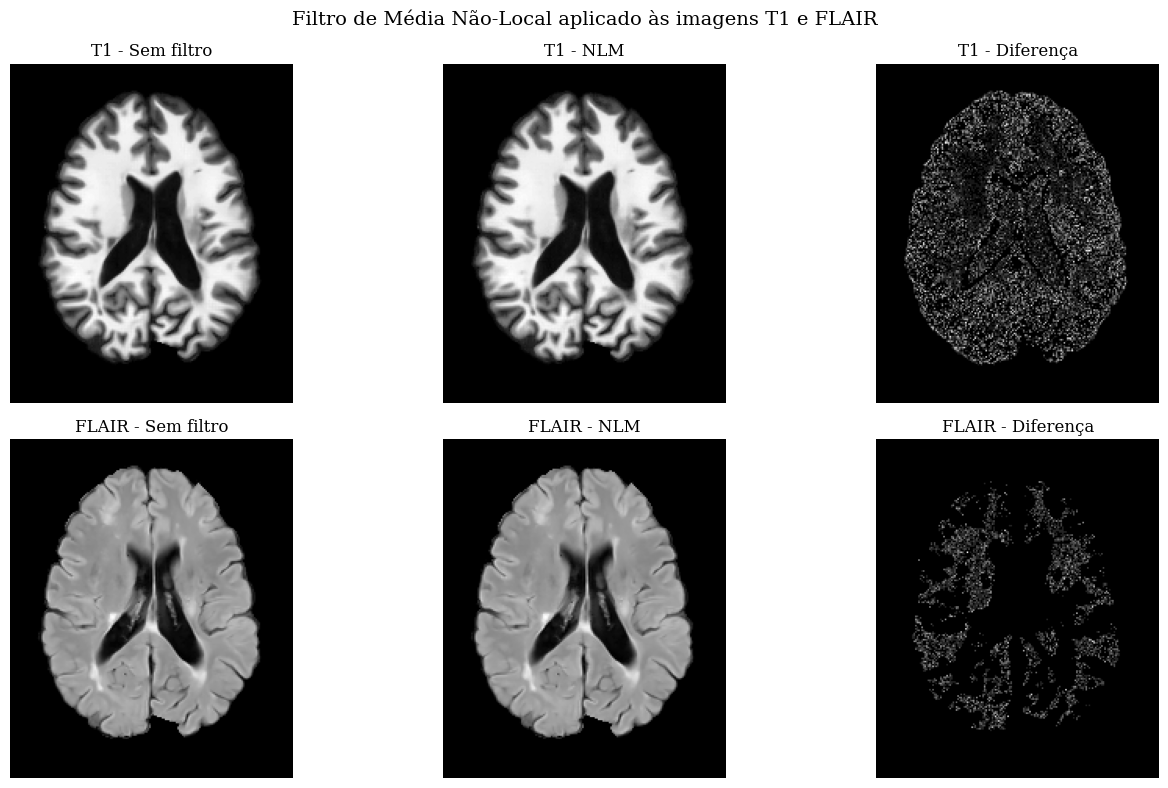

In [ ]:
# Filtro NLM
# Plot das imagens


plt.figure(figsize=(14, 8))

# T1
plt.subplot(2, 3, 1)
plt.title("T1 - Sem filtro")
plt.imshow(t1_img_array[slice_t1_img_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("T1 - NLM")
plt.imshow(denoised_NLM_t1_img_array[slice_t1_img_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("T1 - Diferença")
plt.imshow(G_NLM_t1_img[slice_t1_img_idx], cmap="gray")
plt.axis("off")

# FLAIR
plt.subplot(2, 3, 4)
plt.title("FLAIR - Sem filtro")
plt.imshow(flair_img_array[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.title("FLAIR - NLM")
plt.imshow(denoised_NLM_flair_img_array[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.title("FLAIR - Diferença")
plt.imshow(G_NLM_flair_img[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.suptitle("Filtro de Média Não-Local aplicado às imagens T1 e FLAIR", fontsize=14)
plt.tight_layout()
plt.show()

###

No NLM, foram utilizados parâmetros conservadores, com apenas uma iteração. Na T1, foi usado `patchRadius = 1` e `numberOfSamplePatches = 20`, priorizando menor custo computacional. Na FLAIR, foi usado `patchRadius = 2` e `numberOfSamplePatches = 100`, buscando uma estimativa mais robusta dos patches.

### **Análise:**  
O NLM apresentou suavização visualmente estável, mas com maior custo computacional. Nas imagens diferença, observou-se remoção de informação anatômica, principalmente na T1. Para os parâmetros utilizados, o filtro não foi escolhido como principal por apresentar uma remoção menos conservadora que o Bilateral.

### Análise Paramétrica e Resíduo $G$ do Filtro Non-Local Means

| Imagem | Parâmetros Escolhidos | Comportamento do Filtro<br>(ITK / Slides Part 1) | Resíduo<br>$G = \|I_{orig} - I_{denoised}\|$ (Descrição, 1ª Etapa) |
| :--- | :--- | :--- | :--- |
| **T1** | `kernelSigma = 0.4`<br><br>`patchRadius = 1`<br><br>`samplePatches = 20` | **Filtragem Leve:**<br>Usa blocos/patches pequenos.<br>A busca restrita torna<br>o processo rápido, mas limita a<br>capacidade estatística do filtro de<br>reconhecer padrões complexos. | <br>Deveria conter apenas ruído isolado.<br><br>No entanto, a amostragem muito baixa de<br>20 patches prejudicou a estimativa,<br>fazendo com que nossos resultados em $G$<br>exibissem estruturas anatômicas evidentes,<br>o que caracteriza perda de sinal real. |
| **FLAIR** | `kernelSigma = 0.5`<br><br>`patchRadius = 2`<br><br>`samplePatches = 100` | **Filtragem +Robusta:**<br>Eleva os blocos/patches.<br>Avaliar mais patches permite mapear<br>com melhor precisão a redundância das<br>estruturas, separando teoricamente<br>o ruído da anatomia saudável. | <br>Não deveria conter silhuetas anatômicas<br>ou lesões extraídas no mapa de diferença.<br><br>Contudo, nossos resultados na FLAIR<br>também mostraram estrutura evidente. Isso<br>indica que o raio do patch ou a largura da<br>banda (`0.5`) acabou incluindo informações<br>estruturais legítimas na média estatística. |

### 2.8  Comparação final entre os filtros <a name="comparacao-final-entre-os-filtros"></a>

Após a aplicação dos métodos de denoising, foi realizada uma comparação visual entre os filtros testados, considerando separadamente as imagens T1 e FLAIR.

A comparação final foi baseada principalmente em três aspectos:

- nível de suavização obtido;
- preservação das bordas e estruturas anatômicas principais;
- presença de anatomia visível na imagem diferença \(G\).

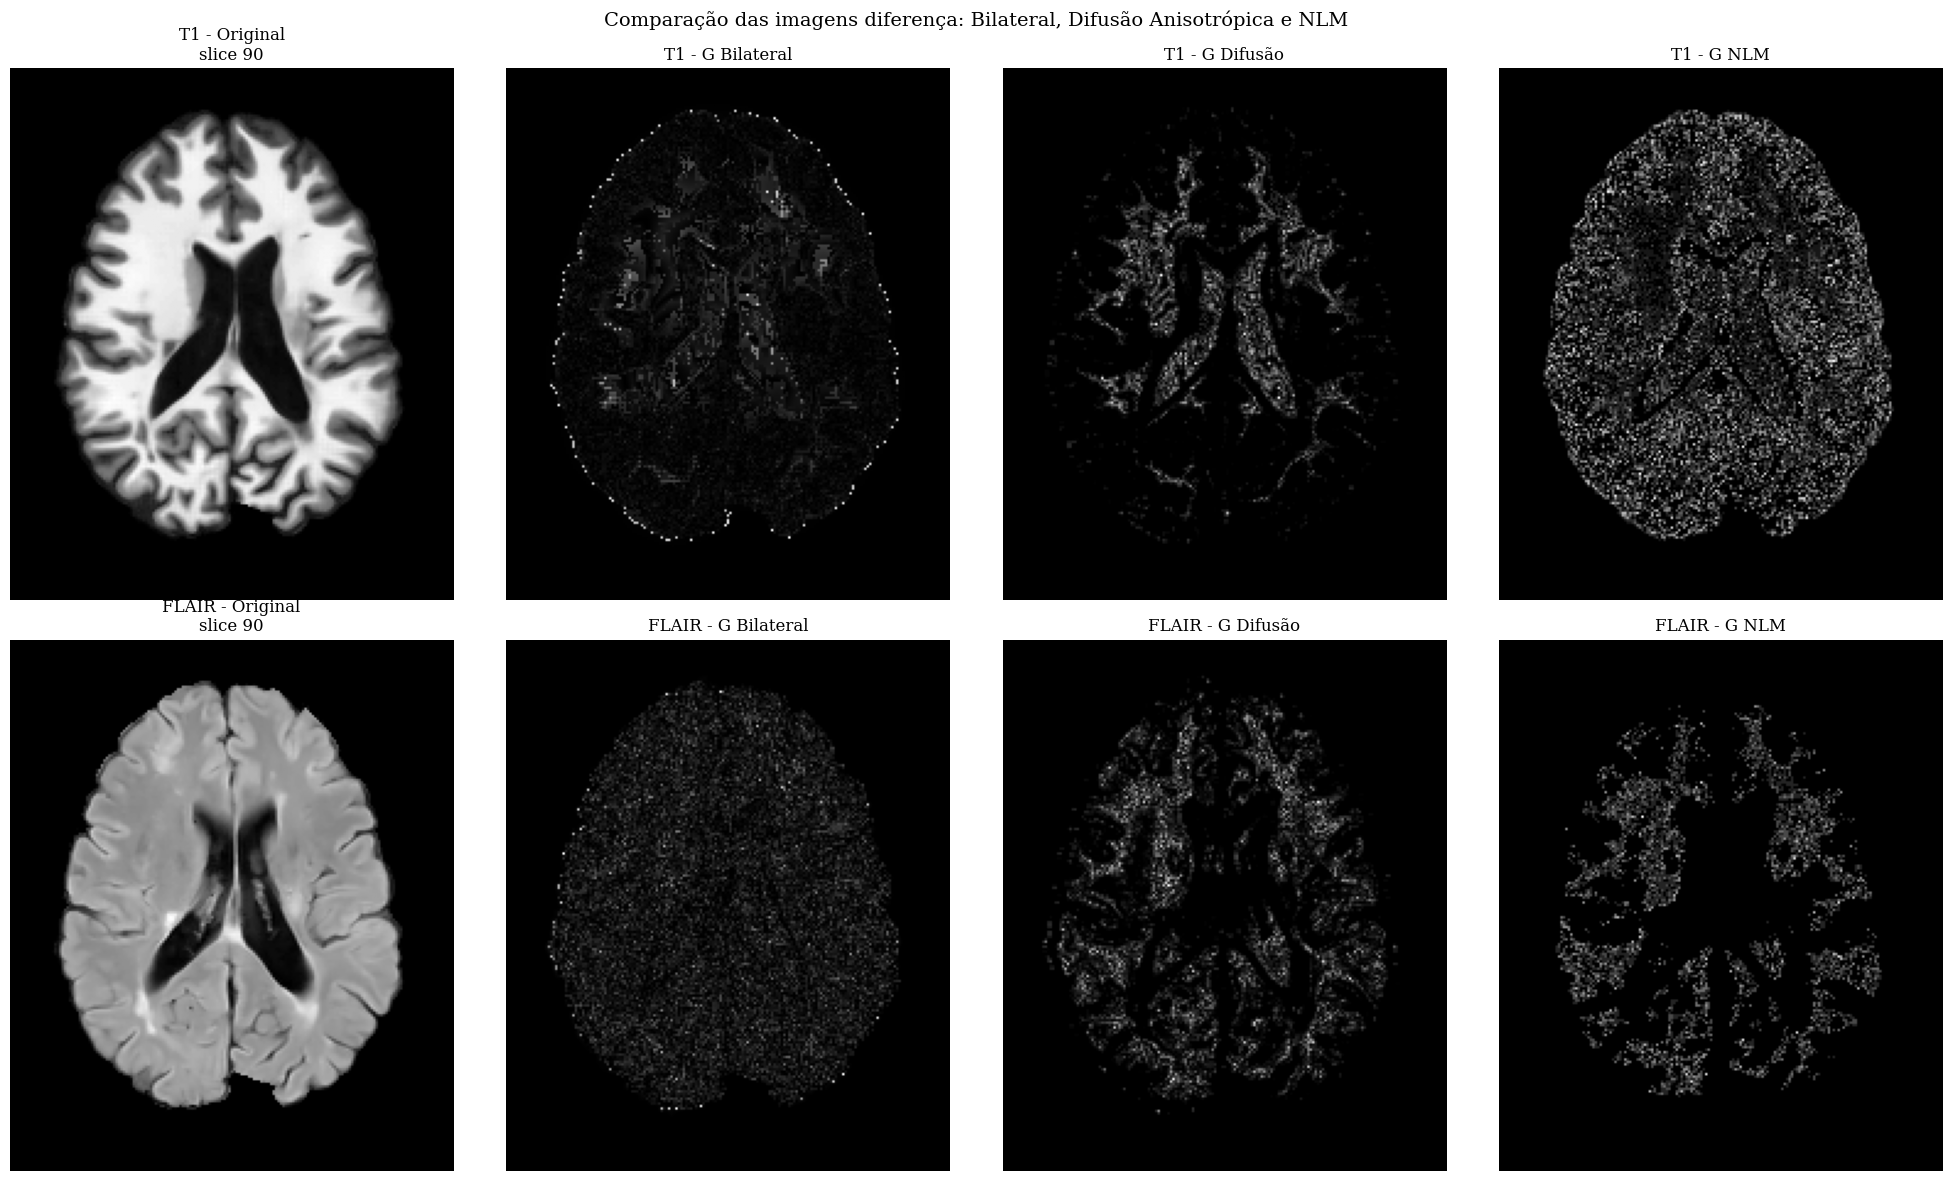

In [ ]:
#Comparação dos resutaldos dos filtros
#plot das imagens

plt.figure(figsize=(20, 12))

# =========================
# T1
# =========================
plt.subplot(2, 4, 1)
plt.title(f"T1 - Original\nslice {slice_t1_img_idx}")
plt.imshow(t1_img_array[slice_t1_img_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.title("T1 - G Bilateral")
plt.imshow(G_bilateral_t1_img[slice_t1_img_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.title("T1 - G Difusão")
plt.imshow(G_anisio_t1_img[slice_t1_img_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.title("T1 - G NLM")
plt.imshow(G_NLM_t1_img[slice_t1_img_idx], cmap="gray")
plt.axis("off")


# =========================
# FLAIR
# =========================
plt.subplot(2, 4, 5)
plt.title(f"FLAIR - Original\nslice {slice_flair_idx}")
plt.imshow(flair_img_array[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.title("FLAIR - G Bilateral")
plt.imshow(G_bilateral_flair_img[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.title("FLAIR - G Difusão")
plt.imshow(G_anisio_flair_img[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.title("FLAIR - G NLM")
plt.imshow(G_NLM_flair_img[slice_flair_idx], cmap="gray")
plt.axis("off")

plt.suptitle("Comparação das imagens diferença: Bilateral, Difusão Anisotrópica e NLM", fontsize=14)
plt.tight_layout()
plt.show()

###


**Síntese da T1:**  
Na T1, os três filtros produziram alterações visuais relativamente sutis. A análise das imagens diferença indicou que o Bilateral apresentou comportamento mais conservador, enquanto o NLM e a Difusão Anisotrópica removeram informação de forma mais distribuída, dependendo dos parâmetros.

**Síntese da FLAIR:**  
Na FLAIR, a preservação das regiões hiperintensas é especialmente importante para a continuidade do pipeline. O Bilateral foi mantido por apresentar suavização sem evidenciar remoção excessiva de estruturas na imagem diferença, preservando melhor a aparência das regiões relevantes para a etapa de segmentação.

### 2.9 Conclusão da Etapa 1 <a name="conclusao-da-etapa-1"></a>

Nesta etapa, foram avaliados três métodos de redução de ruído aplicados às imagens T1 e FLAIR: Bilateral, Difusão Anisotrópica e Média Não-Local. A avaliação foi realizada de forma qualitativa, considerando a imagem filtrada e a imagem diferença: $G = |I_{original} - I_{denoised}|$

A Difusão Anisotrópica apresentou suavização moderada, mas seu comportamento é bastante dependente dos parâmetros. Configurações mais fortes podem aumentar a suavização, porém também aumentam o risco de remover detalhes anatômicos importantes.

O NLM apresentou boa capacidade de suavização, mas, para os parâmetros utilizados, mostrou remoção de informação mais distribuída na imagem diferença e maior custo computacional.

O filtro Bilateral apresentou o comportamento mais conservador na comparação final, com redução de ruído sem evidenciar remoção excessiva de estruturas anatômicas nas imagens diferença. Por esse motivo, foi escolhido como pré-processamento principal para a continuidade do pipeline nas etapas de registro e segmentação.

In [ ]:

# Imagens escolhidas para continuidade do pipeline


t1_preprocessed_img = denoised_bilateral_t1_img
flair_preprocessed_img = denoised_bilateral_flair_img

t1_preprocessed_array = denoised_bilateral_t1_img_array
flair_preprocessed_array = denoised_bilateral_flair_img_array

print("Imagem T1 pré-processada escolhida: Bilateral")
print("Imagem FLAIR pré-processada escolhida: Bilateral")

Imagem T1 pré-processada escolhida: Bilateral
Imagem FLAIR pré-processada escolhida: Bilateral


In [ ]:

# Salvamento da FLAIR pré-processada para uso no Elastix


output_dir_preprocessing = Path("./outputs_preprocessing")
output_dir_preprocessing.mkdir(parents=True, exist_ok=True)

flair_preprocessed_path = output_dir_preprocessing / "T01C01_flair_bilateral_preprocessed.nii.gz"
t1_preprocessed_path = output_dir_preprocessing / "T01C01_t1_bilateral_preprocessed.nii.gz"

sitk.WriteImage(flair_preprocessed_img, str(flair_preprocessed_path))
sitk.WriteImage(t1_preprocessed_img, str(t1_preprocessed_path))

print("FLAIR pré-processada salva em:", flair_preprocessed_path)
print("T1 pré-processada salva em:", t1_preprocessed_path)

FLAIR pré-processada salva em: outputs_preprocessing/T01C01_flair_bilateral_preprocessed.nii.gz
T1 pré-processada salva em: outputs_preprocessing/T01C01_t1_bilateral_preprocessed.nii.gz


## Etapa 2 — Registro espacial e alinhamento dos atlas probabilísticos <a name="registro-espacial-e-alinhamento-dos-atlas-probabilisticos"></a>


o atlas anatômico T1 e seus respectivos mapas probabilísticos — Substância Cinzenta (GM), Substância Branca (WM) e Líquido Cefalorraquidiano (CSF) — são geometricamente mapeados para o espaço nativo da imagem FLAIR clínica pré-processada.

A escolha da FLAIR como **Imagem Fixa** ($I_F$) justifica-se por ser esta a modalidade empregada nas etapas subsequentes de segmentação de hiperintensidades lesionais - uma vez que as lesões aparecem, nesta modalidade, hiperintensas. O atlas T1 atua como **Imagem Móvel** ($I_M$), guiando a convergência matemática para a posterior propagação dos mapas de probabilidade tecidual.

Conforme a formulação matemática clássica adotada pelo framework do `elastix` [ref 10, Klein & Staring, 2026, Seção 2.1, Pág. 3], o problema do registro consiste em encontrar uma transformação $\mathbf{T}(\vec{x})$ que mapeia a coordenada física do espaço da imagem fixa para o espaço da imagem móvel, tal que:

$$\mathbf{T} : \Omega_F \subset \mathbb{R}^d \to \Omega_M \subset \mathbb{R}^d$$

Onde $\Omega_{F} \wedge \Omega_{M}$ representam o domínio espacial de definição das funções de imagem fixa e movel, respectivamente.

---


Resumindo, nesta etapa, o atlas T1 e os mapas probabilísticos GM, WM e CSF são alinhados ao espaço da imagem FLAIR clínica pré-processada.

A FLAIR filtrada pelo Bilateral foi utilizada como imagem fixa, pois é a modalidade utilizada posteriormente na segmentação das possíveis lesões. O atlas T1 mascarado foi utilizado como imagem móvel.

Foram avaliadas quatro configurações de registro:

- rígido;
- rígido + afim;
- rígido + afim + BSpline;
- rígido + afim + BSpline Model Zoo grid 24.

A avaliação foi feita visualmente por checkerboard. Ao final, a transformação escolhida foi aplicada aos mapas probabilísticos GM, WM e CSF.

### 3.1 Leitura do atlas e dos mapas probabilísticos <a name="leitura-do-atlas-e-dos-mapas-probabilisticos"></a>

São carregados o atlas T1 de referência e os mapas probabilísticos de substância cinzenta (GM), substância branca (WM) e líquor (CSF). Esses mapas serão posteriormente transformados para o espaço da FLAIR.

In [ ]:

# Leitura do atlas e dos mapas probabilísticos


atlas_folder = DATA_DIR / "Atlas"

atlas_t1_path = atlas_folder / "mni_T1w_ref.nii.gz"
atlas_gm_path = atlas_folder / "mni_gm.nii.gz"
atlas_wm_path = atlas_folder / "mni_wm.nii.gz"
atlas_csf_path = atlas_folder / "mni_csf.nii.gz"

"""

CARREGAMENTO VIA SIMPLEITK:

Conforme destacado no elastix manual [ref 10, Seção 2.2, Pág. 5],
as imagens são tratadas como funções definidas
sobre domínios físicos espaciais

A leitura preserva informações importantes (como os metadados)
das imagens NIfTI, e contém as matrizes de transformação
para o espaço físico, informações importantes para a interpolação
necessária nos próximos passos.

"""

atlas_t1_img = sitk.ReadImage(str(atlas_t1_path))
atlas_gm_img = sitk.ReadImage(str(atlas_gm_path))
atlas_wm_img = sitk.ReadImage(str(atlas_wm_path))
atlas_csf_img = sitk.ReadImage(str(atlas_csf_path))

print("Atlas e mapas probabilísticos carregados com sucesso.")

Atlas e mapas probabilísticos carregados com sucesso.


### 3.2 Inspeção dos metadados espaciais <a name="inspecao-dos-metadados-espaciais"></a>

Antes do registro, foram verificados `Size`, `Spacing`, `Origin` e `Direction` das imagens. Essa inspeção confirma que os mapas GM, WM e CSF estão no mesmo espaço do atlas T1, enquanto a FLAIR clínica possui uma grade espacial diferente, exigindo registro espacial.

In [ ]:
"""
A execução da rotina abaixo visa validar a consistência espacial interna
dos mapas do atlas e evidenciar o desalinhamento
em relação à imagem do paciente.

FUNÇÃO AUXILIAR DE EXTRAÇÃO DE METADADOS:
Exibe as quatro propriedades geométricas fundamentais do ITK.
Se 'Origin', 'Spacing' ou 'Direction' divergirem entre dois volumes,
as matrizes não compartilham a mesma grade física, tornando
operações diretas (voxel-a-voxel) matematicamente inválidas.

"""

# Inspeção dos metadados espaciais


def print_metadata(name, image):
    print(f"=== {name} ===")
    print("Size:", image.GetSize())
    print("Spacing:", image.GetSpacing())
    print("Origin:", image.GetOrigin())
    print("Direction:", image.GetDirection())
    print()

print_metadata("FLAIR pré-processada", flair_preprocessed_img)
print_metadata("Atlas T1", atlas_t1_img)
print_metadata("Atlas GM", atlas_gm_img)
print_metadata("Atlas WM", atlas_wm_img)
print_metadata("Atlas CSF", atlas_csf_img)

=== FLAIR pré-processada ===
Size: (181, 217, 181)
Spacing: (1.0, 1.0, 1.0)
Origin: (0.0, 0.0, 0.0)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

=== Atlas T1 ===
Size: (256, 256, 256)
Spacing: (1.0, 1.0, 1.0)
Origin: (-127.5, -127.5, -127.5)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

=== Atlas GM ===
Size: (256, 256, 256)
Spacing: (1.0, 1.0, 1.0)
Origin: (-127.5, -127.5, -127.5)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

=== Atlas WM ===
Size: (256, 256, 256)
Spacing: (1.0, 1.0, 1.0)
Origin: (-127.5, -127.5, -127.5)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

=== Atlas CSF ===
Size: (256, 256, 256)
Spacing: (1.0, 1.0, 1.0)
Origin: (-127.5, -127.5, -127.5)
Direction: (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)



A inspeção dos metadados confirma que os mapas GM, WM e CSF estão no mesmo espaço do atlas T1. Como a FLAIR clínica possui grade espacial diferente, o atlas da T1 deve ser registrado no espaço da FLAIR antes que os mapas probabilísticos sejam utilizados nas etapas seguintes.

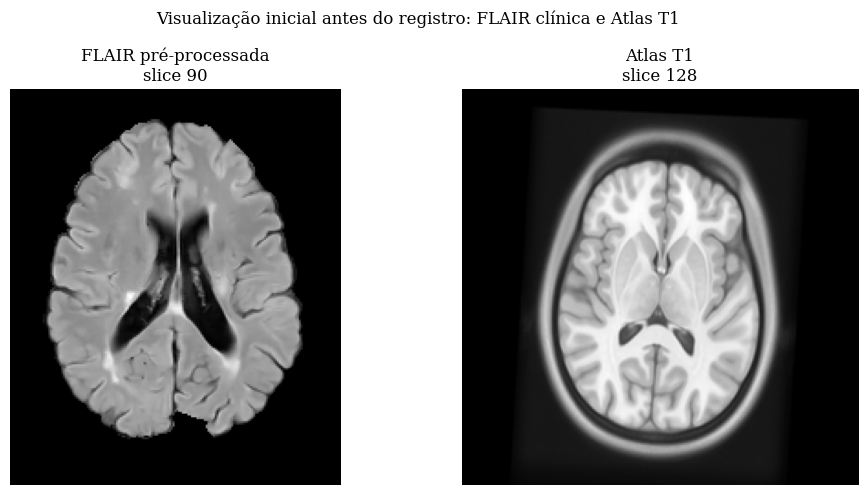

In [ ]:

# Visualização inicial: FLAIR pré-processada e atlas T1


flair_preprocessed_array = sitk.GetArrayFromImage(flair_preprocessed_img)
atlas_t1_array = sitk.GetArrayFromImage(atlas_t1_img)

slice_flair = flair_preprocessed_array.shape[0] // 2
slice_atlas = atlas_t1_array.shape[0] // 2

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title(f"FLAIR pré-processada\nslice {slice_flair}")
plt.imshow(flair_preprocessed_array[slice_flair], cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Atlas T1\nslice {slice_atlas}")
plt.imshow(atlas_t1_array[slice_atlas], cmap="gray")
plt.axis("off")

plt.suptitle("Visualização inicial antes do registro: FLAIR clínica e Atlas T1")
plt.tight_layout()
plt.show()

### 3.3 Estratégias de registro avaliadas <a name="estrategias-de-registro-avaliados"></a>

Foram avaliadas transformações globais e deformáveis. A transformação rígida foi usada como referência inicial, a combinação rígida + afim como alinhamento global mais flexível, e as versões com BSpline como tentativas de ajuste local. A configuração Model Zoo grid 24 foi testada como uma parametrização deformável mais robusta.

In [ ]:
# Funções dos registro para elastix

"""

INICIALIZAÇÃO GEOMÉTRICA COMUM (PRÉ-REGISTRO):

A função abaixo parametriza os aspectos globais de execução do Elastix.
Conforme as boas práticas do elastix manual [ref 10, Seções 5.3.5, Pág 27 e  2.7, Pág. 11], a
inicialização automática implica no elastix calcular o centro geométrico
de cada imagem, no espaço físico, e aplicar uma translação inicial (na I_M)
para sobrepor estes centros.

"""

def add_common_elastix_parameters(parameter_map):
    parameter_map["AutomaticTransformInitialization"] = ["true"]
    parameter_map["AutomaticTransformInitializationMethod"] = ["GeometricalCenter"]
    parameter_map["WriteResultImage"] = ["true"]
    parameter_map["ResultImageFormat"] = ["nii.gz"]
    parameter_map["ResultImagePixelType"] = ["float"]
    return parameter_map



"""

CONSTRUTOR HIERÁRQUICO DE MAPAS DE PARÂMETROS:
Implementa a estratégia multi-estágio citada no manual do
elastix [ref 10 Seção 2.8.2, Pág. 14]. Modelos deformáveis locais complexos
(como o BSpline) exigem obrigatoriamente um mapa prévio rígido/afim
convergido para evitar distorções na imagem.

"""


def build_parameter_object(pipeline="rigid"):
    parameter_object = itk.ParameterObject.New()

    if pipeline == "rigid":
        rigid_map = parameter_object.GetDefaultParameterMap("rigid")
        add_common_elastix_parameters(rigid_map)
        rigid_map["Metric"] = ["AdvancedMattesMutualInformation"]
        parameter_object.AddParameterMap(rigid_map)

    elif pipeline == "rigid_affine":
        rigid_map = parameter_object.GetDefaultParameterMap("rigid")
        affine_map = parameter_object.GetDefaultParameterMap("affine")

        add_common_elastix_parameters(rigid_map)
        add_common_elastix_parameters(affine_map)

        rigid_map["Metric"] = ["AdvancedMattesMutualInformation"]
        affine_map["Metric"] = ["AdvancedMattesMutualInformation"]

        parameter_object.AddParameterMap(rigid_map)
        parameter_object.AddParameterMap(affine_map)

    elif pipeline == "rigid_affine_bspline":
        rigid_map = parameter_object.GetDefaultParameterMap("rigid")
        affine_map = parameter_object.GetDefaultParameterMap("affine")
        bspline_map = parameter_object.GetDefaultParameterMap("bspline")

        add_common_elastix_parameters(rigid_map)
        add_common_elastix_parameters(affine_map)
        add_common_elastix_parameters(bspline_map)

        rigid_map["Metric"] = ["AdvancedMattesMutualInformation"]
        affine_map["Metric"] = ["AdvancedMattesMutualInformation"]
        bspline_map["Metric"] = ["AdvancedMattesMutualInformation"]

        parameter_object.AddParameterMap(rigid_map)
        parameter_object.AddParameterMap(affine_map)
        parameter_object.AddParameterMap(bspline_map)

    else:
        raise ValueError("Pipeline inválido.")

    return parameter_object



def register_with_elastix(fixed_path, moving_path, output_dir, pipeline="rigid"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fixed_image = itk.imread(str(fixed_path), itk.F)
    moving_image = itk.imread(str(moving_path), itk.F)

    parameter_object = build_parameter_object(pipeline)

    result_image, transform_parameter_object = itk.elastix_registration_method(
        fixed_image,
        moving_image,
        parameter_object=parameter_object,
        log_to_console=True
    )

    result_path = output_dir / f"result_{pipeline}.nii.gz"
    itk.imwrite(result_image, str(result_path))

    return {
        "result_path": result_path,
        "transform_parameter_object": transform_parameter_object
    }

### 3.4 Criação da máscara cerebral do atlas <a name="criacao-da-mascara-cerebral-do-atlas"></a>


Para evitar que artefatos extra-cerebrais — influenciem a métrica de Informação Mútua (MI), constrói-se uma região de interesse (ROI) restrita à massa encefálica. Como os mapas probabilísticos do atlas — Substância Cinzenta ($P_{\text{GM}}$), Substância Branca ($P_{\text{WM}}$) e Líquido Cefalorraquidiano ($P_{\text{CSF}}$) — estão geometricamente alinhados, define-se um espaço de probabilidade conjunta tecidual:


A máscara binária é computada aplicando um limiar conservador $\tau = 0.2$ para reter regiões de fronteira e sulcos corticais, enquanto elimina o crânio.


---


Resumindo: para reduzir a influência de regiões externas ao cérebro no registro, foi criada uma máscara cerebral a partir da soma dos mapas probabilísticos GM, WM e CSF.

In [ ]:
atlas_t1_float = sitk.Cast(atlas_t1_img, sitk.sitkFloat32)

atlas_gm_float = sitk.Cast(atlas_gm_img, sitk.sitkFloat32)
atlas_wm_float = sitk.Cast(atlas_wm_img, sitk.sitkFloat32)
atlas_csf_float = sitk.Cast(atlas_csf_img, sitk.sitkFloat32)

brain_prob_img = atlas_gm_float + atlas_wm_float + atlas_csf_float
brain_mask_img = brain_prob_img > 0.2 # $\tau = 0.2$

atlas_t1_brain_img = atlas_t1_float * sitk.Cast(brain_mask_img, sitk.sitkFloat32)

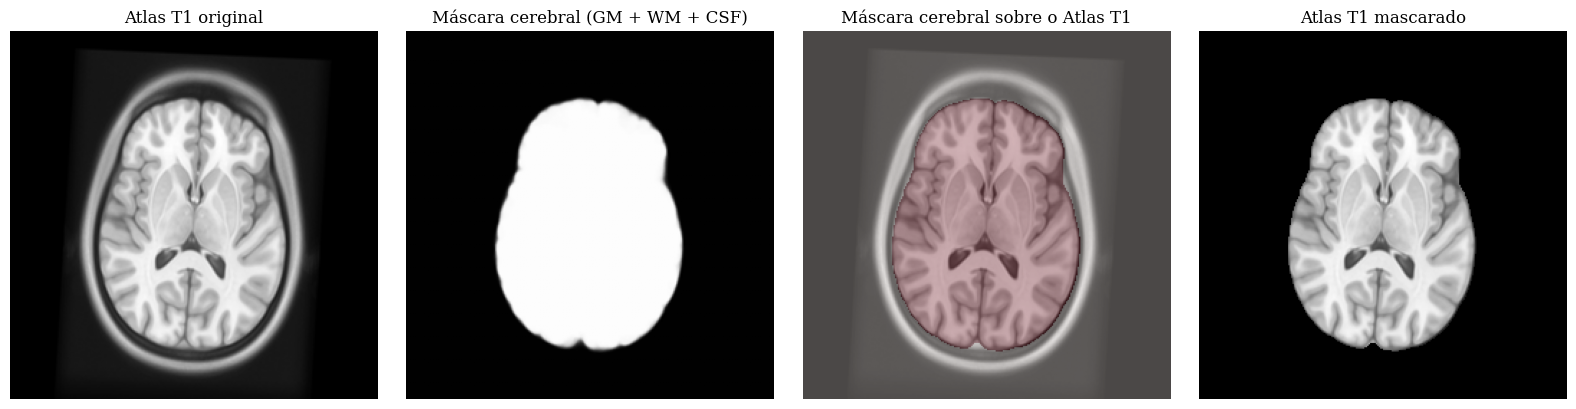

In [ ]:
atlas_t1_array = sitk.GetArrayFromImage(atlas_t1_float)
brain_prob_array = sitk.GetArrayFromImage(brain_prob_img)
brain_mask_array = sitk.GetArrayFromImage(brain_mask_img)
atlas_t1_brain_array = sitk.GetArrayFromImage(atlas_t1_brain_img)

slice_idx = atlas_t1_array.shape[0] // 2

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.title("Atlas T1 original")
plt.imshow(atlas_t1_array[slice_idx], cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Máscara cerebral (GM + WM + CSF)")
plt.imshow(brain_prob_array[slice_idx], cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Máscara cerebral sobre o Atlas T1")
plt.imshow(atlas_t1_array[slice_idx], cmap="gray")
plt.imshow(brain_mask_array[slice_idx], cmap="Reds", alpha=0.3)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Atlas T1 mascarado")
plt.imshow(atlas_t1_brain_array[slice_idx], cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
output_dir = Path("./outputs_registration")
output_dir.mkdir(parents=True, exist_ok=True)

atlas_t1_brain_path = output_dir / "atlas_t1_brain_only.nii.gz"
sitk.WriteImage(atlas_t1_brain_img, str(atlas_t1_brain_path))

print("Atlas T1 mascarado salvo em:", atlas_t1_brain_path)

Atlas T1 mascarado salvo em: outputs_registration/atlas_t1_brain_only.nii.gz


A máscara cerebral remove regiões externas ao cérebro no atlas T1, reduzindo a influência do halo/crânio durante o registro. O atlas T1 mascarado será utilizado como imagem móvel.

### 3.5 Início do registro <a name="inicio-do-registro"></a>

Definição das imagens fixa e móvel

A imagem fixa foi definida como a FLAIR pré-processada pelo filtro Bilateral. O atlas T1 mascarado foi utilizado como imagem móvel. Dessa forma, a transformação estimada levará o atlas e os mapas probabilísticos para o espaço da FLAIR.

In [ ]:

# Definição das imagens fixa e móvel

"""

ESTRUTURAÇÃO DOS ARQUIVOS DE ENTRADA:
O caminho e o objeto da FLAIR assumem a posição de referencial espacial fixo.
O atlas T1, agora livre das estruturas do crânio, assume a posição móvel.

"""

fixed_path = flair_preprocessed_path
moving_path = atlas_t1_brain_path

fixed_img = flair_preprocessed_img
moving_img = atlas_t1_brain_img

flair_array = sitk.GetArrayFromImage(fixed_img)

print("Imagem fixa:", fixed_path)
print("Imagem móvel:", moving_path)

Imagem fixa: outputs_preprocessing/T01C01_flair_bilateral_preprocessed.nii.gz
Imagem móvel: outputs_registration/atlas_t1_brain_only.nii.gz


### 3.6 Execução dos registros globais <a name="registro-rigido"></a>

#### Registro rígido



A **Transformação Rígida** é o primeiro estágio global do processo de alinhamento espacial. Ela funciona como uma aproximação macro, preparando o terreno para os ajustes mais complexos que virão a seguir.

* **Graus de Liberdade (DOF):** O algoritmo trabalha restrito a apenas 6 parâmetros ajustáveis em 3D:
    * **3 Translações:** Deslocamentos para frente/trás, cima/baixo e esquerda/direita.
    * **3 Rotações:** Inclinações e giros nos três eixos do espaço.
* **Preservação de Distâncias:** Por ser "rígida", ela não deforma, não estica, não comprime e não altera o tamanho de nenhuma estrutura anatômica. As distâncias originais dentro do atlas são mantidas intactas.
* **Objetivo Prático:** Corrigir apenas a postura e o posicionamento do paciente dentro do scanner em relação ao atlas. Como o formato do cérebro de cada indivíduo é único, o resultado desse estágio ainda apresentará desalinhamentos visíveis, servindo estritamente como um alinhamento inicial robusto.
* **Inspeção via Checkerboard:** Ao quadricular o resultado tridimensional combinando blocos da imagem do paciente e do atlas rígido, avalia-se visualmente se as macroestruturas (como a orientação geral do crânio e a linha média do cérebro) foram aproximadas corretamente antes de liberar transformações que alterem a forma dos tecidos.


Portanto, o registro rígido foi usado como primeira aproximação global, corrigindo translação e rotação entre o atlas e a FLAIR.

In [ ]:
# Execução do registro RÌGIDO

flair_brain_rigid_result = register_with_elastix(
    fixed_path=fixed_path,
    moving_path=moving_path,
    output_dir="./outputs_registration_flair_brain",
    pipeline="rigid"
)

print("Imagem registrada salva em:", flair_brain_rigid_result["result_path"])

Imagem registrada salva em: outputs_registration_flair_brain/result_rigid.nii.gz


In [ ]:
# Leitura dos registros rígido

"""

RECONSTRUÇÃO E INSPEÇÃO ESPACIAL:

Conforme recomendado no manual do elastix [ref 10, Seção 2.10, Pág. 15] e
requerido no pdf Descrição do trabalho, no AVA, para avaliação
visual, a técnica de Checkerboard quadricula o domínio
físico alternando blocos tridimensionais entre a imagem fixa (FLAIR) e a imagem
móvel transformada (Atlas T1 rígido).

Definiu-se uma subdivisão de [6, 6, 6] blocos nos eixos X, Y e Z.

"""

flair_brain_rigid_registered_img = sitk.ReadImage(str(flair_brain_rigid_result["result_path"]))

clinical_flair_float = sitk.Cast(fixed_img, sitk.sitkFloat32)

checkerboard_flair_rigid_img = sitk.CheckerBoard(
    clinical_flair_float,
    sitk.Cast(flair_brain_rigid_registered_img, sitk.sitkFloat32),
    [6, 6, 6]
)

checkerboard_flair_rigid_array = sitk.GetArrayFromImage(checkerboard_flair_rigid_img)

### 3.7 Registro rígido + afim <a name="registro-rigido-afim"></a>


Após a aproximação macro pelo método rígido, adicionamos uma camada de complexidade ao pipeline inserindo a transformação **Afim** (`AffineTransform`), expandindo a busca para **12 Graus de Liberdade (12 DOF)**. Conforme discutido na Seção 2.6 do manual do `elastix` [ref 10, Pág. 9], a transformação afim engloba não apenas os movimentos de translação e rotação, mas também introduz fatores globais de **escalonamento** (ajuste de escala/tamanho) e **cisalhamento** (deformação angular oblíqua).

Essa etapa é fundamental no mapeamento baseado em atlas. O resultado combinado atua como o alinhamento geométrico global ideal, servindo de base (*baseline*) indispensável antes do início de qualquer ajuste local não-rígido.

---



Após o registro rígido, portanto, avaliamos uma transformação afim, que permite ajustes globais adicionais, como escala e cisalhamento, além de rotação e translação. O resultado foi utilizado como baseline global para comparação com os registros deformáveis.

In [ ]:
#Execução do registro RÌGIDO + AFIM

flair_brain_rigid_affine_result = register_with_elastix(
    fixed_path=fixed_path,
    moving_path=moving_path,
    output_dir="./outputs_registration_flair_brain",
    pipeline="rigid_affine"
)

print("Imagem registrada salva em:", flair_brain_rigid_affine_result["result_path"])

Imagem registrada salva em: outputs_registration_flair_brain/result_rigid_affine.nii.gz


In [ ]:
# Prepara o checkerboard do Rigido

"""

Invoca o motor configurado para rodar sequencialmente o mapa rígido
e o mapa afim, acumulando as matrizes de transformação.

"""

flair_brain_rigid_affine_registered_img = sitk.ReadImage(str(flair_brain_rigid_affine_result["result_path"]))


checkerboard_flair_rigid_affine_img = sitk.CheckerBoard(
    clinical_flair_float,
    sitk.Cast(flair_brain_rigid_affine_registered_img, sitk.sitkFloat32),
    [6, 6, 6]
)

checkerboard_flair_rigid_affine_array = sitk.GetArrayFromImage(checkerboard_flair_rigid_affine_img)

### 3.8 Registro deformável BSpline <a name="registro-deformavel-bspline"></a>


Corrigidas as discrepâncias de tamanho e postura global, o pipeline avança para o domínio não-rígido por meio do modelo **BSpline** (`BSplineTransform`). Conforme detalhado na Seção 2.6 do manual do `elastix` [ref 10, Pág. 9], a transformação deformável não-linear baseia-se na sobreposição de uma grade uniforme de pontos de controle sobre a imagem.

Diferente dos estágios anteriores que moviam o volume como um bloco único, cada nó dessa grade pode se mover de maneira independente no espaço tridimensional, gerando milhares de graus de liberdade locais. Esse alto nível de flexibilidade permite que o algoritmo distorça e ajuste pequenas variações anatômicas intrínsecas entre o atlas e o sujeito clínico, moldando com precisão as estruturas anatômicas do cérebro.

---




Sendo assim, após os registros globais, foi executado um registro deformável BSpline, permitindo avaliar se ajustes locais melhoram o alinhamento entre o atlas e a FLAIR, em comparação com transformações apenas globais.

In [ ]:
# Execução do registro RÍGIDO + AFIM + BSPLINE

flair_brain_rigid_affine_bspline_result = register_with_elastix(
    fixed_path=fixed_path,
    moving_path=moving_path,
    output_dir="./outputs_registration_flair_brain_rigid_affine_bspline",
    pipeline="rigid_affine_bspline"
)

print("Imagem registrada salva em:", flair_brain_rigid_affine_bspline_result["result_path"])

Imagem registrada salva em: outputs_registration_flair_brain_rigid_affine_bspline/result_rigid_affine_bspline.nii.gz


In [ ]:
# Lê resultado RÍGIDO + AFIM + BSPLINE

"""
REGISTRO MULTI-ESTÁGIO COMPLETO:

Executa a transição progressiva recomendada pelo manual do elastix [ref 10, Seção 2.8.2]:
Rígido (ajuste de pose) -> Afim (ajuste de escala) -> BSpline (ajuste local fino).

"""


flair_brain_rigid_affine_bspline_registered_img = sitk.ReadImage(
    str(flair_brain_rigid_affine_bspline_result["result_path"])
)

flair_brain_rigid_affine_bspline_registered_array = sitk.GetArrayFromImage(
    flair_brain_rigid_affine_bspline_registered_img
)

In [ ]:
# Prepara o checkerboard do RÍGIDO + AFIM + BSPLINE

checkerboard_flair_rigid_affine_bspline_img = sitk.CheckerBoard(
    sitk.Cast(fixed_img, sitk.sitkFloat32),
    sitk.Cast(flair_brain_rigid_affine_bspline_registered_img, sitk.sitkFloat32),
    [6, 6, 6]
)

checkerboard_flair_rigid_affine_bspline_array = sitk.GetArrayFromImage(
    checkerboard_flair_rigid_affine_bspline_img
)

### 3.9 Registro deformável com Model Zoo grid 24 <a name="registro-deformavel-com-model-zoo-grid-24"></a>

Também foi testada uma configuração deformável baseada no Elastix Model Zoo, utilizando grid 24. Esse registro foi executado como sequência rígida + afim + BSpline, buscando combinar alinhamento global e ajuste local.

In [ ]:

# Registro deformável Model Zoo - grid 24
# Pipeline: rígido + afim + BSpline Model Zoo


bspline_model_zoo_path = Path("./parameters/parameters_bspline_model_zoo_grid24_interp1.txt")

fixed_image_itk = itk.imread(str(fixed_path), itk.F)
moving_image_itk = itk.imread(str(moving_path), itk.F)

parameter_object = itk.ParameterObject.New()

# Transformação rígida
rigid_parameter_map = parameter_object.GetDefaultParameterMap("rigid")
add_common_elastix_parameters(rigid_parameter_map)
rigid_parameter_map["Metric"] = ["AdvancedMattesMutualInformation"]
parameter_object.AddParameterMap(rigid_parameter_map)

# Transformação afim
affine_parameter_map = parameter_object.GetDefaultParameterMap("affine")
add_common_elastix_parameters(affine_parameter_map)
affine_parameter_map["Metric"] = ["AdvancedMattesMutualInformation"]
parameter_object.AddParameterMap(affine_parameter_map)

# Transformação deformável baseada no Model Zoo
parameter_object.AddParameterFile(str(bspline_model_zoo_path))

result_model_zoo_grid24_img, transform_model_zoo_grid24 = itk.elastix_registration_method(
    fixed_image_itk,
    moving_image_itk,
    parameter_object=parameter_object,
    log_to_console=True
)

model_zoo_grid24_result_path = Path("./outputs_registration_model_zoo_grid24/result_model_zoo_grid24.nii.gz")
model_zoo_grid24_result_path.parent.mkdir(parents=True, exist_ok=True)

itk.imwrite(result_model_zoo_grid24_img, str(model_zoo_grid24_result_path))

print("Registro Model Zoo finalizado.")
print("Resultado salvo em:", model_zoo_grid24_result_path)
print("Número de transformações:", transform_model_zoo_grid24.GetNumberOfParameterMaps())

Registro Model Zoo finalizado.
Resultado salvo em: outputs_registration_model_zoo_grid24/result_model_zoo_grid24.nii.gz
Número de transformações: 3


In [ ]:

# Conversão do resultado Model Zoo para SimpleITK


result_model_zoo_grid24_array = itk.GetArrayFromImage(result_model_zoo_grid24_img)

result_model_zoo_grid24_sitk = sitk.GetImageFromArray(result_model_zoo_grid24_array)
result_model_zoo_grid24_sitk.CopyInformation(fixed_img)

model_zoo_grid24_result_sitk_path = Path(
    "./outputs_registration_model_zoo_grid24/atlas_t1_registered_rigid_affine_bspline_model_zoo_grid24.nii.gz"
)

sitk.WriteImage(result_model_zoo_grid24_sitk, str(model_zoo_grid24_result_sitk_path))

print("Resultado convertido para SimpleITK salvo em:", model_zoo_grid24_result_sitk_path)

Resultado convertido para SimpleITK salvo em: outputs_registration_model_zoo_grid24/atlas_t1_registered_rigid_affine_bspline_model_zoo_grid24.nii.gz


In [ ]:
# Execução do checkerboard MODELZOO

checkerboard_flair_model_zoo_grid24_img = sitk.CheckerBoard(
    sitk.Cast(fixed_img, sitk.sitkFloat32),
    sitk.Cast(result_model_zoo_grid24_sitk, sitk.sitkFloat32),
    [6, 6, 6]
)

checkerboard_flair_model_zoo_grid24_array = sitk.GetArrayFromImage(
    checkerboard_flair_model_zoo_grid24_img
)

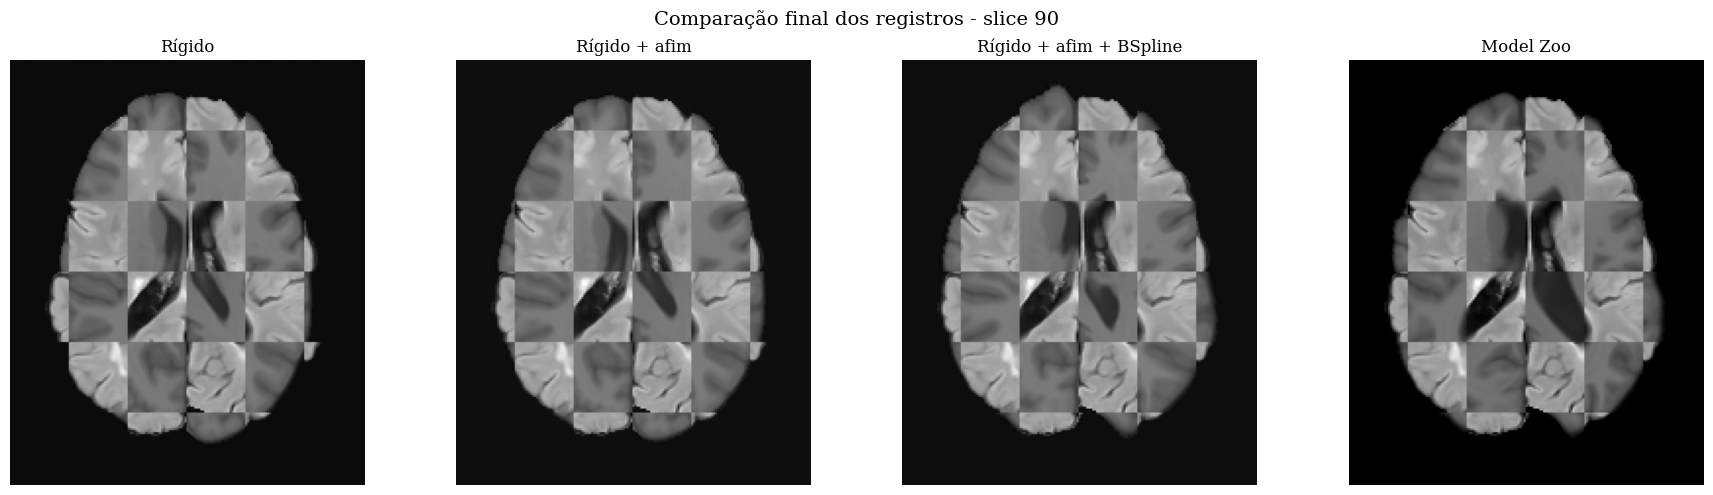

In [ ]:

# Comparação final dos registros principais


slice_idx = checkerboard_flair_rigid_array.shape[0] // 2

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.title("Rígido")
plt.imshow(checkerboard_flair_rigid_array[slice_idx], cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Rígido + afim")
plt.imshow(checkerboard_flair_rigid_affine_array[slice_idx], cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Rígido + afim + BSpline")
plt.imshow(checkerboard_flair_rigid_affine_bspline_array[slice_idx], cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Model Zoo")
plt.imshow(checkerboard_flair_model_zoo_grid24_array[slice_idx], cmap="gray")
plt.axis("off")

plt.suptitle(f"Comparação final dos registros - slice {slice_idx}", fontsize=14)
plt.tight_layout()
plt.show()

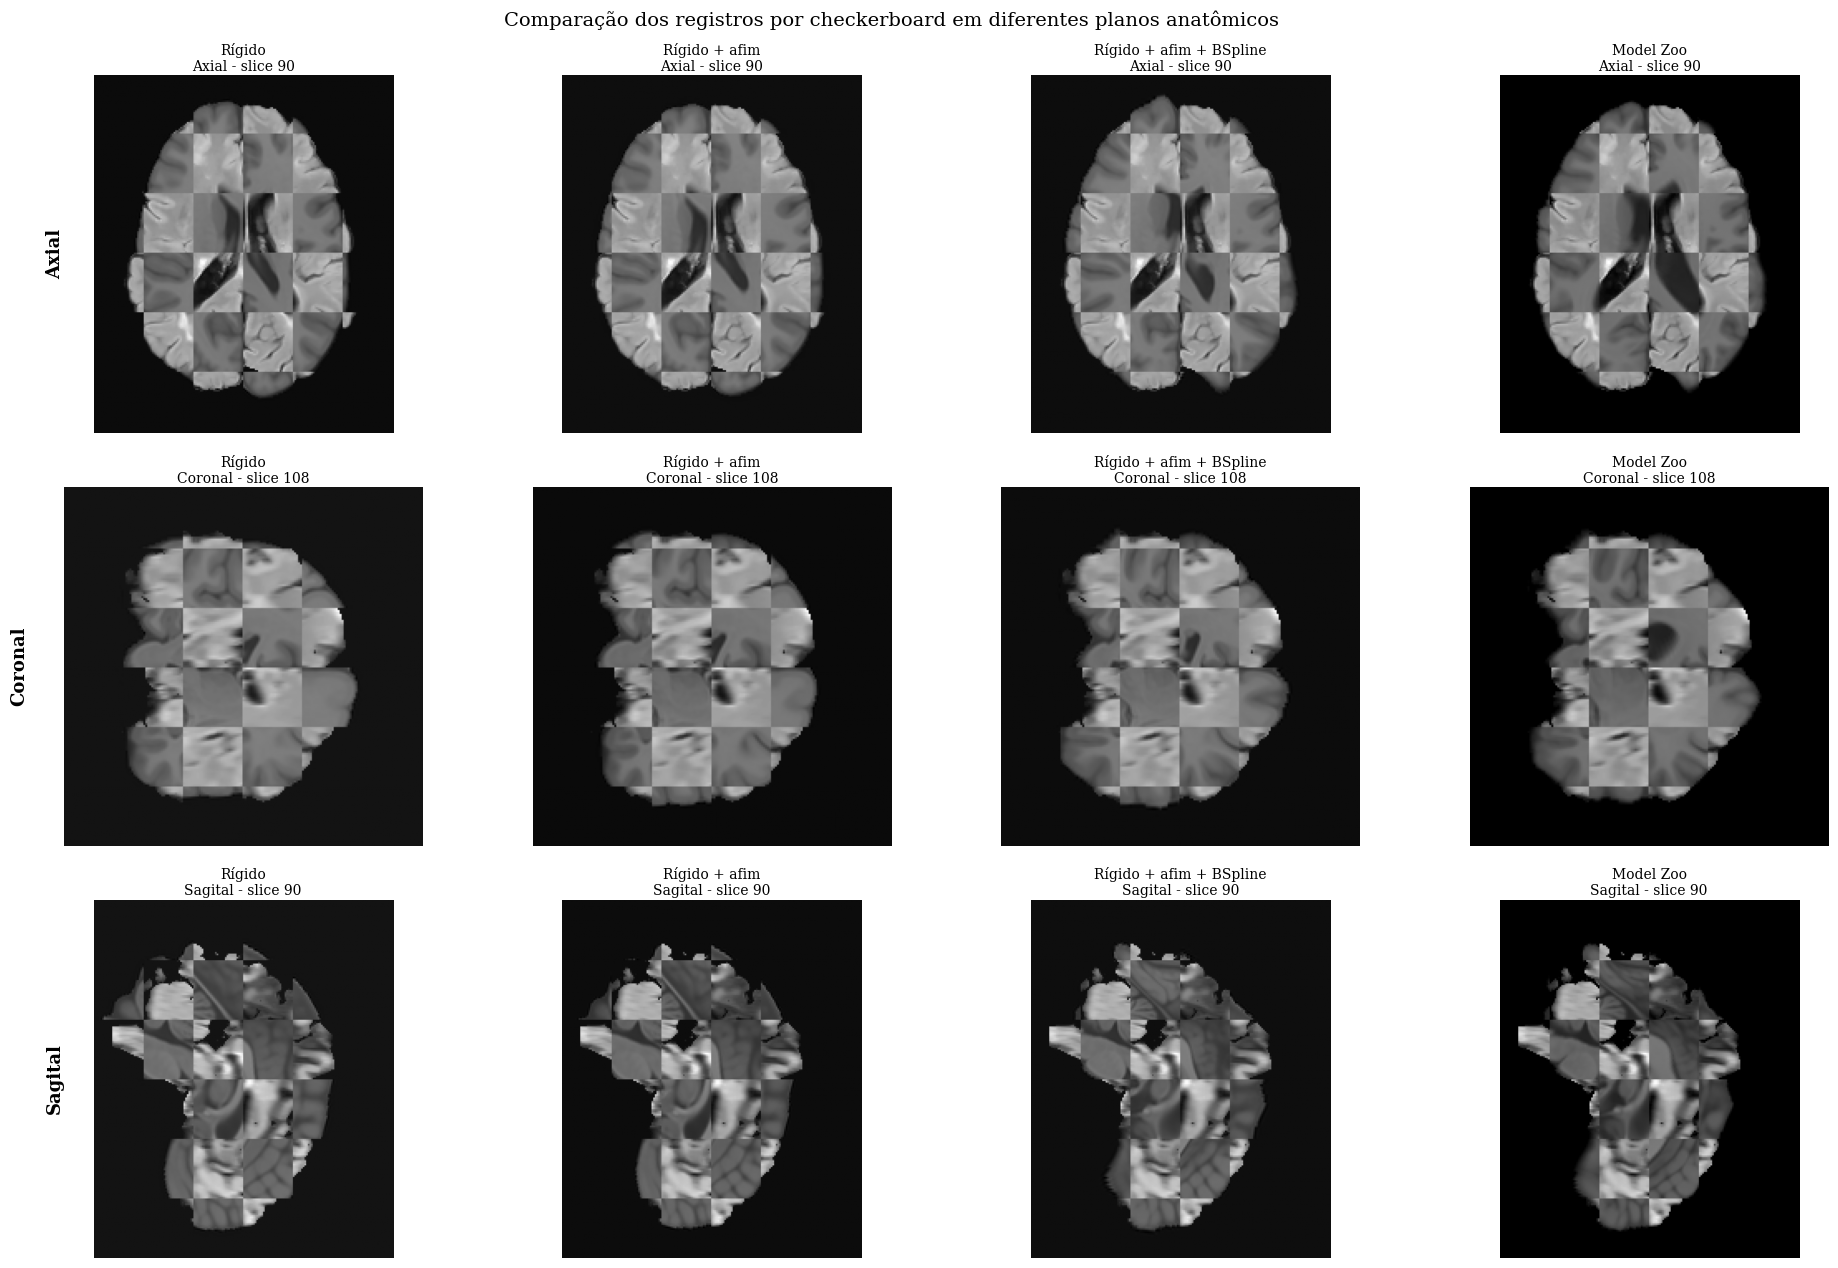

In [ ]:

# Comparação final dos registros em múltiplos planos anatômicos
# Linhas = planos anatômicos
# Colunas = transformações


def get_plane(volume, plane):
    z_dim, y_dim, x_dim = volume.shape

    if plane == "Axial":
        idx = z_dim // 2
        img = volume[idx, :, :]

    elif plane == "Coronal":
        idx = y_dim // 2
        img = np.rot90(volume[:, idx, :])

    elif plane == "Sagital":
        idx = x_dim // 2
        img = np.rot90(volume[:, :, idx])

    else:
        raise ValueError("Plano inválido. Use: Axial, Coronal ou Sagital.")

    return img, idx


checkerboards = {
    "Rígido": checkerboard_flair_rigid_array,
    "Rígido + afim": checkerboard_flair_rigid_affine_array,
    "Rígido + afim + BSpline": checkerboard_flair_rigid_affine_bspline_array,
    "Model Zoo": checkerboard_flair_model_zoo_grid24_array
}

planes = ["Axial", "Coronal", "Sagital"]

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(20, 13)
)

for row_idx, plane_name in enumerate(planes):
    for col_idx, (method_name, checker_array) in enumerate(checkerboards.items()):
        plane_img, idx = get_plane(checker_array, plane_name)

        axes[row_idx, col_idx].imshow(plane_img, cmap="gray")
        axes[row_idx, col_idx].axis("off")

        # Título só com método e slice, mais compacto
        axes[row_idx, col_idx].set_title(
            f"{method_name}\n{plane_name} - slice {idx}",
            fontsize=10,
            pad=3
        )

        # Nome do plano na lateral esquerda da primeira imagem da linha
        if col_idx == 0:
            axes[row_idx, col_idx].text(
                -0.10,
                0.5,
                plane_name,
                transform=axes[row_idx, col_idx].transAxes,
                fontsize=13,
                fontweight="bold",
                va="center",
                ha="right",
                rotation=90
            )

plt.suptitle(
    "Comparação dos registros por checkerboard em diferentes planos anatômicos",
    fontsize=14,
    y=0.98
)

plt.subplots_adjust(
    left=0.06,
    right=0.995,
    top=0.93,
    bottom=0.02,
    wspace=0.01,
    hspace=0.15
)

plt.show()

A comparação por checkerboard mostrou que as transformações rígida e rígida + afim produzem um alinhamento global estável, mas com menor capacidade de ajustar diferenças anatômicas locais. O registro BSpline permite ajustes locais, porém pode ser mais sensível aos parâmetros e introduzir deformações indesejadas.

A configuração Model Zoo grid 24 apresentou o melhor equilíbrio visual entre continuidade anatômica e controle da deformação. Por isso, essa transformação foi escolhida para ser aplicada aos mapas probabilísticos GM, WM e CSF.

### Resumo das transformações avaliadas <a name="resumo-das-transformacoes-avaliadas"></a>

| Transformação | Papel no teste | Observação | Decisão |
|---|---|---|---|
| Rígida | Alinhamento global inicial | Corrige rotação e translação, mas não ajusta escala ou diferenças locais | Mantida apenas como referência |
| Rígida + afim | Alinhamento global mais flexível | Corrige rotação, translação, escala e cisalhamento | Usada como baseline global |
| Rígida + afim + BSpline | Ajuste deformável local | Permite deformações locais, mas é mais sensível aos parâmetros | Mantida para comparação |
| Model Zoo grid 24 | Ajuste global + deformável com parametrização externa | Melhor equilíbrio visual no checkerboard e propagação mais coerente dos tecidos | Escolhida |

### 3.10 Propagação dos mapas probabilísticos GM, WM e CSF <a name="propagacao-dos-mapas-probabilisticos-gm-wm-csf"></a>

Após a escolha do Model Zoo grid 24, a mesma transformação foi aplicada aos mapas probabilísticos do atlas. Assim, GM, WM e CSF passam a estar no espaço da FLAIR clínica.

In [ ]:

# Aplicação da transformação final nos mapas GM, WM e CSF


transform_final = transform_model_zoo_grid24
nome_transformacao_final = "model_zoo_grid24"

output_dir_tissues = Path("./outputs_registration_tissues")
output_dir_tissues.mkdir(parents=True, exist_ok=True)

def apply_transform_to_probability_map(input_path, transform_parameter_object, output_path):
    """
    Aplica a transformação atlas -> FLAIR em um mapa probabilístico.
    A mesma transformação obtida no registro do atlas T1 é propagada
    para os mapas GM, WM e CSF.
    """
    input_image = itk.imread(str(input_path), itk.F)

    transformed_image = itk.transformix_filter(
        input_image,
        transform_parameter_object
    )

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    itk.imwrite(transformed_image, str(output_path))

    return output_path


gm_registered_path = apply_transform_to_probability_map(
    atlas_gm_path,
    transform_final,
    output_dir_tissues / f"gm_registered_to_flair_{nome_transformacao_final}.nii.gz"
)

wm_registered_path = apply_transform_to_probability_map(
    atlas_wm_path,
    transform_final,
    output_dir_tissues / f"wm_registered_to_flair_{nome_transformacao_final}.nii.gz"
)

csf_registered_path = apply_transform_to_probability_map(
    atlas_csf_path,
    transform_final,
    output_dir_tissues / f"csf_registered_to_flair_{nome_transformacao_final}.nii.gz"
)

print("GM registrado salvo em:", gm_registered_path)
print("WM registrado salvo em:", wm_registered_path)
print("CSF registrado salvo em:", csf_registered_path)

GM registrado salvo em: outputs_registration_tissues/gm_registered_to_flair_model_zoo_grid24.nii.gz
WM registrado salvo em: outputs_registration_tissues/wm_registered_to_flair_model_zoo_grid24.nii.gz
CSF registrado salvo em: outputs_registration_tissues/csf_registered_to_flair_model_zoo_grid24.nii.gz


In [ ]:
# Leitura dos mapas transformados


gm_registered_img = sitk.ReadImage(str(gm_registered_path))
wm_registered_img = sitk.ReadImage(str(wm_registered_path))
csf_registered_img = sitk.ReadImage(str(csf_registered_path))

gm_registered_array = sitk.GetArrayFromImage(gm_registered_img)
wm_registered_array = sitk.GetArrayFromImage(wm_registered_img)
csf_registered_array = sitk.GetArrayFromImage(csf_registered_img)

flair_array = sitk.GetArrayFromImage(fixed_img)

print("FLAIR shape:", flair_array.shape)
print("GM registrado shape:", gm_registered_array.shape)
print("WM registrado shape:", wm_registered_array.shape)
print("CSF registrado shape:", csf_registered_array.shape)

FLAIR shape: (181, 217, 181)
GM registrado shape: (181, 217, 181)
WM registrado shape: (181, 217, 181)
CSF registrado shape: (181, 217, 181)


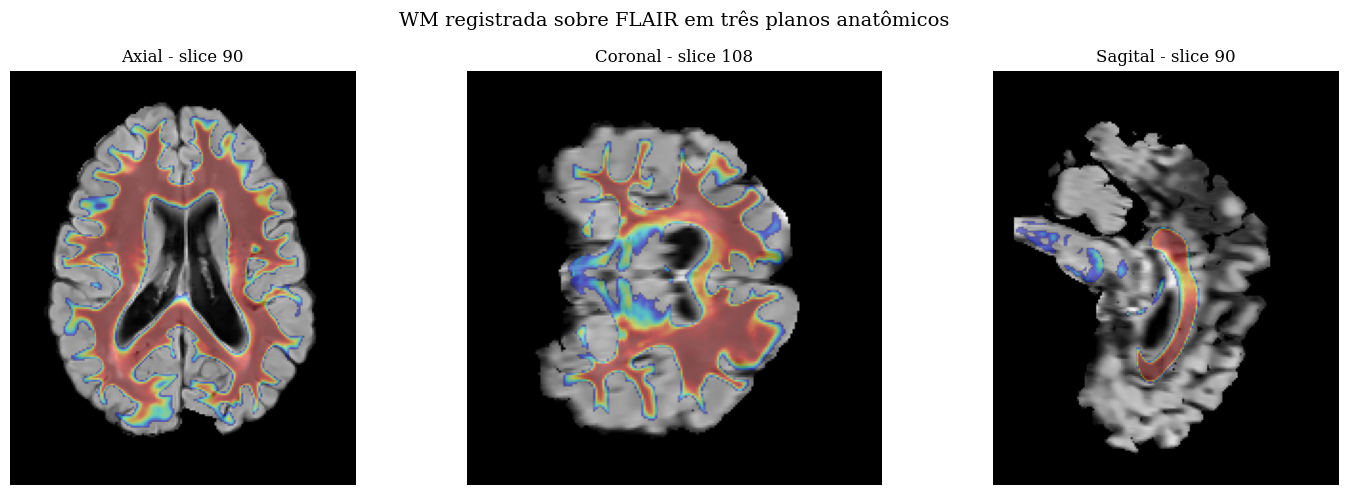

In [ ]:
# WM registrada sobre FLAIR em 3 planos anatômicos


limiar_wm = 0.4

slice_axial = flair_array.shape[0] // 2
slice_coronal = flair_array.shape[1] // 2
slice_sagital = flair_array.shape[2] // 2

plt.figure(figsize=(15, 5))

# Axial
wm_axial = np.ma.masked_where(
    wm_registered_array[slice_axial, :, :] < limiar_wm,
    wm_registered_array[slice_axial, :, :]
)

plt.subplot(1, 3, 1)
plt.imshow(flair_array[slice_axial, :, :], cmap="gray")
plt.imshow(wm_axial, cmap="jet", alpha=0.45, vmin=limiar_wm, vmax=1)
plt.title(f"Axial - slice {slice_axial}")
plt.axis("off")

# Coronal
wm_coronal = np.ma.masked_where(
    wm_registered_array[:, slice_coronal, :] < limiar_wm,
    wm_registered_array[:, slice_coronal, :]
)

plt.subplot(1, 3, 2)
plt.imshow(np.rot90(flair_array[:, slice_coronal, :]), cmap="gray")
plt.imshow(np.rot90(wm_coronal), cmap="jet", alpha=0.45, vmin=limiar_wm, vmax=1)
plt.title(f"Coronal - slice {slice_coronal}")
plt.axis("off")

# Sagital
wm_sagital = np.ma.masked_where(
    wm_registered_array[:, :, slice_sagital] < limiar_wm,
    wm_registered_array[:, :, slice_sagital]
)

plt.subplot(1, 3, 3)
plt.imshow(np.rot90(flair_array[:, :, slice_sagital]), cmap="gray")
plt.imshow(np.rot90(wm_sagital), cmap="jet", alpha=0.45, vmin=limiar_wm, vmax=1)
plt.title(f"Sagital - slice {slice_sagital}")
plt.axis("off")

plt.suptitle("WM registrada sobre FLAIR em três planos anatômicos", fontsize=14)
plt.tight_layout()
plt.show()

### 3.11 Conclusão da Etapa 2 <a name="conclusao-da-etapa-2"></a>

Nesta etapa, o atlas T1 foi registrado no espaço da imagem FLAIR pré-processada. Inicialmente, foi criada uma máscara cerebral a partir dos mapas probabilísticos GM, WM e CSF, reduzindo a influência de regiões externas ao cérebro durante o registro.

Foram avaliadas quatro configurações de registro: rígida, rígida + afim, rígida + afim + BSpline e Model Zoo grid 24. A comparação visual por checkerboard em diferentes planos anatômicos indicou que o Model Zoo grid 24 apresentou o melhor equilíbrio entre alinhamento global, continuidade anatômica e controle da deformação local.

A transformação final foi aplicada aos mapas probabilísticos GM, WM e CSF, alinhando essas informações anatômicas ao espaço da FLAIR clínica. O mapa de WM registrado será utilizado na próxima etapa como região de interesse para restringir a segmentação de possíveis lesões encontradas na substância branca.

## Etapa 3 — Segmentação de possíveis lesões na FLAIR <a name="segmentacao-de-possiveis-lesoes-na-flair"></a>

Nesta etapa, foram aplicadas duas abordagens não supervisionadas para segmentação de regiões candidatas a lesão na imagem FLAIR pré-processada: K-Means e Gaussian Mixture Model (GMM).

Como lesões de Esclerose Múltipla tendem a apresentar sinal hiperintenso em FLAIR e são frequentemente associadas à substância branca, a segmentação foi restringida à máscara de WM registrada na Etapa 2. Dessa forma, os algoritmos analisam apenas as intensidades localizadas dentro de uma região anatomicamente mais plausível.

Inicialmente, as intensidades da FLAIR dentro da WM foram normalizadas. No K-Means, o cluster com maior centroide foi considerado candidato a lesão. No GMM, foi selecionado o componente gaussiano com maior média de intensidade, mantendo apenas voxels com responsabilidade mínima de pertencimento a esse componente.

Após a segmentação, componentes conectados menores que um tamanho mínimo foram removidos para reduzir regiões pequenas e isoladas. Os resultados foram quantificados volumetricamente e comparados com as máscaras de referência.

In [ ]:
# Preparação dos dados para segmentação


# Garantir que estamos usando arrays NumPy
flair_seg_array = np.asarray(flair_array, dtype=np.float32)
wm_prob_array = np.asarray(wm_registered_array, dtype=np.float32)

print("Shape FLAIR:", flair_seg_array.shape)
print("Shape WM registrada:", wm_prob_array.shape)

# Verificação básica
assert flair_seg_array.shape == wm_prob_array.shape, "FLAIR e WM precisam ter o mesmo shape."

Shape FLAIR: (181, 217, 181)
Shape WM registrada: (181, 217, 181)


Foi utilizado o limiar `WM > 0.4` para transformar o mapa probabilístico de substância branca em uma máscara binária.

Esse limiar define a região em que os algoritmos poderão procurar possíveis lesões. Um valor muito baixo tornaria a máscara mais permissiva, incluindo voxels com pouca probabilidade de pertencer à WM e aumentando o risco de falsos positivos. Por outro lado, um valor muito alto poderia excluir regiões relevantes de substância branca.

O valor `0.4` foi mantido como uma escolha intermediária, buscando preservar regiões relevantes sem ampliar excessivamente a área de busca. Esse parâmetro não classifica diretamente as lesões, apenas restringe espacialmente a segmentação.

In [ ]:
# Máscara de substância branca

wm_threshold = 0.4
wm_mask = wm_prob_array > wm_threshold

print("Threshold WM:", wm_threshold)
print("Voxels dentro da WM:", np.sum(wm_mask))

print("Porcentagem da imagem classificada como WM:", 100 * np.sum(wm_mask) / wm_mask.size, "%")

Threshold WM: 0.4
Voxels dentro da WM: 554129
Porcentagem da imagem classificada como WM: 7.794602917344257 %


As intensidades da FLAIR foram normalizadas usando percentis robustos para reduzir a influência de valores extremos antes da aplicação do K-Means.

In [ ]:
# Normalização das intensidades da FLAIR dentro da WM

flair_values_wm = flair_seg_array[wm_mask]

# Remover valores extremos muito baixos/altos para estabilizar a análise
p1 = np.percentile(flair_values_wm, 1)
p99 = np.percentile(flair_values_wm, 99)

flair_clipped = np.clip(flair_seg_array, p1, p99)

# Normalização 0-1 usando apenas a faixa robusta
flair_norm = (flair_clipped - p1) / (p99 - p1 + 1e-8)

flair_values_wm_norm = flair_norm[wm_mask].reshape(-1, 1)

print("Percentil 1:", p1)
print("Percentil 99:", p99)
print("Valores usados no K-Means:", flair_values_wm_norm.shape)

Percentil 1: 62.03411
Percentil 99: 144.95535
Valores usados no K-Means: (554129, 1)


### 4.1 Pós-processamento por componentes conectados <a name="pos-processamento-por-componentes-conectados"></a>

Os métodos de segmentação podem gerar pequenos grupos de voxels isolados, associados a ruído ou a regiões hiperintensas pouco consistentes.

Para reduzir esses componentes, foi utilizada uma análise de componentes conectados em três dimensões. Cada região espacialmente conectada recebe um identificador, permitindo calcular sua quantidade de voxels.

Foram mantidos apenas componentes com pelo menos 60 voxels. Esse valor foi escolhido durante os testes de sensibilidade por apresentar melhor equilíbrio entre remoção de ruídos e preservação de regiões lesionais. O tamanho mínimo não deve ser interpretado como uma regra clínica universal, mas como um parâmetro de pós-processamento para o volume analisado.

In [ ]:
# Função para remover componentes conectados pequenos

from scipy import ndimage

def remover_componentes_pequenos(mask, min_size=30):
    mask = mask.astype(bool)

    labeled_components, num_components = ndimage.label(mask)
    component_sizes = np.bincount(labeled_components.ravel())

    clean_mask = np.zeros_like(mask, dtype=bool)

    for component_id, size in enumerate(component_sizes):
        if component_id == 0:
            continue

        if size >= min_size:
            clean_mask[labeled_components == component_id] = True

    componentes_mantidos = np.sum(component_sizes[1:] >= min_size)

    return clean_mask, num_components, int(componentes_mantidos)

### 4.2 Segmentação por K-Means <a name="lesoes-identificadas-via-k-medias"></a>

O K-Means agrupa os voxels com base na proximidade entre suas intensidades e os centroides dos clusters. Como a entrada utilizada possui apenas a intensidade normalizada da FLAIR, cada cluster representa uma faixa de intensidade dentro da substância branca.

Foram utilizados `K=6` clusters. Após a convergência, o cluster com maior centroide foi interpretado como o conjunto de voxels mais hiperintensos e, portanto, como candidato a conter possíveis lesões.

O valor `K=6` foi selecionado após testes com diferentes números de clusters. Valores menores produziram grupos muito amplos e grande quantidade de falsos positivos. Valores maiores tornaram a segmentação mais restritiva, aumentando a precisão, mas reduzindo a recuperação das regiões presentes no ground truth.

In [ ]:
# ============================================================
# Configuração final do K-Means
# ============================================================

k = 6
min_size_final = 60

kmeans_final_model = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels_kmeans_final = kmeans_final_model.fit_predict(
    flair_values_wm_norm
)

centros_kmeans_final = (
    kmeans_final_model.cluster_centers_.flatten()
)

cluster_lesao_final = np.argmax(centros_kmeans_final)

lesion_mask_kmeans_final = np.zeros_like(
    flair_seg_array,
    dtype=bool
)

lesion_mask_kmeans_final[wm_mask] = (
    labels_kmeans_final == cluster_lesao_final
)

clean_lesion_mask, _, _ = remover_componentes_pequenos(
    lesion_mask_kmeans_final,
    min_size=min_size_final
)

print("Configuração final do K-Means")
print("K utilizado:",k)
print("Tamanho mínimo:",min_size_final)
print("Centros:", centros_kmeans_final)
print("Cluster selecionado:", cluster_lesao_final)
print("Voxels antes da limpeza:", np.sum(lesion_mask_kmeans_final))
print("Voxels depois da limpeza:", np.sum(clean_lesion_mask))

Configuração final do K-Means
K utilizado: 6
Tamanho mínimo: 60
Centros: [0.61065036 0.09586415 0.9043064  0.3986131  0.72338    0.519211  ]
Cluster selecionado: 2
Voxels antes da limpeza: 27996
Voxels depois da limpeza: 22462


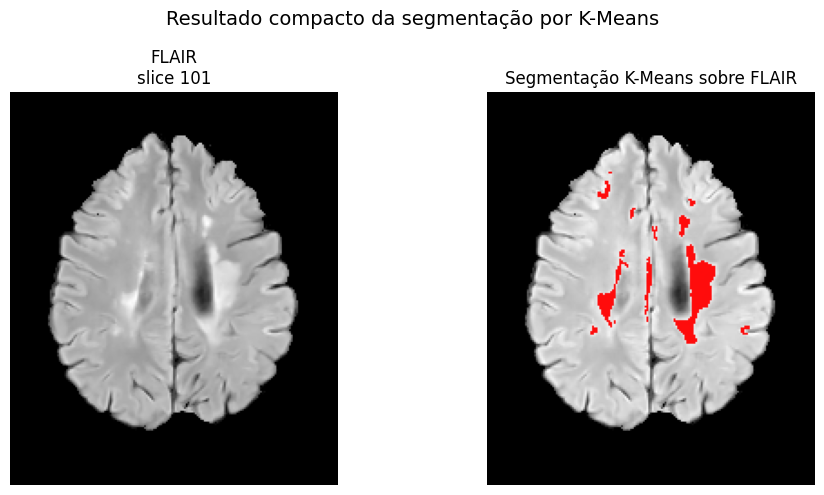

In [ ]:
# Visualização da segmentação por K-Means


slice_kmeans = np.argmax(np.sum(clean_lesion_mask, axis=(1, 2)))

def normalizar_imagem(img):
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, [1, 99])
    img_norm = np.clip((img - p1) / (p99 - p1), 0, 1)
    return img_norm

def criar_overlay_vibrante(flair_slice, mask_slice, cor=(1, 0, 0), alpha=0.9):
    flair_norm = normalizar_imagem(flair_slice)

    rgb = np.zeros((flair_norm.shape[0], flair_norm.shape[1], 3), dtype=np.float32)
    rgb[:, :, 0] = flair_norm
    rgb[:, :, 1] = flair_norm
    rgb[:, :, 2] = flair_norm

    mask_bool = mask_slice > 0

    rgb[mask_bool, 0] = (1 - alpha) * rgb[mask_bool, 0] + alpha * cor[0]
    rgb[mask_bool, 1] = (1 - alpha) * rgb[mask_bool, 1] + alpha * cor[1]
    rgb[mask_bool, 2] = (1 - alpha) * rgb[mask_bool, 2] + alpha * cor[2]

    return np.clip(rgb, 0, 1)

overlay_kmeans = criar_overlay_vibrante(
    flair_seg_array[slice_kmeans],
    clean_lesion_mask[slice_kmeans],
    cor=(1, 0, 0),   # vermelho puro
    alpha=0.95
)



plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(flair_seg_array[slice_kmeans], cmap="gray")
plt.title(f"FLAIR\nslice {slice_kmeans}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay_kmeans)
plt.title("Segmentação K-Means sobre FLAIR")
plt.axis("off")

plt.suptitle("Resultado compacto da segmentação por K-Means", fontsize=14)
plt.tight_layout()


plt.show()

#### Visualização teórica do K-Means <a name="visualizacao-teorica-do-k-means"></a>

O gráfico a seguir apresenta a distribuição das intensidades normalizadas da FLAIR dentro da WM, separada conforme os clusters atribuídos pelo K-Means.

As linhas verticais tracejadas representam os centroides obtidos após a convergência do algoritmo. O centroide de maior intensidade é destacado como o cluster candidato a lesão.

Essa visualização permite observar como o aumento de `K` divide a distribuição de intensidades em grupos mais específicos e como o cluster hiperintenso é separado dos demais.

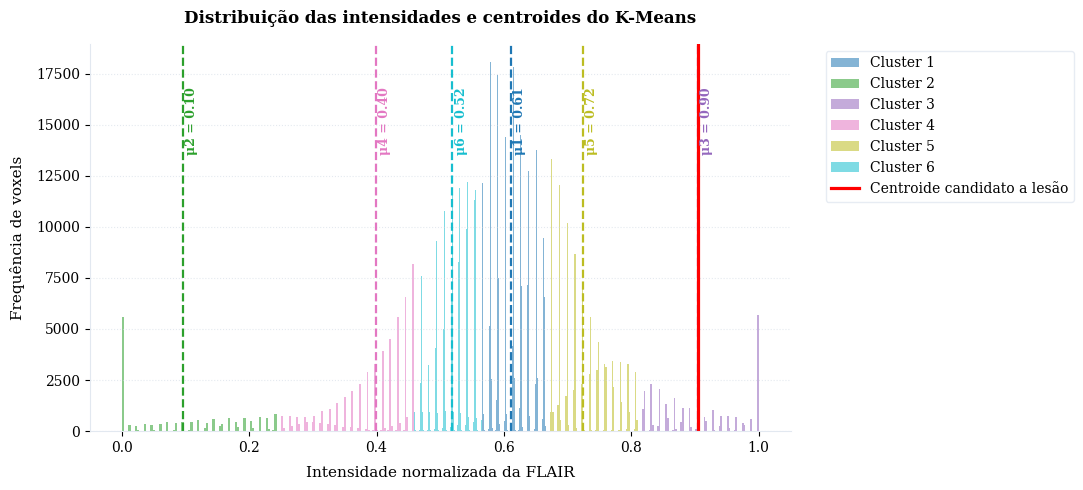

In [ ]:
# Visualização Teórica do K-Means (Intensidades e Centroides)


plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


fig, ax = plt.subplots(figsize=(11, 5))


# Cores dos grupos de voxels (diferente para cada cluster)
colors = plt.cm.tab10(np.linspace(0, 1, k))


# Contando a quantidade de voxels que pertencem a cada cluster do processo de
# processo Atribuição (E), [ref 2; 4, slide Bishop]


"""
Obs.: Como escolhemos 6 clusters, k = 6, cluster_idx vai de 0 a 5.
O array de centroides mostra a intensidade média de cada grupo.
O cluster localizado em cluster_lesao_final corresponde ao centroide de maior intensidade.
"""


for cluster_idx in range(k):


    # Selecionando apenas os voxels mapeados com a respectiva classe.
    # i.e., a partir de intensidades dos voxels, há a comparação
    # labels_kmeans_final == cluster_idx que verifica se o voxel de intensidade
    # I_k pertence àquele cluster_idx analisado. A comparação gera uma máscara
    # booleana, e cluster_pixels guardará os valores numéricos de intensidade
    # respectivos àquele cluster.

    cluster_pixels = flair_values_wm_norm[
        labels_kmeans_final == cluster_idx
    ].ravel()

    # Gera o histograma que mapeia a densidade de frequência e as decisões resultantes do Passo E.
    ax.hist(
        cluster_pixels,
        bins=70,
        alpha=0.55,
        color=colors[cluster_idx],
        label=f'Cluster {cluster_idx + 1}',
        histtype='stepfilled',
        edgecolor='none'
    )


# Após mapeamento inicial, este 'for' servirá para construirmos as linhas verticais
# que mostram onde cada centróide \mu_k está localizado, por meio de um tracejado
# vertical, para que consigamos visualizar onde aconteceu o ponto de convergência
# dos passos E-M, após o passo M (Atualização), em [ref 2; 4, Bishop].


altura_maxima = ax.get_ylim()[1]

for idx, center in enumerate(centros_kmeans_final):

    # Projeta uma linha ortogonal sobre o eixo X no ponto exato que minimiza a soma dos quadrados das distâncias locais.
    ax.axvline(
        center,
        color=colors[idx],
        linestyle='--',
        linewidth=1.6
    )

    # Insere a representação escalar do centroide médio (\mu_k) calculado matematicamente no Passo M.
    ax.text(
        center + 0.004,
        altura_maxima * 0.72,
        f'μ{idx + 1} = {center:.2f}',
        rotation=90,
        fontsize=9,
        fontweight='bold',
        color=colors[idx],
        family='serif'
    )


# Projeta o vetor do centroide hiperintenso isolado via operador argmax, correspondente à assinatura da patologia.
ax.axvline(
    centros_kmeans_final[cluster_lesao_final],
    color='red',
    linestyle='-',
    linewidth=2.3,
    label='Centroide candidato a lesão'
)


# Mexendo na estrutura gráfica da plotagem
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.set_title(
    "Distribuição das intensidades e centroides do K-Means",
    fontsize=12,
    fontweight='bold',
    pad=15
)

# Define o domínio do eixo X de Intensidades
ax.set_xlabel(
    "Intensidade normalizada da FLAIR",
    fontsize=11,
    labelpad=8
)

# Define o domínio do eixo Y de Voxels
ax.set_ylabel(
    "Frequência de voxels",
    fontsize=11,
    labelpad=8
)

# Posiciona a legenda dos metadados e classes de tecido fora do domínio do histograma para evitar sobreposição.
ax.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    frameon=True,
    facecolor='white',
    edgecolor='#E2E8F0'
)

ax.grid(
    axis='y',
    linestyle=':',
    alpha=0.5,
    color='#CBD5E0'
)

# Ajusta as delimitações da janela
plt.tight_layout()

# Exibição
plt.show()

In [ ]:
# Quantificação da carga lesional estimada

spacing = fixed_img.GetSpacing()
voxel_vol = spacing[0] * spacing[1] * spacing[2]

num_voxels_lesion = np.sum(clean_lesion_mask)
num_voxels_wm = np.sum(wm_mask)

volume_lesion_mm3 = num_voxels_lesion * voxel_vol
volume_wm_mm3 = num_voxels_wm * voxel_vol

lesion_percentage_wm = (volume_lesion_mm3 / volume_wm_mm3) * 100

print(f"Volume do voxel: {voxel_vol:.4f} mm³") # ACHO QUE É TAMANHO
print(f"Voxels segmentados como possíveis lesões: {num_voxels_lesion}")
print(f"Carga lesional estimada: {volume_lesion_mm3:.2f} mm³")
print(f"Volume da WM considerada: {volume_wm_mm3:.2f} mm³")
print(f"Porcentagem da WM marcada como possível lesão: {lesion_percentage_wm:.4f}%")

Volume do voxel: 1.0000 mm³
Voxels segmentados como possíveis lesões: 22462
Carga lesional estimada: 22462.00 mm³
Volume da WM considerada: 554129.00 mm³
Porcentagem da WM marcada como possível lesão: 4.0536%


In [ ]:
# Salvamento da máscara de possíveis lesões kmeans

output_dir_segmentation = Path("./outputs_segmentation")
output_dir_segmentation.mkdir(parents=True, exist_ok=True)

lesion_mask_img = sitk.GetImageFromArray(clean_lesion_mask.astype(np.uint8))
lesion_mask_img.CopyInformation(fixed_img)

lesion_mask_path = (output_dir_segmentation /"lesion_mask_kmeans_k6_min60.nii.gz")

sitk.WriteImage(lesion_mask_img, str(lesion_mask_path))

print("Máscara de possíveis lesões salva em:", lesion_mask_path)

Máscara de possíveis lesões salva em: outputs_segmentation/lesion_mask_kmeans_p98_min30.nii.gz


### 4.3 Análise do resultado do K-Means <a name="analise-do-resultado-da-segmentacao"></a>

A configuração final do K-Means utilizou `K=6`, `n_init=10`, `random_state=42` e remoção de componentes menores que 60 voxels.

O uso de seis clusters permitiu separar a distribuição de intensidades da FLAIR em grupos mais específicos do que as configurações iniciais com poucos clusters. O cluster de maior centroide foi interpretado como candidato a lesão por representar os voxels mais hiperintensos dentro da WM.

Apesar da melhora obtida com o aumento de `K`, o método ainda pode incluir regiões hiperintensas que não correspondem ao ground truth. Isso ocorre porque o K-Means utiliza apenas a intensidade e realiza uma atribuição rígida: cada voxel pertence completamente a apenas um cluster.

Assim, a máscara gerada deve ser interpretada como uma segmentação preliminar de regiões candidatas a lesão, e não como uma identificação clínica definitiva.

### 4.4 Segmentação por Gaussian Mixture Model <a name="lesoes-identificadas-via-gaussian-mixture-model"></a>

Como segunda abordagem, foi utilizado o Gaussian Mixture Model (GMM). Diferentemente do K-Means, que atribui rigidamente cada voxel a um único cluster, o GMM representa a distribuição das intensidades como uma combinação de distribuições gaussianas.

Foram utilizados cinco componentes gaussianos. O componente com maior média foi interpretado como candidato a representar as regiões mais hiperintensas da FLAIR.

Para evitar que todos os voxels atribuídos ao componente hiperintenso fossem automaticamente classificados como possíveis lesões, foi utilizada uma responsabilidade mínima de `0.70`. Dessa forma, um voxel somente é incluído na máscara quando o modelo atribui a ele responsabilidade de pelo menos 70% para o componente mais hiperintenso.

Essa responsabilidade representa confiança de pertencimento ao componente estatístico, e não uma probabilidade clínica de o voxel ser uma lesão.

In [ ]:
from sklearn.mixture import GaussianMixture

# Segmentação por GMM dentro da WM

n_components = 5
probability_threshold = 0.70

gmm = GaussianMixture(
    n_components=n_components,
    covariance_type="full",
    init_params="kmeans",
    n_init=5,
    random_state=42
)

# Treinamento do modelo
gmm.fit(flair_values_wm_norm)

gmm_means = gmm.means_.flatten()

# O componente com maior média representa as maiores intensidades
lesion_component = np.argmax(gmm_means)

# Probabilidade de cada voxel pertencer a cada componente
responsibilities_gmm = gmm.predict_proba(
    flair_values_wm_norm
)

# Probabilidade de pertencer ao componente mais hiperintenso
lesion_probability_gmm = (
    responsibilities_gmm[:, lesion_component]
)

lesion_mask_gmm = np.zeros_like(
    flair_seg_array,
    dtype=bool
)

lesion_mask_gmm[wm_mask] = (
    lesion_probability_gmm >= probability_threshold
)

print("Médias do GMM:", gmm_means)
print("Componente mais hiperintenso:", lesion_component)
print("Probabilidade mínima:", probability_threshold)
print(
    "Voxels candidatos antes da limpeza:",
    np.sum(lesion_mask_gmm)
)

Médias do GMM: [0.69576437 0.57994648 0.17600603 0.47325239 0.87665318]
Componente mais hiperintenso: 4
Probabilidade mínima: 0.7
Voxels candidatos antes da limpeza: 24513


O GMM foi inicializado utilizando K-Means por meio do parâmetro `init_params="kmeans"`. Essa inicialização fornece uma estimativa inicial das médias e da organização dos componentes gaussianos.

Em seguida, os parâmetros do modelo foram ajustados pelo algoritmo Expectation-Maximization (EM). Na etapa de expectativa, o modelo calcula a responsabilidade de cada componente por cada voxel. Na etapa de maximização, são atualizados os pesos, as médias e as covariâncias das distribuições gaussianas.

Foram utilizadas cinco inicializações (`n_init=5`), e o resultado foi mantido reprodutível por meio de `random_state=42`.

In [ ]:
# ============================================================
# Pós-processamento do GMM
# ============================================================

min_size_gmm = 60

clean_lesion_mask_gmm, componentes_encontrados_gmm, componentes_mantidos_gmm = (
    remover_componentes_pequenos(
        lesion_mask_gmm,
        min_size=min_size_gmm
    )
)

print("Componentes encontrados:", componentes_encontrados_gmm)
print("Componentes mantidos:", componentes_mantidos_gmm)
print("Tamanho mínimo:", min_size_gmm)
print("Voxels antes da limpeza:", np.sum(lesion_mask_gmm))
print("Voxels depois da limpeza:", np.sum(clean_lesion_mask_gmm))

Componentes encontrados: 958
Componentes mantidos: 40
Tamanho mínimo: 60
Voxels antes da limpeza: 24513
Voxels depois da limpeza: 19535


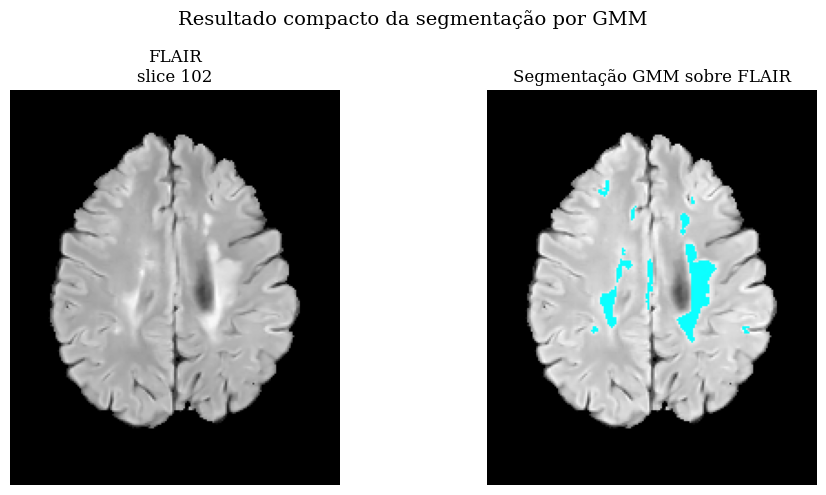

In [ ]:
# Visualização compacta da segmentação por GMM

slice_gmm = int(
    np.argmax(np.sum(clean_lesion_mask_gmm, axis=(1, 2)))
)

overlay_gmm = criar_overlay_vibrante(
    flair_seg_array[slice_gmm],
    clean_lesion_mask_gmm[slice_gmm],
    cor=(0, 1, 1),   # ciano forte
    alpha=0.95
)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(flair_seg_array[slice_gmm], cmap="gray")
plt.title(f"FLAIR\nslice {slice_gmm}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlay_gmm)
plt.title("Segmentação GMM sobre FLAIR")
plt.axis("off")

plt.suptitle("Resultado compacto da segmentação por GMM", fontsize=14)
plt.tight_layout()
plt.show()

#### Visualização teórica do GMM <a name="visualizacao-teorica-do-gmm"></a>

O gráfico apresenta o histograma das intensidades normalizadas da FLAIR dentro da WM e as distribuições gaussianas estimadas pelo GMM.

Cada curva tracejada representa um componente gaussiano ponderado pelo seu peso de mistura. A curva contínua corresponde à soma de todos os componentes e representa a densidade de probabilidade global estimada pelo modelo.

A média do componente mais hiperintenso é destacada no gráfico. Esse componente foi utilizado como referência para obter as responsabilidades dos voxels candidatos a lesão.

invalid escape sequence '\p'
invalid escape sequence '\p'
invalid escape sequence '\p'


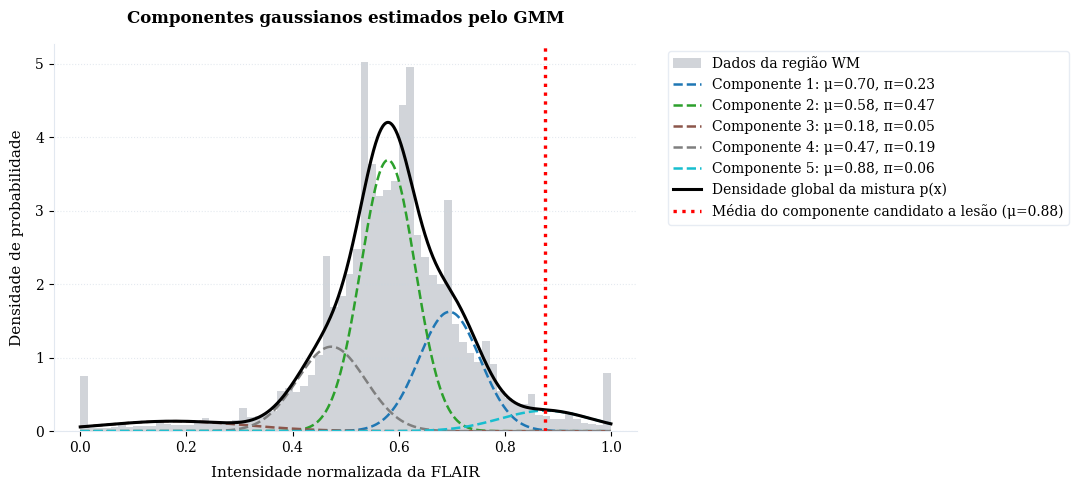

In [ ]:
# Visualização Teórica do GMM (Componentes e Mistura Global)

from scipy import stats

plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

fig, ax = plt.subplots(figsize=(11, 5))

# Espaço contínuo de intensidades para projeção das curvas analíticas
x_axis = np.linspace(0, 1, 1000)
pdf_global = np.zeros_like(x_axis)

"""
O histograma a seguir mapeia os dados observados da substância branca de forma unificada.
Diferente do K-Means, o GMM não impõe um particionamento rígido (hard assignment) sobre os
dados brutos. O parâmetro 'density=True' é matematicamente indispensável para normalizar
a área do histograma em 1, integrando perfeitamente a distribuição empírica com as funções
analíticas de densidade de probabilidade (PDFs) estimadas pelo framework estatístico.
"""
ax.hist(
    flair_values_wm_norm.ravel(),
    bins=70,
    alpha=0.25,
    color='#4A5568',
    label='Dados da região WM',
    density=True,
    histtype='stepfilled',
    edgecolor='none'
)

# Cores geradas de acordo com a quantidade atual de componentes
colors = plt.cm.tab10(np.linspace(0, 1, n_components))

gmm_weights = gmm.weights_
gmm_covariances = gmm.covariances_.reshape(n_components, -1)[:, 0]

"""

Este laço percorre as subpopulações (componentes) do modelo.
Em cada iteração, projetamos a densidade de probabilidade analítica de uma Gaussiana
ponderada pelo seu respectivo coeficiente de mistura (\pi_k), obtido após a convergência
do algoritmo Expectation-Maximization (EM). Isso ilustra como o modelo assume que um único
voxel é governado por uma combinação linear de distribuições contínuas, capturando a incerteza
e a sobreposição teórica das assinaturas dos tecidos [ref. 2; 4, Bishop].

"""
for idx in range(n_components):

    desvio_padrao = np.sqrt(gmm_covariances[idx])

    pdf_individual = (
        gmm_weights[idx]
        * stats.norm.pdf(
            x_axis,
            loc=gmm_means[idx],
            scale=desvio_padrao
        )
    )

    pdf_global += pdf_individual

    # \pi_k * N(x)
    ax.plot(
        x_axis,
        pdf_individual,
        color=colors[idx],
        linestyle='--',
        linewidth=1.8,
        label=(
            f'Componente {idx + 1}: '
            f'μ={gmm_means[idx]:.2f}, '
            f'π={gmm_weights[idx]:.2f}'
        )
    )


# Projeta a Função Densidade de Probabilidade (PDF) Global da Mistura, dada por p(x).
# Esta curva contínua representa a soma geométrica e estatística de todos os componentes de
# mistura ativos. Ela modela matematicamente o contorno real do histograma, consolidando
# o processo de modelagem probabilística discutido em [ref 2, slide Bishop]

ax.plot(
    x_axis,
    pdf_global,
    color='black',
    linestyle='-',
    linewidth=2.2,
    label='Densidade global da mistura p(x)'
)


# Isola explicitamente a média paramétrica (\mu) da Gaussiana com maior deslocamento
# no eixo de características. Este ponto representa o valor esperado da intensidade
# de sinal para a subpopulação hiperintensa, estabelecendo o ancoramento estatístico
# da assinatura da lesão na sequência FLAIR.

ax.axvline(
    gmm_means[lesion_component],
    color='red',
    linestyle=':',
    linewidth=2.4,
    label=(
        'Média do componente candidato a lesão '
        f'(μ={gmm_means[lesion_component]:.2f})'
    )
)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#E2E8F0')
ax.spines['bottom'].set_color('#E2E8F0')

ax.set_title(
    "Componentes gaussianos estimados pelo GMM",
    fontsize=12,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    "Intensidade normalizada da FLAIR",
    fontsize=11,
    labelpad=8
)

ax.set_ylabel(
    "Densidade de probabilidade",
    fontsize=11,
    labelpad=8
)

# Legenda externa
ax.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    frameon=True,
    facecolor='white',
    edgecolor='#E2E8F0'
)

ax.grid(
    axis='y',
    linestyle=':',
    alpha=0.5,
    color='#CBD5E0'
)

plt.tight_layout()
plt.show()

In [ ]:
# Quantificação da carga lesional estimada pelo GMM

spacing = fixed_img.GetSpacing()
voxel_vol = spacing[0] * spacing[1] * spacing[2]

num_voxels_lesion_gmm = np.sum(clean_lesion_mask_gmm)
num_voxels_wm = np.sum(wm_mask)

volume_lesion_gmm_mm3 = num_voxels_lesion_gmm * voxel_vol
volume_wm_mm3 = num_voxels_wm * voxel_vol

lesion_percentage_wm_gmm = (volume_lesion_gmm_mm3 / volume_wm_mm3) * 100

print(f"Volume do voxel: {voxel_vol:.4f} mm³")
print(f"Voxels segmentados como possíveis lesões pelo GMM: {num_voxels_lesion_gmm}")
print(f"Carga lesional estimada pelo GMM: {volume_lesion_gmm_mm3:.2f} mm³")
print(f"Volume da WM considerada: {volume_wm_mm3:.2f} mm³")
print(f"Porcentagem da WM marcada pelo GMM: {lesion_percentage_wm_gmm:.4f}%")

Volume do voxel: 1.0000 mm³
Voxels segmentados como possíveis lesões pelo GMM: 19535
Carga lesional estimada pelo GMM: 19535.00 mm³
Volume da WM considerada: 554129.00 mm³
Porcentagem da WM marcada pelo GMM: 3.5254%


In [ ]:
# Salvamento da máscara GMM

output_dir_segmentation = Path("./outputs_segmentation")
output_dir_segmentation.mkdir(parents=True, exist_ok=True)

lesion_mask_gmm_img = sitk.GetImageFromArray(clean_lesion_mask_gmm.astype(np.uint8))
lesion_mask_gmm_img.CopyInformation(fixed_img)

lesion_mask_gmm_path = (output_dir_segmentation /"lesion_mask_gmm_c5_resp70_min60.nii.gz")

sitk.WriteImage(lesion_mask_gmm_img, str(lesion_mask_gmm_path))

print("Máscara GMM salva em:", lesion_mask_gmm_path)

Máscara GMM salva em: outputs_segmentation/lesion_mask_gmm_p98_min30.nii.gz


### 4.5 Análise do resultado do GMM <a name="analise-do-resultado-do-gmm"></a>

A configuração final do GMM utilizou cinco componentes gaussianos, covariância do tipo `full`, inicialização baseada em K-Means, cinco inicializações e responsabilidade mínima de `0.70`.

O componente com maior média de intensidade foi considerado candidato a representar possíveis lesões. Entretanto, em vez de utilizar diretamente todas as atribuições realizadas pelo modelo, foram mantidos apenas os voxels com responsabilidade mínima de 0.70 para esse componente.

Esse critério tornou a segmentação mais controlada e reduziu falsos positivos. Limiares de responsabilidade maiores, como 0.80 ou 0.90, produziram máscaras mais conservadoras e com maior precisão, mas também reduziram o recall, deixando de recuperar partes presentes no ground truth.

Após a aplicação da responsabilidade mínima, foram removidos componentes conectados menores que 60 voxels.

### 4.6 Comparação com as máscaras de referência <a name="comparacao-com-mascara-de-referencia"></a>

As máscaras `mask_1` e `mask_2` fornecidas junto ao caso clínico foram utilizadas como referência para avaliação das segmentações.

As duas máscaras foram combinadas por união lógica, considerando como ground truth qualquer voxel presente em pelo menos uma das anotações.

A avaliação foi realizada de duas formas:

- comparação visual em cortes axial, coronal e sagital;
- comparação quantitativa por meio de volume, verdadeiros positivos, falsos positivos, falsos negativos, Dice, Jaccard, precisão e recall.

A comparação não foi baseada apenas no volume, pois máscaras com volumes semelhantes podem estar localizadas em regiões diferentes.

In [ ]:
# Carregamento das máscaras ground truth do caso clínico


from pathlib import Path
import SimpleITK as sitk
import numpy as np

case_folder = Path("../Trabalho1-Descricao-20260407/Imagens_Clinicas/T01C01")

flair_gt_path = case_folder / "T01C01_flair.nii.gz"
mask1_path = case_folder / "T01C01_mask_1.nii.gz"
mask2_path = case_folder / "T01C01_mask_2.nii.gz"

print("FLAIR existe?", flair_gt_path.exists(), flair_gt_path)
print("Mask 1 existe?", mask1_path.exists(), mask1_path)
print("Mask 2 existe?", mask2_path.exists(), mask2_path)

flair_gt_img = sitk.ReadImage(str(flair_gt_path))
mask1_img = sitk.ReadImage(str(mask1_path))
mask2_img = sitk.ReadImage(str(mask2_path))

flair_gt_array = sitk.GetArrayFromImage(flair_gt_img).astype(np.float32)
mask1_array = sitk.GetArrayFromImage(mask1_img)
mask2_array = sitk.GetArrayFromImage(mask2_img)

print("Shape FLAIR GT:", flair_gt_array.shape)
print("Shape mask_1:", mask1_array.shape)
print("Shape mask_2:", mask2_array.shape)

FLAIR existe? True ../Trabalho1-Descricao-20260407/Imagens_Clinicas/T01C01/T01C01_flair.nii.gz
Mask 1 existe? True ../Trabalho1-Descricao-20260407/Imagens_Clinicas/T01C01/T01C01_mask_1.nii.gz
Mask 2 existe? True ../Trabalho1-Descricao-20260407/Imagens_Clinicas/T01C01/T01C01_mask_2.nii.gz
Shape FLAIR GT: (181, 217, 181)
Shape mask_1: (181, 217, 181)
Shape mask_2: (181, 217, 181)


As duas máscaras foram combinadas por união lógica, considerando como referência qualquer voxel marcado por pelo menos uma das anotações.

In [ ]:
# Criação do ground truth combinando mask_1 e mask_2

gt_mask = (mask1_array > 0) | (mask2_array > 0)

print("Voxels mask_1:", np.sum(mask1_array > 0))
print("Voxels mask_2:", np.sum(mask2_array > 0))
print("Voxels ground truth combinado:", np.sum(gt_mask))

Voxels mask_1: 17456
Voxels mask_2: 22298
Voxels ground truth combinado: 24567


In [ ]:
# Verificação de compatibilidade entre FLAIR, GT, K-Means e GMM

print("FLAIR usada na segmentação:", flair_seg_array.shape)
print("FLAIR original do caso:", flair_gt_array.shape)
print("Ground Truth:", gt_mask.shape)
print("K-Means:", clean_lesion_mask.shape)
print("GMM:", clean_lesion_mask_gmm.shape)

assert flair_seg_array.shape == gt_mask.shape, "FLAIR e Ground Truth precisam ter o mesmo shape."
assert flair_seg_array.shape == clean_lesion_mask.shape, "FLAIR e K-Means precisam ter o mesmo shape."
assert flair_seg_array.shape == clean_lesion_mask_gmm.shape, "FLAIR e GMM precisam ter o mesmo shape."

FLAIR usada na segmentação: (181, 217, 181)
FLAIR original do caso: (181, 217, 181)
Ground Truth: (181, 217, 181)
K-Means: (181, 217, 181)
GMM: (181, 217, 181)


In [ ]:

# Comparação quantitativa simples


gt_voxels = np.sum(gt_mask)
kmeans_voxels = np.sum(clean_lesion_mask)
gmm_voxels = np.sum(clean_lesion_mask_gmm)

print("Voxels Ground Truth:", gt_voxels)
print("Voxels K-Means:", kmeans_voxels)
print("Voxels GMM:", gmm_voxels)

Voxels Ground Truth: 24567
Voxels K-Means: 22462
Voxels GMM: 19535


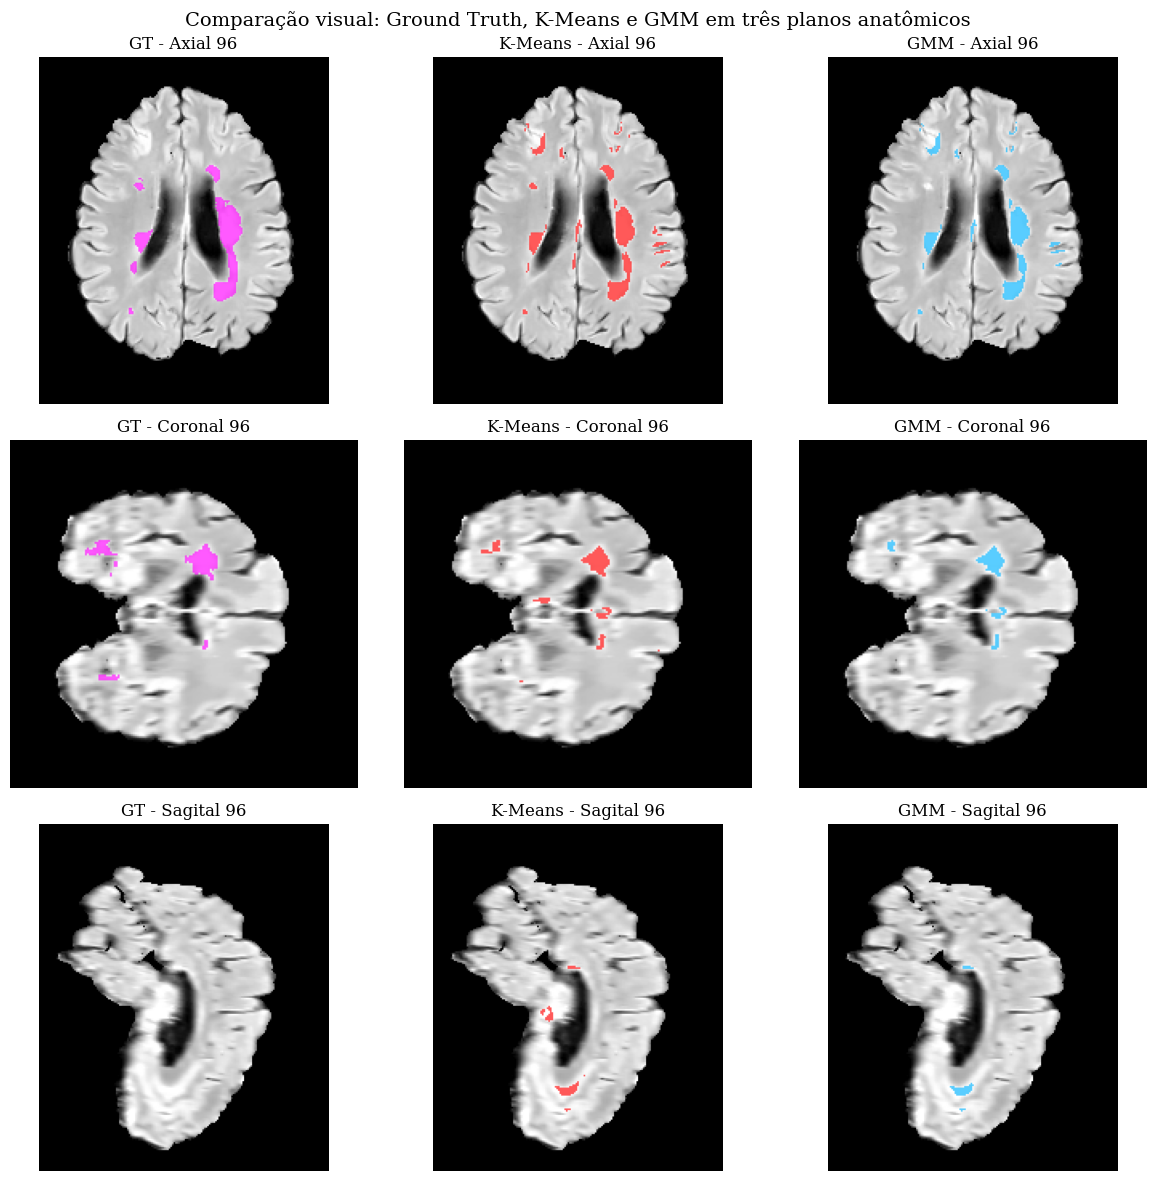

In [ ]:

# Comparação visual com cores manuais: GT | K-Means | GMM
# em três planos anatômicos


# Slices escolhidas por apresentarem regiões lesionais visíveis no ground truth
slice_axial = int(
    np.argmax(np.sum(clean_lesion_mask_gmm, axis=(1, 2)))
)

slice_coronal = int(
    np.argmax(np.sum(clean_lesion_mask_gmm, axis=(0, 2)))
)

slice_sagital = int(
    np.argmax(np.sum(clean_lesion_mask_gmm, axis=(0, 1)))
)

alpha = 0.65

def normalizar_imagem(img):
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, [1, 99])
    img_norm = np.clip((img - p1) / (p99 - p1), 0, 1)
    return img_norm

def criar_overlay(flair_slice, mask_slice, cor):
    flair_norm = normalizar_imagem(flair_slice)

    rgb = np.zeros((flair_norm.shape[0], flair_norm.shape[1], 3))
    rgb[:, :, 0] = flair_norm
    rgb[:, :, 1] = flair_norm
    rgb[:, :, 2] = flair_norm

    mask_bool = mask_slice > 0

    rgb[mask_bool, 0] = (1 - alpha) * rgb[mask_bool, 0] + alpha * cor[0]
    rgb[mask_bool, 1] = (1 - alpha) * rgb[mask_bool, 1] + alpha * cor[1]
    rgb[mask_bool, 2] = (1 - alpha) * rgb[mask_bool, 2] + alpha * cor[2]

    return rgb


# Cores manuais
cor_gt = [1, 0, 1]        # magenta
cor_kmeans = [1, 0, 0]    # vermelho
cor_gmm = [0, 0.7, 1]     # azul/ciano


plt.figure(figsize=(12, 12))


# AXIAL


plt.subplot(3, 3, 1)
plt.imshow(criar_overlay(
    flair_seg_array[slice_axial, :, :],
    gt_mask[slice_axial, :, :],
    cor_gt
))
plt.title(f"GT - Axial {slice_axial}")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(criar_overlay(
    flair_seg_array[slice_axial, :, :],
    clean_lesion_mask[slice_axial, :, :],
    cor_kmeans
))
plt.title(f"K-Means - Axial {slice_axial}")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(criar_overlay(
    flair_seg_array[slice_axial, :, :],
    clean_lesion_mask_gmm[slice_axial, :, :],
    cor_gmm
))
plt.title(f"GMM - Axial {slice_axial}")
plt.axis("off")



# CORONAL


plt.subplot(3, 3, 4)
plt.imshow(criar_overlay(
    np.rot90(flair_seg_array[:, slice_coronal, :]),
    np.rot90(gt_mask[:, slice_coronal, :]),
    cor_gt
))
plt.title(f"GT - Coronal {slice_coronal}")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(criar_overlay(
    np.rot90(flair_seg_array[:, slice_coronal, :]),
    np.rot90(clean_lesion_mask[:, slice_coronal, :]),
    cor_kmeans
))
plt.title(f"K-Means - Coronal {slice_coronal}")
plt.axis("off")

plt.subplot(3, 3, 6)
plt.imshow(criar_overlay(
    np.rot90(flair_seg_array[:, slice_coronal, :]),
    np.rot90(clean_lesion_mask_gmm[:, slice_coronal, :]),
    cor_gmm
))
plt.title(f"GMM - Coronal {slice_coronal}")
plt.axis("off")



# SAGITAL


plt.subplot(3, 3, 7)
plt.imshow(criar_overlay(
    np.rot90(flair_seg_array[:, :, slice_sagital]),
    np.rot90(gt_mask[:, :, slice_sagital]),
    cor_gt
))
plt.title(f"GT - Sagital {slice_sagital}")
plt.axis("off")

plt.subplot(3, 3, 8)
plt.imshow(criar_overlay(
    np.rot90(flair_seg_array[:, :, slice_sagital]),
    np.rot90(clean_lesion_mask[:, :, slice_sagital]),
    cor_kmeans
))
plt.title(f"K-Means - Sagital {slice_sagital}")
plt.axis("off")

plt.subplot(3, 3, 9)
plt.imshow(criar_overlay(
    np.rot90(flair_seg_array[:, :, slice_sagital]),
    np.rot90(clean_lesion_mask_gmm[:, :, slice_sagital]),
    cor_gmm
))
plt.title(f"GMM - Sagital {slice_sagital}")
plt.axis("off")


plt.suptitle(
    "Comparação visual: Ground Truth, K-Means e GMM em três planos anatômicos",
    fontsize=14
)

plt.tight_layout()
plt.show()

### 4.7 Conclusão da Etapa 3 <a name="conclusao-da-etapa-3"></a>

Nesta etapa, foram avaliadas duas abordagens não supervisionadas para
segmentação preliminar de possíveis lesões na FLAIR: K-Means e GMM.

Em ambos os métodos, a segmentação foi restringida à máscara de substância
branca registrada, utilizando o limiar WM > 0.4. As intensidades da FLAIR
dentro dessa região foram normalizadas com base nos percentis 1 e 99.

No K-Means, foram utilizados seis clusters, sendo o cluster com maior
centroide interpretado como candidato a representar regiões hiperintensas.
Após a segmentação, foram removidos componentes conectados menores que
60 voxels.

No GMM, foram utilizados cinco componentes gaussianos. O componente com
maior média foi considerado o componente hiperintenso, sendo mantidos
somente os voxels com responsabilidade mínima de 0.70. Também foram
removidos componentes menores que 60 voxels.

Na comparação com a referência combinada, o GMM apresentou uma pequena
vantagem em Dice, Jaccard e precisão, enquanto o K-Means apresentou maior
recall. Por isso, o GMM foi selecionado como método final para a
quantificação da carga lesional nos demais casos clínicos.

As máscaras devem ser interpretadas como segmentações preliminares de
regiões candidatas a lesão, pois os métodos utilizam principalmente a
intensidade da FLAIR e não incorporam explicitamente características
espaciais, anatômicas ou de forma.

In [ ]:
# Avaliação
voxel_volume_mm3 = float(
    np.prod(fixed_img.GetSpacing())
)

print("Volume do voxel:", voxel_volume_mm3, "mm³")
def calcular_metricas_segmentacao(pred_mask, gt_mask, voxel_volume_mm3):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)

    tp = int(np.sum(pred & gt))
    fp = int(np.sum(pred & ~gt))
    fn = int(np.sum(~pred & gt))
    tn = int(np.sum(~pred & ~gt))

    dice = (
        2 * tp / (2 * tp + fp + fn)
        if (2 * tp + fp + fn) > 0
        else 0
    )

    jaccard = (
        tp / (tp + fp + fn)
        if (tp + fp + fn) > 0
        else 0
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    voxels = int(np.sum(pred))
    volume = voxels * voxel_volume_mm3

    return {
        "Voxels": voxels,
        "Volume (mm³)": round(volume, 2),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Dice": round(dice, 4),
        "Jaccard": round(jaccard, 4),
        "Precisão": round(precision, 4),
        "Recall": round(recall, 4)
    }


metricas_kmeans = calcular_metricas_segmentacao(
    clean_lesion_mask,
    gt_mask,
    voxel_volume_mm3
)

metricas_gmm = calcular_metricas_segmentacao(
    clean_lesion_mask_gmm,
    gt_mask,
    voxel_volume_mm3
)

metricas_df = pd.DataFrame([
    {"Método": "K-Means", **metricas_kmeans},
    {"Método": "GMM", **metricas_gmm}
])

metricas_df

Volume do voxel: 1.0 mm³


,Método,Voxels,Volume (mm³),TP,FP,FN,Dice,Jaccard,Precisão,Recall
0,K-Means,22462,22462.0,14706,7756,9861,0.6254,0.4550,0.6547,0.5986
1,GMM,19535,19535.0,13829,5706,10738,0.6271,0.4568,0.7079,0.5629


# 5. Aplicação do método final aos demais casos clínicos <a name="aplicacao-do-metodo-final-aos-demais-casos-clinicos"></a>

Após a comparação entre K-Means e GMM no caso T01C01, foi selecionada uma única configuração para aplicação nos demais casos clínicos.

O objetivo desta etapa é verificar o comportamento do pipeline em diferentes exames sem reajustar os parâmetros individualmente para cada paciente.

Todos os casos foram processados utilizando exatamente os mesmos parâmetros definidos na etapa anterior, permitindo uma avaliação mais consistente do método proposto.

In [ ]:
# ============================================================
# PROCESSAMENTO DE TODOS OS CASOS — CONFIGURAÇÃO
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import itk

from scipy import ndimage
from sklearn.mixture import GaussianMixture
from IPython.display import display


# ------------------------------------------------------------
# Caminhos
# ------------------------------------------------------------

IMAGENS_DIR = DATA_DIR / "Imagens_Clinicas"
ATLAS_DIR = DATA_DIR / "Atlas"

BASE_OUTPUT = (
    PROJECT_DIR if "PROJECT_DIR" in globals()
    else Path.cwd()
) / "outputs_casos"

PARAM_BSPLINE = Path(
    "./parameters/parameters_bspline_model_zoo_grid24_interp1.txt"
).resolve()


ATLAS_T1_PATH = ATLAS_DIR / "mni_T1w_ref.nii.gz"
ATLAS_GM_PATH = ATLAS_DIR / "mni_gm.nii.gz"
ATLAS_WM_PATH = ATLAS_DIR / "mni_wm.nii.gz"
ATLAS_CSF_PATH = ATLAS_DIR / "mni_csf.nii.gz"


# ------------------------------------------------------------
# Configurações finais escolhidas no T01C01
# ------------------------------------------------------------

T1_DOMAIN_SIGMA = 4.0
FLAIR_DOMAIN_SIGMA = 1.0
RANGE_SIGMA = 0.5

WM_THRESHOLD = 0.40

GMM_COMPONENTS = 5
GMM_RESPONSIBILITY = 0.70

MIN_COMPONENT_SIZE = 60


# ------------------------------------------------------------
# Verificação dos caminhos
# ------------------------------------------------------------

BASE_OUTPUT.mkdir(parents=True, exist_ok=True)

required_paths = [
    IMAGENS_DIR,
    ATLAS_T1_PATH,
    ATLAS_GM_PATH,
    ATLAS_WM_PATH,
    ATLAS_CSF_PATH,
    PARAM_BSPLINE
]

missing_paths = [
    path for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Os seguintes caminhos não foram encontrados:\n"
        + "\n".join(str(path) for path in missing_paths)
    )


# ------------------------------------------------------------
# Criação do atlas T1 sem crânio
# Esse atlas será usado em todos os casos
# ------------------------------------------------------------

atlas_t1_img = sitk.Cast(
    sitk.ReadImage(str(ATLAS_T1_PATH)),
    sitk.sitkFloat32
)

atlas_gm_img = sitk.Cast(
    sitk.ReadImage(str(ATLAS_GM_PATH)),
    sitk.sitkFloat32
)

atlas_wm_img = sitk.Cast(
    sitk.ReadImage(str(ATLAS_WM_PATH)),
    sitk.sitkFloat32
)

atlas_csf_img = sitk.Cast(
    sitk.ReadImage(str(ATLAS_CSF_PATH)),
    sitk.sitkFloat32
)

brain_probability_img = (
    atlas_gm_img
    + atlas_wm_img
    + atlas_csf_img
)

brain_mask_img = brain_probability_img > 0.20

atlas_t1_brain_img = (
    atlas_t1_img
    * sitk.Cast(
        brain_mask_img,
        sitk.sitkFloat32
    )
)

ATLAS_T1_BRAIN_PATH = (
    BASE_OUTPUT / "atlas_t1_brain_only.nii.gz"
)

sitk.WriteImage(
    atlas_t1_brain_img,
    str(ATLAS_T1_BRAIN_PATH)
)

print("Pasta das imagens:", IMAGENS_DIR)
print("Pasta dos resultados:", BASE_OUTPUT)
print("Atlas mascarado:", ATLAS_T1_BRAIN_PATH)

Pasta das imagens: /content/drive/MyDrive/Ferrari_Compartilhado/Trabalho1-Descricao-20260407/Imagens_Clinicas
Pasta dos resultados: /content/drive/MyDrive/Ferrari_Compartilhado/Trabalho_Ferrari/outputs_casos
Atlas mascarado: /content/drive/MyDrive/Ferrari_Compartilhado/Trabalho_Ferrari/outputs_casos/atlas_t1_brain_only.nii.gz


## 5.1 Estratégia utilizada <a name="estrategia-utilizada"></a>

Para cada exame clínico foi executado o pipeline completo desenvolvido neste trabalho.

As principais etapas foram:

- leitura das imagens T1 e FLAIR;
- aplicação do filtro bilateral;
- registro do atlas probabilístico ao espaço da FLAIR;
- propagação dos mapas probabilísticos de GM, WM e CSF;
- criação da máscara de substância branca;
- segmentação utilizando o GMM;
- remoção de pequenos componentes conectados;
- cálculo da carga lesional em mm³.

Os mesmos parâmetros foram utilizados para todos os pacientes.

## 5.2 Configuração utilizada <a name="configuracao-utilizada"></a>

A configuração utilizada foi a mesma selecionada durante a análise do caso T01C01.

Parâmetros finais:

- Filtro bilateral:
    - T1: domainSigma = 4
    - FLAIR: domainSigma = 1
    - rangeSigma = 0.5

- Registro:
    - rígido
    - afim
    - deformável B-Spline (Model Zoo)

- Máscara de substância branca:
    - WM > 0.40

- Segmentação:
    - Gaussian Mixture Model
    - 5 componentes
    - responsabilidade mínima de 0.70

- Pós-processamento:
    - remoção de componentes menores que 60 voxels.

In [ ]:
# ============================================================
# FUNÇÕES PARA PROCESSAMENTO DOS CASOS
# ============================================================


def adicionar_parametros_comuns(parameter_map):

    parameter_map[
        "AutomaticTransformInitialization"
    ] = ["true"]

    parameter_map[
        "AutomaticTransformInitializationMethod"
    ] = ["GeometricalCenter"]

    parameter_map["WriteResultImage"] = ["true"]
    parameter_map["ResultImageFormat"] = ["nii.gz"]
    parameter_map["ResultImagePixelType"] = ["float"]

    return parameter_map



def criar_pipeline_registro_final():

    parameter_object = itk.ParameterObject.New()

    # Rígido
    rigid_map = (
        parameter_object.GetDefaultParameterMap("rigid")
    )

    adicionar_parametros_comuns(rigid_map)

    rigid_map["Metric"] = [
        "AdvancedMattesMutualInformation"
    ]

    parameter_object.AddParameterMap(rigid_map)


    # Afim
    affine_map = (
        parameter_object.GetDefaultParameterMap("affine")
    )

    adicionar_parametros_comuns(affine_map)

    affine_map["Metric"] = [
        "AdvancedMattesMutualInformation"
    ]

    parameter_object.AddParameterMap(affine_map)


    # B-Spline Model Zoo grid 24
    parameter_object.AddParameterFile(
        str(PARAM_BSPLINE)
    )

    return parameter_object



def remover_componentes_pequenos(
    mask,
    min_size=MIN_COMPONENT_SIZE
):

    mask = np.asarray(mask, dtype=bool)

    labeled_components, number_of_components = (
        ndimage.label(mask)
    )

    component_sizes = np.bincount(
        labeled_components.ravel()
    )

    valid_ids = np.where(
        component_sizes >= min_size
    )[0]

    # Remove o fundo, cujo identificador é zero
    valid_ids = valid_ids[valid_ids != 0]

    clean_mask = np.isin(
        labeled_components,
        valid_ids
    )

    return (
        clean_mask,
        int(number_of_components),
        int(len(valid_ids))
    )



def calcular_metricas(pred_mask, gt_mask):

    pred = np.asarray(pred_mask, dtype=bool)
    gt = np.asarray(gt_mask, dtype=bool)

    tp = int(np.sum(pred & gt))
    fp = int(np.sum(pred & ~gt))
    fn = int(np.sum(~pred & gt))

    dice_denominator = 2 * tp + fp + fn
    jaccard_denominator = tp + fp + fn
    precision_denominator = tp + fp
    recall_denominator = tp + fn

    dice = (
        2 * tp / dice_denominator
        if dice_denominator > 0
        else 1.0
    )

    jaccard = (
        tp / jaccard_denominator
        if jaccard_denominator > 0
        else 1.0
    )

    precision = (
        tp / precision_denominator
        if precision_denominator > 0
        else 0.0
    )

    recall = (
        tp / recall_denominator
        if recall_denominator > 0
        else 0.0
    )

    return {
        "Dice": dice,
        "Jaccard": jaccard,
        "Precisão": precision,
        "Recall": recall,
        "TP": tp,
        "FP": fp,
        "FN": fn
    }



def aplicar_transformacao(
    input_path,
    transform_parameter_object,
    output_path
):

    input_image = itk.imread(
        str(input_path),
        itk.F
    )

    transformed_image = itk.transformix_filter(
        input_image,
        transform_parameter_object
    )

    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    itk.imwrite(
        transformed_image,
        str(output_path)
    )

    return output_path



def processar_caso(case_folder):

    case_folder = Path(case_folder)
    case_code = case_folder.name

    print("Caso:", case_code)


    # --------------------------------------------------------
    # Arquivos do paciente
    # --------------------------------------------------------

    t1_path = (
        case_folder
        / f"{case_code}_t1.nii.gz"
    )

    flair_path = (
        case_folder
        / f"{case_code}_flair.nii.gz"
    )

    mask1_path = (
        case_folder
        / f"{case_code}_mask_1.nii.gz"
    )

    mask2_path = (
        case_folder
        / f"{case_code}_mask_2.nii.gz"
    )


    input_paths = [
        t1_path,
        flair_path,
        mask1_path,
        mask2_path
    ]

    missing = [
        path for path in input_paths
        if not path.exists()
    ]

    if missing:
        raise FileNotFoundError(
            f"Arquivos ausentes em {case_code}:\n"
            + "\n".join(str(path) for path in missing)
        )


    # --------------------------------------------------------
    # Pastas de saída específicas para o paciente
    # --------------------------------------------------------

    case_output = BASE_OUTPUT / case_code

    preprocessing_dir = (
        case_output / "preprocessing"
    )

    registration_dir = (
        case_output / "registration"
    )

    tissues_dir = (
        case_output / "tissues"
    )

    segmentation_dir = (
        case_output / "segmentation"
    )

    for directory in [
        preprocessing_dir,
        registration_dir,
        tissues_dir,
        segmentation_dir
    ]:
        directory.mkdir(
            parents=True,
            exist_ok=True
        )


    # ========================================================
    # 1. Leitura e redução de ruído
    # ========================================================

    t1_img = sitk.ReadImage(str(t1_path))
    flair_img = sitk.ReadImage(str(flair_path))


    t1_preprocessed_img = sitk.Bilateral(
        sitk.Cast(
            t1_img,
            sitk.sitkFloat32
        ),
        T1_DOMAIN_SIGMA,
        RANGE_SIGMA
    )


    flair_preprocessed_img = sitk.Bilateral(
        sitk.Cast(
            flair_img,
            sitk.sitkFloat32
        ),
        FLAIR_DOMAIN_SIGMA,
        RANGE_SIGMA
    )


    t1_preprocessed_path = (
        preprocessing_dir
        / f"{case_code}_t1_bilateral_preprocessed.nii.gz"
    )

    flair_preprocessed_path = (
        preprocessing_dir
        / f"{case_code}_flair_bilateral_preprocessed.nii.gz"
    )


    sitk.WriteImage(
        t1_preprocessed_img,
        str(t1_preprocessed_path)
    )

    sitk.WriteImage(
        flair_preprocessed_img,
        str(flair_preprocessed_path)
    )


    # ========================================================
    # 2. Registro atlas -> FLAIR
    # Rígido + afim + B-Spline Model Zoo
    # ========================================================

    fixed_image_itk = itk.imread(
        str(flair_preprocessed_path),
        itk.F
    )

    moving_image_itk = itk.imread(
        str(ATLAS_T1_BRAIN_PATH),
        itk.F
    )


    parameter_object = (
        criar_pipeline_registro_final()
    )


    registered_atlas_itk, transform_parameter_object = (
        itk.elastix_registration_method(
            fixed_image_itk,
            moving_image_itk,
            parameter_object=parameter_object,
            log_to_console=False
        )
    )


    registered_atlas_path = (
        registration_dir
        / "atlas_t1_registered_model_zoo_grid24.nii.gz"
    )

    itk.imwrite(
        registered_atlas_itk,
        str(registered_atlas_path)
    )


    # ========================================================
    # 3. Propagação dos mapas GM, WM e CSF
    # ========================================================

    gm_registered_path = aplicar_transformacao(
        ATLAS_GM_PATH,
        transform_parameter_object,
        tissues_dir / "gm_registered_to_flair.nii.gz"
    )

    wm_registered_path = aplicar_transformacao(
        ATLAS_WM_PATH,
        transform_parameter_object,
        tissues_dir / "wm_registered_to_flair.nii.gz"
    )

    csf_registered_path = aplicar_transformacao(
        ATLAS_CSF_PATH,
        transform_parameter_object,
        tissues_dir / "csf_registered_to_flair.nii.gz"
    )


    # ========================================================
    # 4. Preparação da FLAIR e da WM
    # ========================================================

    flair_array = sitk.GetArrayFromImage(
        flair_preprocessed_img
    ).astype(np.float32)


    wm_registered_img = sitk.ReadImage(
        str(wm_registered_path)
    )

    wm_registered_array = (
        sitk.GetArrayFromImage(
            wm_registered_img
        ).astype(np.float32)
    )


    if flair_array.shape != wm_registered_array.shape:

        raise ValueError(
            f"Shape incompatível em {case_code}: "
            f"FLAIR {flair_array.shape} e "
            f"WM {wm_registered_array.shape}."
        )


    wm_mask = (
        wm_registered_array > WM_THRESHOLD
    )


    if not np.any(wm_mask):

        raise ValueError(
            f"A máscara WM ficou vazia no caso {case_code}."
        )


    # ========================================================
    # 5. Normalização das intensidades
    # ========================================================

    flair_values_wm = flair_array[wm_mask]

    p1, p99 = np.percentile(
        flair_values_wm,
        [1, 99]
    )


    if p99 <= p1:

        raise ValueError(
            f"Normalização inválida em {case_code}: "
            "percentil 99 menor ou igual ao percentil 1."
        )


    flair_clipped = np.clip(
        flair_array,
        p1,
        p99
    )


    flair_normalized = (
        flair_clipped - p1
    ) / (
        p99 - p1 + 1e-8
    )


    flair_values_wm_normalized = (
        flair_normalized[wm_mask]
        .reshape(-1, 1)
    )


    # ========================================================
    # 6. Segmentação final com GMM
    # ========================================================

    gmm = GaussianMixture(
        n_components=GMM_COMPONENTS,
        covariance_type="full",
        init_params="kmeans",
        n_init=5,
        random_state=42,
        max_iter=200
    )


    gmm.fit(
        flair_values_wm_normalized
    )


    gmm_means = (
        gmm.means_.flatten()
    )


    lesion_component = int(
        np.argmax(gmm_means)
    )


    responsibilities = gmm.predict_proba(
        flair_values_wm_normalized
    )


    lesion_responsibility = (
        responsibilities[:, lesion_component]
    )


    lesion_mask = np.zeros_like(
        flair_array,
        dtype=bool
    )


    lesion_mask[wm_mask] = (
        lesion_responsibility
        >= GMM_RESPONSIBILITY
    )


    clean_lesion_mask, components_found, components_kept = (
        remover_componentes_pequenos(
            lesion_mask,
            min_size=MIN_COMPONENT_SIZE
        )
    )


    # ========================================================
    # 7. Salvamento da segmentação
    # ========================================================

    lesion_mask_img = sitk.GetImageFromArray(
        clean_lesion_mask.astype(np.uint8)
    )

    lesion_mask_img.CopyInformation(
        flair_preprocessed_img
    )


    responsibility_name = int(
        GMM_RESPONSIBILITY * 100
    )


    lesion_mask_path = (
        segmentation_dir
        / (
            f"{case_code}_lesion_mask_gmm_"
            f"c{GMM_COMPONENTS}_"
            f"resp{responsibility_name}_"
            f"min{MIN_COMPONENT_SIZE}.nii.gz"
        )
    )


    sitk.WriteImage(
        lesion_mask_img,
        str(lesion_mask_path)
    )


    # ========================================================
    # 8. Ground truth combinado
    # mask_1 OU mask_2
    # ========================================================

    mask1_img = sitk.ReadImage(
        str(mask1_path)
    )

    mask2_img = sitk.ReadImage(
        str(mask2_path)
    )


    mask1_array = sitk.GetArrayFromImage(
        mask1_img
    )

    mask2_array = sitk.GetArrayFromImage(
        mask2_img
    )


    gt_mask = (
        (mask1_array > 0)
        | (mask2_array > 0)
    )


    if gt_mask.shape != clean_lesion_mask.shape:

        raise ValueError(
            f"Shape incompatível em {case_code}: "
            f"GT {gt_mask.shape} e "
            f"segmentação {clean_lesion_mask.shape}."
        )


    gt_img = sitk.GetImageFromArray(
        gt_mask.astype(np.uint8)
    )

    gt_img.CopyInformation(flair_img)


    gt_path = (
        segmentation_dir
        / f"{case_code}_ground_truth_combined.nii.gz"
    )


    sitk.WriteImage(
        gt_img,
        str(gt_path)
    )


    # ========================================================
    # 9. Volume e métricas
    # ========================================================

    voxel_volume_mm3 = float(
        np.prod(
            flair_preprocessed_img.GetSpacing()
        )
    )


    lesion_voxels = int(
        np.sum(clean_lesion_mask)
    )

    gt_voxels = int(
        np.sum(gt_mask)
    )

    wm_voxels = int(
        np.sum(wm_mask)
    )


    lesion_volume_mm3 = (
        lesion_voxels
        * voxel_volume_mm3
    )

    gt_volume_mm3 = (
        gt_voxels
        * voxel_volume_mm3
    )

    wm_volume_mm3 = (
        wm_voxels
        * voxel_volume_mm3
    )


    metrics = calcular_metricas(
        clean_lesion_mask,
        gt_mask
    )


    print(
        f"{case_code} concluído | "
        f"Volume GMM: {lesion_volume_mm3:.2f} mm³ | "
        f"Dice: {metrics['Dice']:.4f} | "
        f"Jaccard: {metrics['Jaccard']:.4f}"
    )


    return {

        "Código da imagem": case_code,

        "Voxels GMM":
            lesion_voxels,

        "Carga lesional GMM (mm³)":
            lesion_volume_mm3,

        "Volume GT (mm³)":
            gt_volume_mm3,

        "Dice":
            metrics["Dice"],

        "Jaccard":
            metrics["Jaccard"],

        "Precisão":
            metrics["Precisão"],

        "Recall":
            metrics["Recall"],

        "Voxels WM":
            wm_voxels,

        "Volume WM (mm³)":
            wm_volume_mm3,

        "Componentes encontrados":
            components_found,

        "Componentes mantidos":
            components_kept,

        "Média hiperintensa GMM":
            float(
                gmm_means[lesion_component]
            ),

        "Máscara final":
            str(lesion_mask_path)
    }

## 5.3 Resultados <a name="resultados"></a>

A Tabela a seguir apresenta a carga lesional estimada para todos os casos clínicos processados.

Além do volume obtido pelo método proposto, são apresentados o volume da referência combinada (ground truth) e as métricas Dice, Jaccard, Precisão e Recall.

In [ ]:
# ============================================================
# PROCESSAMENTO AUTOMÁTICO DE TODOS OS CASOS
# ============================================================


# Procura automaticamente as pastas:
# T01C01, T01C04, T03C04, T04C03, T05C02 etc.

case_folders = sorted(

    folder

    for folder in IMAGENS_DIR.iterdir()

    if folder.is_dir()

    and (
        folder
        / f"{folder.name}_flair.nii.gz"
    ).exists()
)


print("Casos encontrados:")

for folder in case_folders:
    print(" -", folder.name)


resultados = []
erros = []


for index, case_folder in enumerate(
    case_folders,
    start=1
):

    case_code = case_folder.name

    print("\n" + "=" * 70)
    print(
        f"Processando "
        f"{index}/{len(case_folders)}: "
        f"{case_code}"
    )
    print("=" * 70)


    try:

        resultado = processar_caso(
            case_folder
        )

        resultados.append(
            resultado
        )


    except Exception as error:

        erros.append({
            "Código da imagem": case_code,
            "Erro": str(error)
        })

        print(
            f"ERRO em {case_code}:",
            error
        )


if not resultados:

    raise RuntimeError(
        "Nenhum caso foi processado com sucesso."
    )


# ============================================================
# DataFrame com todos os resultados
# ============================================================

resultados_df = pd.DataFrame(
    resultados
).sort_values(
    "Código da imagem"
).reset_index(
    drop=True
)


# ------------------------------------------------------------
# Tabela de validação
# ------------------------------------------------------------

tabela_validacao = resultados_df[
    [
        "Código da imagem",
        "Carga lesional GMM (mm³)",
        "Volume GT (mm³)",
        "Dice",
        "Jaccard",
        "Precisão",
        "Recall"
    ]
].copy()


tabela_validacao[
    "Carga lesional GMM (mm³)"
] = tabela_validacao[
    "Carga lesional GMM (mm³)"
].round(2)


tabela_validacao[
    "Volume GT (mm³)"
] = tabela_validacao[
    "Volume GT (mm³)"
].round(2)


for column in [
    "Dice",
    "Jaccard",
    "Precisão",
    "Recall"
]:

    tabela_validacao[column] = (
        tabela_validacao[column]
        .round(4)
    )


# ------------------------------------------------------------
# Tabela final pedida no trabalho
# ------------------------------------------------------------

tabela_final = resultados_df[
    [
        "Código da imagem",
        "Carga lesional GMM (mm³)"
    ]
].copy()


tabela_final[
    "Carga lesional GMM (mm³)"
] = tabela_final[
    "Carga lesional GMM (mm³)"
].round(2)


print("\n===== TABELA DE VALIDAÇÃO =====")

display(
    tabela_validacao
)


print("\n===== TABELA FINAL — CARGA LESIONAL =====")

display(
    tabela_final
)


# ============================================================
# Salvamento das tabelas
# ============================================================

validation_csv = (
    BASE_OUTPUT
    / "tabela_validacao_gmm.csv"
)

final_csv = (
    BASE_OUTPUT
    / "tabela_volume_lesoes.csv"
)


# O separador ; facilita abrir no Excel em português

tabela_validacao.to_csv(
    validation_csv,
    index=False,
    sep=";",
    decimal=","
)


tabela_final.to_csv(
    final_csv,
    index=False,
    sep=";",
    decimal=","
)


print(
    "\nTabela de validação salva em:",
    validation_csv
)

print(
    "Tabela final salva em:",
    final_csv
)


# Mostra casos que apresentaram algum erro

if erros:

    erros_df = pd.DataFrame(erros)

    print("\n===== CASOS COM ERRO =====")

    display(erros_df)

Casos encontrados:
 - T01C01
 - T01C04
 - T03C04
 - T04C03
 - T05C02

Processando 1/5: T01C01
Caso: T01C01
T01C01 concluído | Volume GMM: 19535.00 mm³ | Dice: 0.6271 | Jaccard: 0.4568

Processando 2/5: T01C04
Caso: T01C04
T01C04 concluído | Volume GMM: 27223.00 mm³ | Dice: 0.6106 | Jaccard: 0.4395

Processando 3/5: T03C04
Caso: T03C04
T03C04 concluído | Volume GMM: 19960.00 mm³ | Dice: 0.4301 | Jaccard: 0.2740

Processando 4/5: T04C03
Caso: T04C03
T04C03 concluído | Volume GMM: 24269.00 mm³ | Dice: 0.1728 | Jaccard: 0.0946

Processando 5/5: T05C02
Caso: T05C02
T05C02 concluído | Volume GMM: 22240.00 mm³ | Dice: 0.2903 | Jaccard: 0.1698

===== TABELA DE VALIDAÇÃO =====


,Código da imagem,Carga lesional GMM (mm³),Volume GT (mm³),Dice,Jaccard,Precisão,Recall
0,T01C01,19535.0,24567.0,0.6271,0.4568,0.7079,0.5629
1,T01C04,27223.0,21353.0,0.6106,0.4395,0.5448,0.6945
2,T03C04,19960.0,7639.0,0.4301,0.2740,0.2973,0.7769
3,T04C03,24269.0,3856.0,0.1728,0.0946,0.1001,0.6302
4,T05C02,22240.0,6031.0,0.2903,0.1698,0.1845,0.6805



===== TABELA FINAL — CARGA LESIONAL =====


,Código da imagem,Carga lesional GMM (mm³)
0,T01C01,19535.0
1,T01C04,27223.0
2,T03C04,19960.0
3,T04C03,24269.0
4,T05C02,22240.0



Tabela de validação salva em: /content/drive/MyDrive/Ferrari_Compartilhado/Trabalho_Ferrari/outputs_casos/tabela_validacao_gmm.csv
Tabela final salva em: /content/drive/MyDrive/Ferrari_Compartilhado/Trabalho_Ferrari/outputs_casos/tabela_volume_lesoes.csv


Observa-se que o comportamento do método variou entre os diferentes pacientes.

Nos casos T01C01 e T01C04 foram obtidos os maiores coeficientes Dice, indicando melhor concordância com a referência manual.

Nos demais casos houve redução do desempenho, principalmente em T04C03, onde o método apresentou maior quantidade de falsos positivos e superestimou a carga lesional.

Esse comportamento é esperado, pois o algoritmo utiliza apenas informações de intensidade da imagem FLAIR, sem incorporar características espaciais, anatômicas ou aprendizado supervisionado.

## 5.4 Discussão <a name="discussao"></a>

Os resultados mostram que um método clássico baseado em agrupamento consegue identificar regiões hiperintensas compatíveis com possíveis lesões de esclerose múltipla.

Entretanto, observou-se tendência à superestimação do volume lesional em alguns pacientes, principalmente quando outras estruturas da substância branca apresentavam intensidades semelhantes às lesões verdadeiras.

Apesar dessa limitação, o pipeline foi capaz de processar automaticamente todos os casos clínicos utilizando uma única configuração de parâmetros, demonstrando consistência e boa reprodutibilidade.

# Conclusão <a name="conclusao"></a>

Neste trabalho foi desenvolvido um pipeline completo para processamento de imagens de ressonância magnética de pacientes com esclerose múltipla.

Inicialmente foram avaliados diferentes métodos de redução de ruído, buscando preservar estruturas anatômicas importantes.

Em seguida, realizou-se o registro do atlas probabilístico ao espaço da imagem FLAIR clínica, permitindo restringir a segmentação à substância branca.

Por fim, foram comparados os métodos K-Means e Gaussian Mixture Model, sendo selecionado o GMM para aplicação aos demais casos clínicos.

Os resultados mostraram que o método foi capaz de segmentar automaticamente regiões hiperintensas e estimar a carga lesional em todos os pacientes analisados.

Embora o algoritmo apresente tendência à superestimação em alguns casos, os resultados demonstram que métodos clássicos de agrupamento constituem uma linha de base válida para segmentação preliminar de lesões em imagens FLAIR.

Como trabalhos futuros, podem ser incorporadas características espaciais, múltiplas modalidades de ressonância magnética e métodos supervisionados baseados em aprendizado profundo para aumentar a precisão da segmentação.

# Referências <a name="referencias-bibliograficas"></a>


[1] GONZALEZ, Rafael C.; WOODS, Richard C. Processamento Digital de Imagens. 3. ed. São Paulo: Pearson Education do Brasil, 2009.

[2] FERRARI, Ricardo J. Ambiente Virtual do Aluno: Disciplina de Processamento Digital de Imagens 3D e Vídeos (PDIV3D). São Carlos: UFSCar, 2024. Disponível em: https://ava.ufscar.br/. Acesso em: 10 maio 2026.

[3] DANA FOUNDATION. Neuroanatomy: The Basics. 2019. Disponível em: https://dana.org/resources/neuroanatomy-the-basics/. Acesso em: 10 maio 2026.

[4] UFSCAR. Notas de Aula e Materiais de Apoio: Processamento de Imagens Médicas. [Links internos do AVA: 1041556, 1041557, 1041558]. São Carlos: AVA-UFSCar, 2024.

[5] TADE CLINICAGEM. Como reconhecer as principais sequências da ressonância magnética? [S. l.], 2021. Disponível em: https://www.tadeclinicagem.com.br/. Acesso em: 10 maio 2026.

[6] RESEARCHGATE. A schematic drawing of the human brain indicating the two main tissue classes: gray and white matter. [S. l.], 2014. Disponível em: https://www.researchgate.net/. Acesso em: 10 maio 2026.

[7] TEACHME PHYSIOLOGY. Cerebrospinal Fluid (CSF). [S. l.], 2023. Disponível em: https://teachmephysiology.com/nervous-system/components/cerebrospinal-fluid/. Acesso em: 10 maio 2026.

[8] GOOGLE. Gemini (versão Advanced). Modelo de linguagem de grande escala. Provedor: Google. Assistência no refinamento de código Python e estruturação de texto acadêmico. 2026.

[9] INSIGHT SOFTWARE CONSORTIUM. The ITK Software Guide: Book 2: Design and Implementation. 4. ed. [S. l.], 2024. Disponível em: https://itk.org/ITKSoftwareGuide/html/Book2/ITKSoftwareGuide-Book2.html. Acesso em: 10 maio 2026.

[10] ELASTIX DEVELOPMENT TEAM. Elastix Doxygen Documentation. Version 5.3.0. [S. l.], 2026. Disponível em: https://elastix.dev/doxygen/. Acesso em: 10 maio 2026.

[11] KENHUB. Bainha de mielina e mielinização. [S. l.], 2026. Disponível em: https://www.kenhub.com/pt/library/anatomia/bainha-de-mielina-e-mielinizacao. Acesso em: 12 julho 2026.

[12] PLATOS EDUCATION. Manual de Publicação da Alexandria. Alexandria HTML Published, v. 1, 2026. Disponível em: https://alexandria-html-published.platosedu.io/b9ef5215-3c4f-41de-b372-5c9c71dd551c/v1/index.html. Acesso em: 12 julho 2026.